# ICWMF on Gowalla

## Part 1: Data Preparation

**Student:** Ali Etemadfard  
**Algorithm:** Improved Context-Aware Weighted Matrix Factorization (ICWMF)

This notebook section prepares the Gowalla check-in and friendship data for the later context-modeling and ICWMF stages. It is executable independently: all imports, configuration values, data loading, filtering, sampling, splitting, sparse-matrix construction, validation, caching, and visual diagnostics are defined in this section.

The implementation uses only NumPy, pandas, SciPy, scikit-learn, and the Python standard library. No recommender-system or matrix-factorization package is used.

In [137]:
from __future__ import annotations

import hashlib
import importlib.metadata as importlib_metadata
import json
import math
import os
import pickle
import platform
import random
import shutil
import time
import urllib.request
import warnings
from collections import defaultdict, deque
from pathlib import Path
from typing import Any, Dict, Iterable, List, Mapping, Optional, Sequence, Set, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import sparse
from sklearn.cluster import DBSCAN
from sklearn.neighbors import BallTree, NearestNeighbors
from sklearn.utils import check_random_state

## Environment setup

For a fresh Python environment, install the pinned runtime dependencies with:

```bash
python -m pip install -r requirements.txt
```

The Notebook does not execute `pip install` automatically. This keeps the experiment reproducible and avoids changing the user's environment during `Run All`.

## Configuration decisions

The paper reports an 80/20 train/test ratio but does not specify the exact splitting procedure. This notebook therefore exposes two explicit choices:

- `SPLIT_MODE = "per_user_random"`: each user's interactions are randomly divided.
- `SPLIT_MODE = "per_user_chronological"`: each user's older interactions are assigned to training and newer interactions to testing.

The paper only states an 80/20 train/test ratio, so the paper-aligned default uses a seeded per-user random split of check-in events. Pair-level leakage repair remains in the implementation as a documented safety step; the achieved event ratio is always reported and must be checked before comparing with the paper.

The paper does not fully specify the sampling procedure, k-core implementation details, chronological tie-breaking, exact coordinate-consistency threshold, or the treatment of isolated users in social sampling. These are explicit configuration or implementation decisions and are recorded again in `Part 1 Assumptions and Decisions`.

In [138]:



warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT
CACHE_DIR = PROJECT_ROOT / "cache" / "part1"

RANDOM_SEED = 42
# Paper-aligned execution defaults.  The paper's exact 2,150-user/6,668-POI
# subset is not distributed with this project, so the sample target keeps the
# run practical while using the paper's model parameters in Part 3.
MODE = "RESOURCE_MODE"
USE_SAMPLE = MODE == "RESOURCE_MODE"
SAMPLE_TARGET_USERS = 2150
FORCE_REPROCESS = False

MIN_USER_CHECKINS = 10
MIN_POI_CHECKINS = 10
TRAIN_RATIO = 0.80
SPLIT_MODE = "per_user_random"
SPLIT_UNIT = "user_poi_pair"
CHRONOLOGICAL_POI_ORDER = "first_visit"

# This option preserves event multiplicity unless explicitly enabled.
DROP_EXACT_DUPLICATE_CHECKINS = False
READ_CHUNK_SIZE = 250_000

PAPER_MODE = {
    "name": "PAPER_MODE",
    "use_sample": False,
    "sample_target_users": None,
}
RESOURCE_MODE = {
    "name": "RESOURCE_MODE",
    "use_sample": True,
    "sample_target_users": SAMPLE_TARGET_USERS,
}
ACTIVE_MODE = RESOURCE_MODE if USE_SAMPLE else PAPER_MODE

if MODE not in {"PAPER_MODE", "RESOURCE_MODE"}:
    raise ValueError("MODE must be PAPER_MODE or RESOURCE_MODE.")

CHECKINS_BASENAME = "Gowalla_totalCheckins.txt"
EDGES_BASENAME = "Gowalla_edges.txt"
CHECKINS_URL = "https://snap.stanford.edu/data/loc-gowalla_totalCheckins.txt.gz"
EDGES_URL = "https://snap.stanford.edu/data/loc-gowalla_edges.txt.gz"

DATA_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

if SPLIT_MODE not in {"per_user_random", "per_user_chronological"}:
    raise ValueError("SPLIT_MODE must be per_user_random or per_user_chronological.")
if SPLIT_UNIT not in {"user_poi_pair", "checkin_event"}:
    raise ValueError("SPLIT_UNIT must be user_poi_pair or checkin_event.")
if not 0.0 < TRAIN_RATIO < 1.0:
    raise ValueError("TRAIN_RATIO must be strictly between zero and one.")
if MIN_USER_CHECKINS <= 0 or MIN_POI_CHECKINS <= 0:
    raise ValueError("Minimum check-in thresholds must be positive.")
if USE_SAMPLE and SAMPLE_TARGET_USERS <= 0:
    raise ValueError("SAMPLE_TARGET_USERS must be positive when sampling is enabled.")

print(f"Active mode: {ACTIVE_MODE['name']}")
print(f"DATA_DIR: {DATA_DIR.resolve()}")
print(f"CACHE_DIR: {CACHE_DIR.resolve()}")
print(f"Sampling enabled: {USE_SAMPLE}; target users: {SAMPLE_TARGET_USERS if USE_SAMPLE else 'full dataset'}")
print(f"Split: {SPLIT_MODE} / {SPLIT_UNIT}; train ratio: {TRAIN_RATIO:.2f}")
SKLEARN_RANDOM_STATE = check_random_state(RANDOM_SEED)

Active mode: RESOURCE_MODE
DATA_DIR: F:\lessons\arshad\2\BD\project
CACHE_DIR: F:\lessons\arshad\2\BD\project\cache\part1
Sampling enabled: True; target users: 2150
Split: per_user_random / user_poi_pair; train ratio: 0.80


In [139]:
def package_version(distribution_name: str) -> str:
    """Return an installed distribution version or an explicit missing marker."""
    try:
        return importlib_metadata.version(distribution_name)
    except importlib_metadata.PackageNotFoundError:
        return "NOT_INSTALLED"


ENVIRONMENT_INFO = {
    "python_version": platform.python_version(),
    "platform": platform.platform(),
    "processor": platform.processor(),
    "cpu_count": os.cpu_count(),
    "numpy": package_version("numpy"),
    "pandas": package_version("pandas"),
    "scipy": package_version("scipy"),
    "scikit_learn": package_version("scikit-learn"),
    "matplotlib": package_version("matplotlib"),
    "pyarrow": package_version("pyarrow"),
    "nbformat": package_version("nbformat"),
    "nbconvert": package_version("nbconvert"),
    "ipykernel": package_version("ipykernel"),
}
SKLEARN_RANDOM_STATE = check_random_state(RANDOM_SEED)
print(json.dumps(ENVIRONMENT_INFO, indent=2))
print(f"NumPy/Python random seed: {RANDOM_SEED}; sklearn helper random state: {SKLEARN_RANDOM_STATE.get_state()[1][0]}")

{
  "python_version": "3.12.6",
  "platform": "Windows-11-10.0.26200-SP0",
  "processor": "Intel64 Family 6 Model 140 Stepping 1, GenuineIntel",
  "cpu_count": 4,
  "numpy": "2.3.5",
  "pandas": "3.0.3",
  "scipy": "1.16.3",
  "scikit_learn": "1.8.0",
  "matplotlib": "3.10.9",
  "pyarrow": "23.0.0",
  "nbformat": "5.10.4",
  "nbconvert": "7.16.4",
  "ipykernel": "6.29.5"
}
NumPy/Python random seed: 42; sklearn helper random state: 42


## Data acquisition and loading

The loader first checks for the uncompressed files supplied with the project. If a file is absent, it downloads the official gzip source into `DATA_DIR` with a temporary file and a byte-level progress indicator. Gzip files are read directly by pandas.

Check-in timestamps are parsed as UTC-aware datetimes. Rows with malformed identifiers, timestamps, or coordinates outside the valid latitude/longitude ranges are removed and counted. Chunked loading limits the largest temporary DataFrame held by the parser.

In [140]:
def human_bytes(value: float) -> str:
    """Return a readable representation of a byte count."""
    units = ["B", "KiB", "MiB", "GiB", "TiB"]
    number = float(value)
    for unit in units:
        if number < 1024.0 or unit == units[-1]:
            return f"{number:.2f} {unit}"
        number /= 1024.0
    return f"{number:.2f} TiB"


def download_with_progress(url: str, destination: Path, block_size: int = 1024 * 1024) -> Path:
    """Download a URL atomically while displaying progress."""
    destination.parent.mkdir(parents=True, exist_ok=True)
    if destination.exists() and destination.stat().st_size > 0:
        print(f"Using existing file: {destination}")
        return destination

    temporary = destination.with_name(destination.name + ".part")
    try:
        request = urllib.request.Request(url, headers={"User-Agent": "ICWMF-Gowalla-Notebook/1.0"})
        with urllib.request.urlopen(request, timeout=60) as response, temporary.open("wb") as handle:
            total = int(response.headers.get("Content-Length", "0") or 0)
            downloaded = 0
            while True:
                block = response.read(block_size)
                if not block:
                    break
                handle.write(block)
                downloaded += len(block)
                if total:
                    percent = 100.0 * downloaded / total
                    print(f"\rDownloading {destination.name}: {percent:6.2f}% ({human_bytes(downloaded)}/{human_bytes(total)})", end="")
                else:
                    print(f"\rDownloading {destination.name}: {human_bytes(downloaded)}", end="")
        print()
        temporary.replace(destination)
    except Exception as exc:
        if temporary.exists():
            temporary.unlink()
        raise RuntimeError(f"Could not download {url}: {exc}") from exc
    return destination


def resolve_data_file(basename: str, url: str) -> Path:
    """Use a local plain/gzip file or download the official gzip source."""
    plain_path = DATA_DIR / basename
    gzip_path = DATA_DIR / f"{basename}.gz"
    if plain_path.exists() and plain_path.stat().st_size > 0:
        return plain_path
    if gzip_path.exists() and gzip_path.stat().st_size > 0:
        return gzip_path
    return download_with_progress(url, gzip_path)


def load_checkins(path: Path, chunksize: int = READ_CHUNK_SIZE) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """Load and validate Gowalla check-ins using chunked parsing."""
    columns = ["user_id", "timestamp", "latitude", "longitude", "location_id"]
    frames: List[pd.DataFrame] = []
    raw_rows = 0
    raw_memory = 0
    invalid_rows = 0
    chunk_count = 0
    compression = "gzip" if path.suffix == ".gz" else None

    reader = pd.read_csv(
        path,
        sep="\t",
        header=None,
        names=columns,
        usecols=columns,
        dtype="string",
        compression=compression,
        chunksize=chunksize,
        on_bad_lines="warn",
        keep_default_na=False,
    )
    for chunk in reader:
        chunk_count += 1
        raw_rows += len(chunk)
        raw_memory += int(chunk.memory_usage(deep=True).sum())

        chunk["user_id"] = pd.to_numeric(chunk["user_id"], errors="coerce")
        chunk["location_id"] = pd.to_numeric(chunk["location_id"], errors="coerce")
        chunk["latitude"] = pd.to_numeric(chunk["latitude"], errors="coerce")
        chunk["longitude"] = pd.to_numeric(chunk["longitude"], errors="coerce")
        chunk["timestamp"] = pd.to_datetime(chunk["timestamp"], errors="coerce", utc=True)

        valid = (
            chunk["user_id"].notna()
            & chunk["location_id"].notna()
            & chunk["timestamp"].notna()
            & chunk["latitude"].notna()
            & chunk["longitude"].notna()
            & np.isfinite(chunk["latitude"].to_numpy(dtype=float))
            & np.isfinite(chunk["longitude"].to_numpy(dtype=float))
            & chunk["latitude"].between(-90.0, 90.0)
            & chunk["longitude"].between(-180.0, 180.0)
        )
        invalid_rows += int((~valid).sum())
        chunk = chunk.loc[valid, columns].copy()
        if chunk.empty:
            continue
        chunk["user_id"] = chunk["user_id"].astype(np.int64)
        chunk["location_id"] = chunk["location_id"].astype(np.int64)
        chunk["latitude"] = chunk["latitude"].astype(np.float64)
        chunk["longitude"] = chunk["longitude"].astype(np.float64)
        frames.append(chunk)

        if chunk_count % 5 == 0:
            print(f"Loaded check-in chunks: {chunk_count}; raw rows seen: {raw_rows:,}")

    if not frames:
        raise ValueError("No valid check-in rows were found.")
    result = pd.concat(frames, ignore_index=True)
    result = result[columns]
    stats = {
        "raw_rows": raw_rows,
        "raw_memory_bytes": raw_memory,
        "invalid_rows_removed": invalid_rows,
        "valid_rows": len(result),
        "chunks": chunk_count,
        "loaded_memory_bytes": int(result.memory_usage(deep=True).sum()),
    }
    print(f"Raw check-in records: {raw_rows:,}")
    print(f"Raw parser memory observed: {human_bytes(raw_memory)}")
    print(f"Invalid check-in records removed: {invalid_rows:,}")
    print(f"Valid check-in records loaded: {len(result):,}")
    print(f"Loaded DataFrame memory: {human_bytes(stats['loaded_memory_bytes'])}")
    return result, stats


def load_friendship_edges(path: Path, chunksize: int = READ_CHUNK_SIZE) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """Load, validate, canonicalize, and deduplicate undirected friendship edges."""
    columns = ["user_id_1", "user_id_2"]
    frames: List[pd.DataFrame] = []
    raw_rows = 0
    invalid_rows = 0
    compression = "gzip" if path.suffix == ".gz" else None
    reader = pd.read_csv(
        path,
        sep="\t",
        header=None,
        names=columns,
        dtype="string",
        compression=compression,
        chunksize=chunksize,
        on_bad_lines="warn",
        keep_default_na=False,
    )
    for chunk in reader:
        raw_rows += len(chunk)
        chunk["user_id_1"] = pd.to_numeric(chunk["user_id_1"], errors="coerce")
        chunk["user_id_2"] = pd.to_numeric(chunk["user_id_2"], errors="coerce")
        valid = chunk["user_id_1"].notna() & chunk["user_id_2"].notna()
        invalid_rows += int((~valid).sum())
        chunk = chunk.loc[valid, columns].copy()
        if chunk.empty:
            continue
        chunk["user_id_1"] = chunk["user_id_1"].astype(np.int64)
        chunk["user_id_2"] = chunk["user_id_2"].astype(np.int64)
        frames.append(chunk)

    if not frames:
        raise ValueError("No valid friendship edges were found.")
    edges = pd.concat(frames, ignore_index=True)
    self_loops = edges["user_id_1"].eq(edges["user_id_2"])
    self_loops_removed = int(self_loops.sum())
    edges = edges.loc[~self_loops].copy()
    left = np.minimum(edges["user_id_1"].to_numpy(), edges["user_id_2"].to_numpy())
    right = np.maximum(edges["user_id_1"].to_numpy(), edges["user_id_2"].to_numpy())
    edges["user_id_1"] = left
    edges["user_id_2"] = right
    before_dedup = len(edges)
    edges = edges.drop_duplicates(ignore_index=True)
    duplicate_edges_removed = before_dedup - len(edges)
    stats = {
        "raw_rows": raw_rows,
        "invalid_rows_removed": invalid_rows,
        "self_loops_removed": self_loops_removed,
        "duplicate_edges_removed": duplicate_edges_removed,
        "valid_undirected_edges": len(edges),
    }
    print(f"Raw friendship records: {raw_rows:,}")
    print(f"Invalid friendship records removed: {invalid_rows:,}")
    print(f"Self-loops removed: {self_loops_removed:,}")
    print(f"Duplicate undirected edges removed: {duplicate_edges_removed:,}")
    print(f"Unique undirected friendship edges: {len(edges):,}")
    return edges, stats

## Filtering, POI coordinates, and iterative k-core

Invalid coordinates are removed before filtering. A POI coordinate is represented by the median latitude and median longitude across its remaining check-ins. A POI is marked inconsistent when more than one exact coordinate pair is observed; the number and maximum coordinate spans are reported. The final `poi_coordinates` object is rebuilt from training check-ins after the split so later geographical context models cannot use test timestamps or test-only coordinate observations.

The user and POI minimums are applied as an iterative bipartite k-core. Each iteration removes users and POIs below threshold and prints the surviving check-ins, users, and POIs. The process stops only when the check-in count no longer changes.

In [141]:
def iterative_k_core(
    checkins: pd.DataFrame,
    min_user_checkins: int,
    min_poi_checkins: int,
    label: str,
) -> Tuple[pd.DataFrame, List[Dict[str, int]]]:
    """Apply user/POI minimums repeatedly until the bipartite core is stable."""
    current = checkins.reset_index(drop=True).copy()
    history: List[Dict[str, int]] = []
    iteration = 0
    while True:
        iteration += 1
        if current.empty:
            raise ValueError(f"{label}: filtering removed all check-ins.")
        user_counts = current.groupby("user_id", sort=False).size()
        poi_counts = current.groupby("location_id", sort=False).size()
        keep_users = user_counts[user_counts >= min_user_checkins].index
        keep_pois = poi_counts[poi_counts >= min_poi_checkins].index
        next_frame = current[
            current["user_id"].isin(keep_users)
            & current["location_id"].isin(keep_pois)
        ].reset_index(drop=True)
        record = {
            "iteration": iteration,
            "checkins": int(len(next_frame)),
            "users": int(next_frame["user_id"].nunique()),
            "pois": int(next_frame["location_id"].nunique()),
        }
        history.append(record)
        print(
            f"{label} k-core iteration {iteration}: "
            f"check-ins={record['checkins']:,}, users={record['users']:,}, POIs={record['pois']:,}"
        )
        if len(next_frame) == len(current):
            return next_frame, history
        current = next_frame


def build_poi_coordinates(checkins: pd.DataFrame) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """Aggregate one median coordinate per POI and report coordinate inconsistencies."""
    grouped = checkins.groupby("location_id", sort=True)
    summary = grouped.agg(
        latitude=("latitude", "median"),
        longitude=("longitude", "median"),
        latitude_min=("latitude", "min"),
        latitude_max=("latitude", "max"),
        longitude_min=("longitude", "min"),
        longitude_max=("longitude", "max"),
        latitude_unique=("latitude", "nunique"),
        longitude_unique=("longitude", "nunique"),
        checkin_count=("location_id", "size"),
    ).reset_index()
    inconsistent = (summary["latitude_unique"] > 1) | (summary["longitude_unique"] > 1)
    summary["latitude_span"] = summary["latitude_max"] - summary["latitude_min"]
    summary["longitude_span"] = summary["longitude_max"] - summary["longitude_min"]
    poi_coordinates = summary[["location_id", "latitude", "longitude", "checkin_count"]].copy()
    poi_coordinates = poi_coordinates.set_index("location_id").sort_index()
    stats = {
        "poi_count": int(len(summary)),
        "inconsistent_poi_count": int(inconsistent.sum()),
        "max_latitude_span": float(summary["latitude_span"].max()) if len(summary) else 0.0,
        "max_longitude_span": float(summary["longitude_span"].max()) if len(summary) else 0.0,
    }
    print(f"POIs with multiple observed coordinates: {stats['inconsistent_poi_count']:,}")
    print(f"Maximum latitude span: {stats['max_latitude_span']:.12f}")
    print(f"Maximum longitude span: {stats['max_longitude_span']:.12f}")
    return poi_coordinates, stats

## Social-aware sampling

When `USE_SAMPLE=True`, candidate users are taken from the filtered check-in data and matched to the friendship graph. The largest connected component is used as the primary sampling population. A seeded BFS snowball starts from a seeded user and expands through shuffled neighbor lists until `SAMPLE_TARGET_USERS` is reached.

This preserves social structure better than independent random user sampling, but it can favor users with higher degree. If the graph has no usable connected component or cannot provide the requested target, a deterministic random fallback fills the remaining sample. The sampled data is filtered again with the same iterative k-core thresholds, and only final-user friendship edges are retained.

In [142]:
def build_adjacency(edges: pd.DataFrame, users: Iterable[int]) -> Dict[int, Set[int]]:
    """Build an undirected adjacency dictionary restricted to a user set."""
    user_set = {int(user) for user in users}
    adjacency: Dict[int, Set[int]] = {user: set() for user in user_set}
    for row in edges.itertuples(index=False):
        left = int(row.user_id_1)
        right = int(row.user_id_2)
        if left in user_set and right in user_set:
            adjacency[left].add(right)
            adjacency[right].add(left)
    return adjacency


def largest_connected_component(adjacency: Mapping[int, Set[int]]) -> Set[int]:
    """Return the largest connected component using deterministic traversal."""
    unseen = set(adjacency)
    largest: Set[int] = set()
    while unseen:
        start = min(unseen)
        component: Set[int] = set()
        queue = deque([start])
        unseen.remove(start)
        while queue:
            node = queue.popleft()
            component.add(node)
            for neighbor in sorted(adjacency.get(node, set())):
                if neighbor in unseen:
                    unseen.remove(neighbor)
                    queue.append(neighbor)
        if len(component) > len(largest):
            largest = component
    return largest


def social_aware_sample(
    eligible_users: Iterable[int],
    edges: pd.DataFrame,
    target_users: int,
    seed: int,
) -> Tuple[Set[int], Dict[str, Any]]:
    """Select users with seeded BFS snowball sampling and reproducible fallback."""
    eligible = sorted({int(user) for user in eligible_users})
    if not eligible:
        raise ValueError("No eligible users are available for sampling.")
    target = min(int(target_users), len(eligible))
    rng = np.random.default_rng(seed)
    adjacency = build_adjacency(edges, eligible)
    component = largest_connected_component(adjacency)
    connected_nodes = sum(1 for node, neighbors in adjacency.items() if neighbors)

    if len(component) <= 1:
        selected = set(rng.choice(np.asarray(eligible), size=target, replace=False).tolist())
        return selected, {
            "method": "random_fallback_no_connected_component",
            "eligible_users": len(eligible),
            "largest_component_users": len(component),
            "connected_users": connected_nodes,
            "target_users": target,
        }

    selected: Set[int] = set()
    start = int(rng.choice(np.asarray(sorted(component))))
    queue = deque([start])
    queued = {start}
    while queue and len(selected) < target:
        node = queue.popleft()
        if node in selected:
            continue
        selected.add(node)
        neighbors = np.asarray(sorted(adjacency.get(node, set())), dtype=np.int64)
        if len(neighbors):
            rng.shuffle(neighbors)
            for neighbor in neighbors.tolist():
                neighbor = int(neighbor)
                if neighbor not in queued:
                    queued.add(neighbor)
                    queue.append(neighbor)

    method = "social_bfs_snowball"
    if len(selected) < target:
        remaining = sorted(set(eligible) - selected)
        needed = min(target - len(selected), len(remaining))
        if needed:
            fill = rng.choice(np.asarray(remaining), size=needed, replace=False).tolist()
            selected.update(int(user) for user in fill)
        method = "social_bfs_with_random_fallback_fill"

    return selected, {
        "method": method,
        "eligible_users": len(eligible),
        "largest_component_users": len(component),
        "connected_users": connected_nodes,
        "target_users": target,
        "start_user": start,
    }

## Train/test split

Splitting is performed independently for each user. In the default `user_poi_pair` mode, the unique POIs of a user are split and all events for a selected pair remain together. Users with fewer than two distinct POIs remain in training but are not evaluation users because it is impossible to leave both a train and a test POI.

In `per_user_chronological` mode, `user_poi_pair` uses the earliest visit time of each POI as its ordering key. The older 80% of POIs are assigned to training and the newer 20% to testing. For `checkin_event`, individual events are ordered by timestamp. A deterministic repair step moves all events of any overlapping pair to training, preserving the no-leakage invariant.

POIs that would occur only in test are repaired by moving one complete user–POI pair to training. The number of such repairs is recorded.

In [143]:
def _split_count(total: int, train_ratio: float) -> int:
    """Return a bounded train count with at least one item on each side when possible."""
    if total <= 1:
        return total
    count = int(math.floor(total * train_ratio))
    return max(1, min(total - 1, count))


def split_checkins(
    checkins: pd.DataFrame,
    split_mode: str,
    split_unit: str,
    train_ratio: float,
    seed: int,
) -> Tuple[pd.DataFrame, pd.DataFrame, Dict[str, Any]]:
    """Create per-user train/test splits and repair test-only POIs and pair overlap."""
    if split_mode not in {"per_user_random", "per_user_chronological"}:
        raise ValueError(f"Unsupported split mode: {split_mode}")
    if split_unit not in {"user_poi_pair", "checkin_event"}:
        raise ValueError(f"Unsupported split unit: {split_unit}")

    work = checkins.reset_index(drop=True).copy()
    train_mask = np.zeros(len(work), dtype=bool)
    rng = np.random.default_rng(seed)
    users_without_test = 0

    for user_id, group in work.groupby("user_id", sort=True):
        group_indices = group.index.to_numpy(dtype=np.int64)
        if split_unit == "user_poi_pair":
            pois = np.asarray(sorted(group["location_id"].unique()), dtype=np.int64)
            if len(pois) < 2:
                train_mask[group_indices] = True
                users_without_test += 1
                continue
            if split_mode == "per_user_random":
                ordered_pois = pois.copy()
                rng.shuffle(ordered_pois)
            else:
                first_seen = (
                    group.groupby("location_id", sort=True)["timestamp"]
                    .min()
                    .rename("first_seen")
                    .reset_index()
                )
                ordered_pois = first_seen.sort_values(
                    ["first_seen", "location_id"], kind="mergesort"
                )["location_id"].to_numpy(dtype=np.int64)
            n_train = _split_count(len(ordered_pois), train_ratio)
            train_pois = set(int(poi) for poi in ordered_pois[:n_train])
            train_mask[group_indices[group["location_id"].isin(train_pois).to_numpy()]] = True
        else:
            if len(group_indices) < 2:
                train_mask[group_indices] = True
                users_without_test += 1
                continue
            if split_mode == "per_user_random":
                ordered_indices = group_indices.copy()
                rng.shuffle(ordered_indices)
            else:
                ordered_indices = (
                    group.sort_values(["timestamp", "location_id"], kind="mergesort")
                    .index.to_numpy(dtype=np.int64)
                )
            n_train = _split_count(len(ordered_indices), train_ratio)
            train_mask[ordered_indices[:n_train]] = True

    initial_test_mask = ~train_mask
    initial_train = work.loc[train_mask]
    initial_test = work.loc[initial_test_mask]

    event_overlap_repairs = 0
    if split_unit == "checkin_event":
        train_pairs = set(zip(initial_train["user_id"].astype(int), initial_train["location_id"].astype(int)))
        test_pairs = set(zip(initial_test["user_id"].astype(int), initial_test["location_id"].astype(int)))
        overlap_pairs = sorted(train_pairs & test_pairs)
        for user_id, poi_id in overlap_pairs:
            pair_mask = (work["user_id"] == user_id) & (work["location_id"] == poi_id)
            train_mask[pair_mask.to_numpy()] = True
            event_overlap_repairs += 1

    test_only_poi_repairs = 0
    while True:
        train_frame = work.loc[train_mask]
        test_frame = work.loc[~train_mask]
        train_pois = set(train_frame["location_id"].astype(int).unique())
        test_only_pois = sorted(set(test_frame["location_id"].astype(int).unique()) - train_pois)
        if not test_only_pois:
            break
        for poi_id in test_only_pois:
            candidate = test_frame[test_frame["location_id"] == poi_id]
            if candidate.empty:
                continue
            test_counts = candidate.groupby("user_id").size().sort_values(ascending=False)
            chosen_user = int(test_counts.index[0])
            pair_mask = (
                (work["user_id"] == chosen_user)
                & (work["location_id"] == int(poi_id))
                & (~train_mask)
            )
            train_mask[pair_mask.to_numpy()] = True
            test_only_poi_repairs += 1

    train = work.loc[train_mask].reset_index(drop=True)
    test = work.loc[~train_mask].reset_index(drop=True)
    train_pairs = set(zip(train["user_id"].astype(int), train["location_id"].astype(int)))
    test_pairs = set(zip(test["user_id"].astype(int), test["location_id"].astype(int)))
    overlap = train_pairs & test_pairs
    diagnostics = {
        "train_checkins": int(len(train)),
        "test_checkins": int(len(test)),
        "train_ratio_actual": float(len(train) / len(work)) if len(work) else 0.0,
        "test_ratio_actual": float(len(test) / len(work)) if len(work) else 0.0,
        "users_without_test": int(users_without_test),
        "event_overlap_repairs": int(event_overlap_repairs),
        "test_only_poi_repairs": int(test_only_poi_repairs),
        "overlap_pairs_after_repair": int(len(overlap)),
        "chronological_order": CHRONOLOGICAL_POI_ORDER,
    }
    print(f"Train check-ins: {len(train):,}; test check-ins: {len(test):,}")
    print(f"Actual split ratio: {diagnostics['train_ratio_actual']:.4f} / {diagnostics['test_ratio_actual']:.4f}")
    print(f"Users without an eligible test split: {users_without_test:,}")
    print(f"Event overlap repairs: {event_overlap_repairs:,}")
    print(f"Test-only POI repairs: {test_only_poi_repairs:,}")
    print(f"User–POI overlap after repair: {len(overlap):,}")
    return train, test, diagnostics

## Sparse matrices, mappings, and training structures

User and POI indices are created only from the final training data and start at zero. `R_train` stores the number of training check-ins for each user–POI pair. `C_train` is the binary preference matrix derived from `R_train`; it is not a dense copy.

The optional `R_full` matrix uses the same training mappings and is retained for reporting only. Later model fitting must use `R_train` and `C_train` exclusively.

In [144]:

def _split_count(total_pairs: int, train_ratio: float) -> int:
    """Return a per-user train-pair count closest to the requested ratio.

    At least one pair is kept in train and one in test whenever a user has
    two or more distinct POIs.
    """
    if total_pairs <= 1:
        return total_pairs

    test_ratio = 1.0 - float(train_ratio)
    # Round to the nearest integer rather than always flooring the train side.
    n_test = int(np.floor(total_pairs * test_ratio + 0.5))
    n_test = max(1, min(total_pairs - 1, n_test))
    return total_pairs - n_test


def split_checkins(
    checkins: pd.DataFrame,
    split_mode: str,
    split_unit: str,
    train_ratio: float,
    seed: int,
) -> Tuple[pd.DataFrame, pd.DataFrame, Dict[str, Any]]:
    """Create a leakage-free per-user split over complete user–POI pairs.

    The requested 80/20 ratio is defined over UNIQUE user–POI pairs. All raw
    check-in events belonging to one pair remain on the same side. This avoids
    the previous event-overlap repair that changed 80/20 into roughly 95/5.
    """
    if split_mode not in {"per_user_random", "per_user_chronological"}:
        raise ValueError(f"Unsupported split mode: {split_mode}")
    if split_unit != "user_poi_pair":
        raise ValueError(
            "For POI recommendation, SPLIT_UNIT must be 'user_poi_pair'. "
            "Event-level splitting creates train/test pair overlap and destroys "
            "the intended 80/20 split after leakage repair."
        )
    if not 0.0 < train_ratio < 1.0:
        raise ValueError("train_ratio must be strictly between zero and one.")

    work = checkins.reset_index(drop=True).copy()
    if work.empty:
        raise ValueError("Cannot split an empty check-in table.")

    required_columns = {"user_id", "location_id", "timestamp"}
    missing_columns = required_columns - set(work.columns)
    if missing_columns:
        raise ValueError(f"Missing split columns: {sorted(missing_columns)}")

    # One row per unique user–POI pair. Event multiplicity is preserved later
    # because the final mask is applied to the original check-in table.
    pair_table = (
        work.groupby(["user_id", "location_id"], sort=True)
        .agg(first_seen=("timestamp", "min"), event_count=("timestamp", "size"))
        .reset_index()
    )

    rng = np.random.default_rng(seed)
    train_pair_keys: Set[Tuple[int, int]] = set()
    users_without_test = 0

    for user_id, user_pairs in pair_table.groupby("user_id", sort=True):
        user_pairs = user_pairs.copy()
        n_pairs = len(user_pairs)

        if n_pairs < 2:
            only_poi = int(user_pairs.iloc[0]["location_id"])
            train_pair_keys.add((int(user_id), only_poi))
            users_without_test += 1
            continue

        if split_mode == "per_user_random":
            order = rng.permutation(n_pairs)
            ordered = user_pairs.iloc[order].reset_index(drop=True)
        else:
            ordered = user_pairs.sort_values(
                ["first_seen", "location_id"], kind="mergesort"
            ).reset_index(drop=True)

        n_train = _split_count(n_pairs, train_ratio)
        for poi_id in ordered.iloc[:n_train]["location_id"].astype(int):
            train_pair_keys.add((int(user_id), int(poi_id)))

    pair_index = pd.MultiIndex.from_frame(work[["user_id", "location_id"]])
    train_key_index = pd.MultiIndex.from_tuples(
        sorted(train_pair_keys), names=["user_id", "location_id"]
    )
    train_mask = pair_index.isin(train_key_index)

    # Repair POIs that would otherwise exist only in test. A complete pair is
    # moved to train, so leakage is never introduced. Prefer a user with more
    # than one remaining test pair so that the user stays evaluable.
    test_only_poi_repairs = 0
    while True:
        train_frame = work.loc[train_mask]
        test_frame = work.loc[~train_mask]
        train_pois = set(train_frame["location_id"].astype(int).unique())
        test_only_pois = sorted(
            set(test_frame["location_id"].astype(int).unique()) - train_pois
        )
        if not test_only_pois:
            break

        current_test_pair_counts = (
            test_frame[["user_id", "location_id"]]
            .drop_duplicates()
            .groupby("user_id")
            .size()
            .to_dict()
        )

        for poi_id in test_only_pois:
            candidates = (
                test_frame.loc[test_frame["location_id"] == poi_id, ["user_id", "location_id"]]
                .drop_duplicates()
                .copy()
            )
            if candidates.empty:
                continue

            candidates["remaining_test_pairs"] = candidates["user_id"].map(
                current_test_pair_counts
            ).fillna(0)
            candidates = candidates.sort_values(
                ["remaining_test_pairs", "user_id"],
                ascending=[False, True],
                kind="mergesort",
            )
            chosen_user = int(candidates.iloc[0]["user_id"])

            pair_mask = (
                (work["user_id"].astype(int) == chosen_user)
                & (work["location_id"].astype(int) == int(poi_id))
            ).to_numpy()
            train_mask[pair_mask] = True
            test_only_poi_repairs += 1

    train = work.loc[train_mask].reset_index(drop=True)
    test = work.loc[~train_mask].reset_index(drop=True)

    train_pairs = set(
        zip(train["user_id"].astype(int), train["location_id"].astype(int))
    )
    test_pairs = set(
        zip(test["user_id"].astype(int), test["location_id"].astype(int))
    )
    overlap = train_pairs & test_pairs

    total_pairs = len(train_pairs) + len(test_pairs)
    pair_train_ratio = len(train_pairs) / total_pairs if total_pairs else 0.0
    pair_test_ratio = len(test_pairs) / total_pairs if total_pairs else 0.0
    event_train_ratio = len(train) / len(work) if len(work) else 0.0
    event_test_ratio = len(test) / len(work) if len(work) else 0.0

    diagnostics = {
        "split_unit": "user_poi_pair",
        "train_checkins": int(len(train)),
        "test_checkins": int(len(test)),
        "train_pairs": int(len(train_pairs)),
        "test_pairs": int(len(test_pairs)),
        "pair_train_ratio_actual": float(pair_train_ratio),
        "pair_test_ratio_actual": float(pair_test_ratio),
        "event_train_ratio_actual": float(event_train_ratio),
        "event_test_ratio_actual": float(event_test_ratio),
        # Backward-compatible names now refer to the pair-level split ratio.
        "train_ratio_actual": float(pair_train_ratio),
        "test_ratio_actual": float(pair_test_ratio),
        "users_without_test": int(users_without_test),
        "event_overlap_repairs": 0,
        "test_only_poi_repairs": int(test_only_poi_repairs),
        "overlap_pairs_after_repair": int(len(overlap)),
        "chronological_order": CHRONOLOGICAL_POI_ORDER,
    }

    if overlap:
        raise AssertionError(
            f"Train/test user–POI overlap remains after pair split: {len(overlap)}"
        )

    print(f"Train user–POI pairs: {len(train_pairs):,}")
    print(f"Test user–POI pairs:  {len(test_pairs):,}")
    print(
        "Actual PAIR split ratio: "
        f"{pair_train_ratio:.4f} / {pair_test_ratio:.4f}"
    )
    print(
        "Raw EVENT ratio (informational only): "
        f"{event_train_ratio:.4f} / {event_test_ratio:.4f}"
    )
    print(f"Users without an eligible test pair: {users_without_test:,}")
    print(f"Test-only POI repairs: {test_only_poi_repairs:,}")
    print(f"User–POI overlap after repair: {len(overlap):,}")

    if abs(pair_train_ratio - train_ratio) > 0.03:
        warnings.warn(
            "The pair-level split differs from the requested ratio by more than "
            "3 percentage points. This can happen when many users have only two "
            "distinct POIs or when many test-only POIs require repair."
        )

    return train, test, diagnostics


## Caching and reproducible execution

The cache fingerprint includes the source-file sizes and modification times together with the data-processing configuration. Sparse matrices are stored with `scipy.sparse.save_npz`; tables use Parquet when an engine is available and otherwise use pickle; mappings and lookup dictionaries use pickle; metadata is JSON.

Set `FORCE_REPROCESS=True` to invalidate an existing matching cache. The first run processes the data; later runs with the same configuration can load the saved artifacts.

In [145]:
def jsonable(value: Any) -> Any:
    """Convert common NumPy, pandas, and pathlib values to JSON-compatible objects."""
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    if isinstance(value, (pd.Timestamp,)):
        return value.isoformat()
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, dict):
        return {str(key): jsonable(item) for key, item in value.items()}
    if isinstance(value, (set, tuple, list)):
        return [jsonable(item) for item in value]
    return value


def save_dataframe(frame: pd.DataFrame, base_path: Path) -> Path:
    """Save a DataFrame to Parquet when available, with a pickle fallback."""
    parquet_path = base_path.with_suffix(".parquet")
    try:
        frame.to_parquet(parquet_path, index=False)
        return parquet_path
    except (ImportError, ValueError, OSError):
        pickle_path = base_path.with_suffix(".pkl")
        frame.to_pickle(pickle_path)
        return pickle_path


def load_dataframe(base_path: Path) -> pd.DataFrame:
    """Load a cached DataFrame saved by save_dataframe."""
    parquet_path = base_path.with_suffix(".parquet")
    pickle_path = base_path.with_suffix(".pkl")
    if parquet_path.exists():
        return pd.read_parquet(parquet_path)
    if pickle_path.exists():
        return pd.read_pickle(pickle_path)
    raise FileNotFoundError(f"No cached table found for {base_path}")


def source_signature(paths: Mapping[str, Path]) -> str:
    """Create a stable fingerprint for source files and preprocessing settings."""
    payload = {
        "pipeline_version": "part1_pair_split_v3",
        "sources": {
            name: {"path": str(path.resolve()), "size": path.stat().st_size, "mtime_ns": path.stat().st_mtime_ns}
            for name, path in paths.items()
        },
        "config": {
            "random_seed": RANDOM_SEED,
            "use_sample": USE_SAMPLE,
            "sample_target_users": SAMPLE_TARGET_USERS,
            "min_user_checkins": MIN_USER_CHECKINS,
            "min_poi_checkins": MIN_POI_CHECKINS,
            "train_ratio": TRAIN_RATIO,
            "split_mode": SPLIT_MODE,
            "split_unit": SPLIT_UNIT,
            "chronological_poi_order": CHRONOLOGICAL_POI_ORDER,
            "drop_exact_duplicates": DROP_EXACT_DUPLICATE_CHECKINS,
        },
    }
    encoded = json.dumps(payload, sort_keys=True).encode("utf-8")
    return hashlib.sha256(encoded).hexdigest()[:16]


def cache_paths(stem: str) -> Dict[str, Path]:
    """Return all artifact paths for one processing fingerprint."""
    prefix = CACHE_DIR / stem
    return {
        "metadata": prefix.with_suffix(".json"),
        "R_train": prefix.with_name(prefix.name + "_R_train.npz"),
        "C_train": prefix.with_name(prefix.name + "_C_train.npz"),
        "R_full": prefix.with_name(prefix.name + "_R_full.npz"),
        "mappings": prefix.with_name(prefix.name + "_mappings.pkl"),
        "tables_filtered": prefix.with_name(prefix.name + "_filtered"),
        "tables_train": prefix.with_name(prefix.name + "_train"),
        "tables_test": prefix.with_name(prefix.name + "_test"),
        "tables_poi_coordinates": prefix.with_name(prefix.name + "_poi_coordinates"),
    }


def cache_is_complete(paths: Mapping[str, Path]) -> bool:
    """Check whether all required cache artifacts are present."""
    table_exists = lambda base: base.with_suffix(".parquet").exists() or base.with_suffix(".pkl").exists()
    return (
        paths["metadata"].exists()
        and paths["R_train"].exists()
        and paths["C_train"].exists()
        and paths["R_full"].exists()
        and paths["mappings"].exists()
        and table_exists(paths["tables_filtered"])
        and table_exists(paths["tables_train"])
        and table_exists(paths["tables_test"])
        and table_exists(paths["tables_poi_coordinates"])
    )

## Run Part 1

The following pipeline cell performs the complete data-preparation workflow. It first resolves the local/downloaded files, then loads and cleans them, applies the full-data k-core, performs optional social-aware sampling, applies the final k-core, constructs POI coordinates and filtered social structures, creates the train/test split, builds train-only mappings and sparse matrices, validates leakage, and saves the artifacts.

In [146]:
def run_part1() -> Dict[str, Any]:
    """Execute the complete, reproducible Part 1 data-preparation pipeline."""
    started = time.time()
    checkins_path = resolve_data_file(CHECKINS_BASENAME, CHECKINS_URL)
    edges_path = resolve_data_file(EDGES_BASENAME, EDGES_URL)
    source_paths = {"checkins": checkins_path, "edges": edges_path}
    fingerprint = source_signature(source_paths)
    stem = f"part1_{ACTIVE_MODE['name'].lower()}_{fingerprint}"
    paths = cache_paths(stem)

    if cache_is_complete(paths) and not FORCE_REPROCESS:
        print(f"Loading cached Part 1 artifacts: {stem}")
        metadata = json.loads(paths["metadata"].read_text(encoding="utf-8"))
        mappings = pickle.loads(paths["mappings"].read_bytes())
        result = {
            "checkins_path": checkins_path,
            "edges_path": edges_path,
            "metadata": metadata,
            "cache_paths": paths,
            "filtered_checkins": load_dataframe(paths["tables_filtered"]),
            "train_checkins": load_dataframe(paths["tables_train"]),
            "test_checkins": load_dataframe(paths["tables_test"]),
            "poi_coordinates": load_dataframe(paths["tables_poi_coordinates"]).set_index("location_id"),
            "R_train": sparse.load_npz(paths["R_train"]).tocsr(),
            "C_train": sparse.load_npz(paths["C_train"]).tocsr(),
            "R_full": sparse.load_npz(paths["R_full"]).tocsr(),
            **mappings,
        }
        print(f"Cached artifacts loaded in {time.time() - started:.2f} seconds.")
        return result

    checkins, raw_checkin_stats = load_checkins(checkins_path)
    edges, raw_edge_stats = load_friendship_edges(edges_path)

    duplicate_checkins = int(checkins.duplicated().sum())
    print(f"Exact duplicate check-in rows observed: {duplicate_checkins:,}")
    if DROP_EXACT_DUPLICATE_CHECKINS:
        checkins = checkins.drop_duplicates(ignore_index=True)
        print(f"Exact duplicate check-in rows removed: {duplicate_checkins:,}")

    full_filtered, full_filter_history = iterative_k_core(
        checkins,
        MIN_USER_CHECKINS,
        MIN_POI_CHECKINS,
        "Full dataset",
    )

    sampling_diagnostics: Dict[str, Any] = {
        "enabled": bool(USE_SAMPLE),
        "target_users": int(SAMPLE_TARGET_USERS) if USE_SAMPLE else None,
    }
    if USE_SAMPLE:
        selected_users, sampling_diagnostics = social_aware_sample(
            full_filtered["user_id"].unique(),
            edges,
            SAMPLE_TARGET_USERS,
            RANDOM_SEED,
        )
        sampled = full_filtered[full_filtered["user_id"].isin(selected_users)].reset_index(drop=True)
        filtered_checkins, sample_filter_history = iterative_k_core(
            sampled,
            MIN_USER_CHECKINS,
            MIN_POI_CHECKINS,
            "Sampled dataset",
        )
    else:
        filtered_checkins = full_filtered.copy()
        sample_filter_history = []

    train_checkins, test_checkins, split_diagnostics = split_checkins(
        filtered_checkins,
        SPLIT_MODE,
        SPLIT_UNIT,
        TRAIN_RATIO,
        RANDOM_SEED,
    )
    structures = build_training_structures(train_checkins, test_checkins, filtered_checkins)

    pre_split_poi_coordinates, pre_split_coordinate_stats = build_poi_coordinates(filtered_checkins)
    poi_coordinates, coordinate_stats = build_poi_coordinates(train_checkins)
    final_users = set(int(user) for user in train_checkins["user_id"].unique())
    filtered_social_edges = edges[
        edges["user_id_1"].isin(final_users) & edges["user_id_2"].isin(final_users)
    ].reset_index(drop=True)
    user_friendship_adjacency = build_adjacency(filtered_social_edges, final_users)

    user_id_to_index = structures["user_id_to_index"]
    poi_id_to_index = structures["poi_id_to_index"]
    train_pairs = set(zip(train_checkins["user_id"].astype(int), train_checkins["location_id"].astype(int)))
    test_pairs = set(zip(test_checkins["user_id"].astype(int), test_checkins["location_id"].astype(int)))
    overlap_pairs = train_pairs & test_pairs
    missing_test_users = set(test_checkins["user_id"].astype(int)) - set(user_id_to_index)
    missing_test_pois = set(test_checkins["location_id"].astype(int)) - set(poi_id_to_index)
    invalid_coordinate_rows = int(
        (~filtered_checkins["latitude"].between(-90.0, 90.0)
         | ~filtered_checkins["longitude"].between(-180.0, 180.0)
         | filtered_checkins[["latitude", "longitude"]].isna().any(axis=1)).sum()
    )

    assert structures["R_train"].shape == structures["C_train"].shape
    assert structures["R_train"].shape == (len(user_id_to_index), len(poi_id_to_index))
    assert structures["R_train"].data.size == 0 or np.all(structures["R_train"].data >= 0)
    assert structures["C_train"].data.size == 0 or np.all(np.isin(structures["C_train"].data, [0.0, 1.0]))
    assert all(len(pois) >= 1 for pois in structures["train_user_pois"].values())
    assert all(len(pois) >= 1 for pois in structures["test_user_pois"].values())
    assert not overlap_pairs, f"Train/test user–POI overlap detected: {len(overlap_pairs)}"
    assert not missing_test_users, f"Test users missing from train mappings: {missing_test_users}"
    assert not missing_test_pois, f"Test POIs missing from train mappings: {missing_test_pois}"
    assert invalid_coordinate_rows == 0
    assert poi_coordinates[["latitude", "longitude"]].notna().all().all()
    assert poi_coordinates["latitude"].between(-90.0, 90.0).all()
    assert poi_coordinates["longitude"].between(-180.0, 180.0).all()

    filtered_users = set(int(user) for user in filtered_checkins["user_id"].unique())
    filtered_pois = set(int(poi) for poi in filtered_checkins["location_id"].unique())
    assert set(user_id_to_index).issubset(filtered_users)
    assert set(poi_id_to_index).issubset(filtered_pois)

    def sparse_digest(matrix: sparse.spmatrix) -> str:
        """Return a deterministic digest for a sparse CSR matrix."""
        matrix = matrix.tocsr()
        digest = hashlib.sha256()
        digest.update(matrix.indptr.tobytes())
        digest.update(matrix.indices.tobytes())
        digest.update(matrix.data.tobytes())
        return digest.hexdigest()

    r_train_digest = sparse_digest(structures["R_train"])
    assert r_train_digest == sparse_digest(structures["R_train"])

    mappings = {
        "user_id_to_index": structures["user_id_to_index"],
        "index_to_user_id": structures["index_to_user_id"],
        "poi_id_to_index": structures["poi_id_to_index"],
        "index_to_poi_id": structures["index_to_poi_id"],
        "train_user_pois": structures["train_user_pois"],
        "test_user_pois": structures["test_user_pois"],
        "train_checkin_timestamps": structures["train_checkin_timestamps"],
        "filtered_social_edges": filtered_social_edges,
        "user_friendship_adjacency": user_friendship_adjacency,
    }

    metadata = {
        "student": "Ali Etemadfard",
        "part": "Part 1: Data Preparation",
        "mode": ACTIVE_MODE["name"],
        "random_seed": RANDOM_SEED,
        "data_dir": str(DATA_DIR.resolve()),
        "source_paths": {key: str(path.resolve()) for key, path in source_paths.items()},
        "source_signature": fingerprint,
        "configuration": {
            "use_sample": USE_SAMPLE,
            "sample_target_users": SAMPLE_TARGET_USERS,
            "min_user_checkins": MIN_USER_CHECKINS,
            "min_poi_checkins": MIN_POI_CHECKINS,
            "train_ratio": TRAIN_RATIO,
            "split_mode": SPLIT_MODE,
            "split_unit": SPLIT_UNIT,
            "chronological_poi_order": CHRONOLOGICAL_POI_ORDER,
            "drop_exact_duplicate_checkins": DROP_EXACT_DUPLICATE_CHECKINS,
        },
        "raw_checkin_stats": raw_checkin_stats,
        "raw_edge_stats": raw_edge_stats,
        "full_filter_history": full_filter_history,
        "sample_filter_history": sample_filter_history,
        "sampling_diagnostics": sampling_diagnostics,
        "coordinate_stats": coordinate_stats,
        "pre_split_coordinate_stats": pre_split_coordinate_stats,
        "split_diagnostics": split_diagnostics,
        "reproducibility": {
            "R_train_sha256": r_train_digest,
            "sorted_train_users": True,
            "sorted_train_pois": True,
        },
        "final_statistics": {
            "raw_checkins": int(raw_checkin_stats["raw_rows"]),
            "filtered_checkins": int(len(filtered_checkins)),
            "train_checkins": int(len(train_checkins)),
            "test_checkins": int(len(test_checkins)),
            "users": int(len(user_id_to_index)),
            "pois": int(len(poi_id_to_index)),
            "social_edges": int(len(filtered_social_edges)),
            "matrix_nnz": int(structures["R_train"].nnz),
        },
    }

    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    sparse.save_npz(paths["R_train"], structures["R_train"])
    sparse.save_npz(paths["C_train"], structures["C_train"])
    sparse.save_npz(paths["R_full"], structures["R_full"])
    pickle_payload = {
        **mappings,
    }
    paths["mappings"].write_bytes(pickle.dumps(pickle_payload, protocol=pickle.HIGHEST_PROTOCOL))
    save_dataframe(filtered_checkins, paths["tables_filtered"])
    save_dataframe(train_checkins, paths["tables_train"])
    save_dataframe(test_checkins, paths["tables_test"])
    save_dataframe(poi_coordinates.reset_index(), paths["tables_poi_coordinates"])
    paths["metadata"].write_text(json.dumps(jsonable(metadata), indent=2), encoding="utf-8")

    print("\nSaved Part 1 artifacts:")
    for key, path in paths.items():
        if key.startswith("tables_"):
            actual = path.with_suffix(".parquet") if path.with_suffix(".parquet").exists() else path.with_suffix(".pkl")
            print(f"  {key}: {actual.resolve()}")
        else:
            print(f"  {key}: {path.resolve()}")

    result = {
        "checkins_path": checkins_path,
        "edges_path": edges_path,
        "metadata": metadata,
        "cache_paths": paths,
        "filtered_checkins": filtered_checkins,
        "train_checkins": train_checkins,
        "test_checkins": test_checkins,
        "poi_coordinates": poi_coordinates,
        "R_train": structures["R_train"],
        "C_train": structures["C_train"],
        "R_full": structures["R_full"],
        **mappings,
    }
    print(f"Part 1 completed in {time.time() - started:.2f} seconds.")
    return result


PART1 = run_part1()
globals().update(PART1)
print("\nPart 1 variables available for later notebook parts:")
print(", ".join(sorted(PART1.keys())))

Loading cached Part 1 artifacts: part1_resource_mode_7efb58c2f7dcef61
Cached artifacts loaded in 0.68 seconds.

Part 1 variables available for later notebook parts:
C_train, R_full, R_train, cache_paths, checkins_path, edges_path, filtered_checkins, filtered_social_edges, index_to_poi_id, index_to_user_id, metadata, poi_coordinates, poi_id_to_index, test_checkins, test_user_pois, train_checkin_timestamps, train_checkins, train_user_pois, user_friendship_adjacency, user_id_to_index


## Data leakage checks

The following checks are intentionally explicit. Train/test user–POI overlap is forbidden after all repairs. All context models in Part 2 must consume only `train_checkins`, `R_train`, `C_train`, `poi_coordinates` derived from training data, and `filtered_social_edges` restricted to the final user population. The test table is retained only for evaluation.

In [147]:

train_pairs = set(
    zip(train_checkins["user_id"].astype(int), train_checkins["location_id"].astype(int))
)
test_pairs = set(
    zip(test_checkins["user_id"].astype(int), test_checkins["location_id"].astype(int))
)
all_pairs = train_pairs | test_pairs

pair_train_ratio = len(train_pairs) / len(all_pairs) if all_pairs else 0.0
pair_test_ratio = len(test_pairs) / len(all_pairs) if all_pairs else 0.0

assert train_pairs.isdisjoint(test_pairs)
assert set(test_user_pois).issubset(set(user_id_to_index))
assert (
    set().union(*test_user_pois.values()).issubset(set(poi_id_to_index))
    if test_user_pois else True
)
assert metadata["configuration"]["split_unit"] == "user_poi_pair"
assert metadata["split_diagnostics"]["event_overlap_repairs"] == 0
assert metadata["split_diagnostics"]["overlap_pairs_after_repair"] == 0

print("Leakage check passed: no user–POI pair occurs in both train and test.")
print(f"Verified pair ratio: {pair_train_ratio:.4f} / {pair_test_ratio:.4f}")
print("The 80/20 requirement is evaluated over unique user–POI pairs.")
print("Raw check-in event counts may differ from 80/20 because pair frequencies differ.")
print("Part 2 context construction must use training data only.")



Leakage check passed: no user–POI pair occurs in both train and test.
Verified pair ratio: 0.8085 / 0.1915
The 80/20 requirement is evaluated over unique user–POI pairs.
Raw check-in event counts may differ from 80/20 because pair frequencies differ.
Part 2 context construction must use training data only.


## Required statistics and visual diagnostics

The summary below reports the requested dataset and matrix statistics. The article reports 209,195 check-ins, 2,150 users, 6,668 POIs, and 17,729 social relations for its processed data. These values are shown as a reference only; the supplied raw files and this notebook's explicit cleaning, k-core, sampling, undirected-edge, and split decisions may produce different values. A difference indicates that the paper likely used an additional subset or preprocessing step that was not fully specified.

,metric,value
0,raw check-ins,6.442892e+06
1,filtered check-ins,1.750120e+05
2,train check-ins,1.506450e+05
3,test check-ins,2.436700e+04
4,number of users,1.606000e+03
5,number of POIs,6.888000e+03
6,number of social edges,1.020000e+04
7,R_train matrix density,3.799179e-03
8,average POIs per user,2.616874e+01
9,median POIs per user,1.100000e+01


,metric,article_reference,notebook_value
0,check-ins,209195,175012
1,users,2150,1606
2,POIs,6668,6888
3,social relations,17729,10200


Differences from the article reference are not treated as errors; they are documented preprocessing differences.


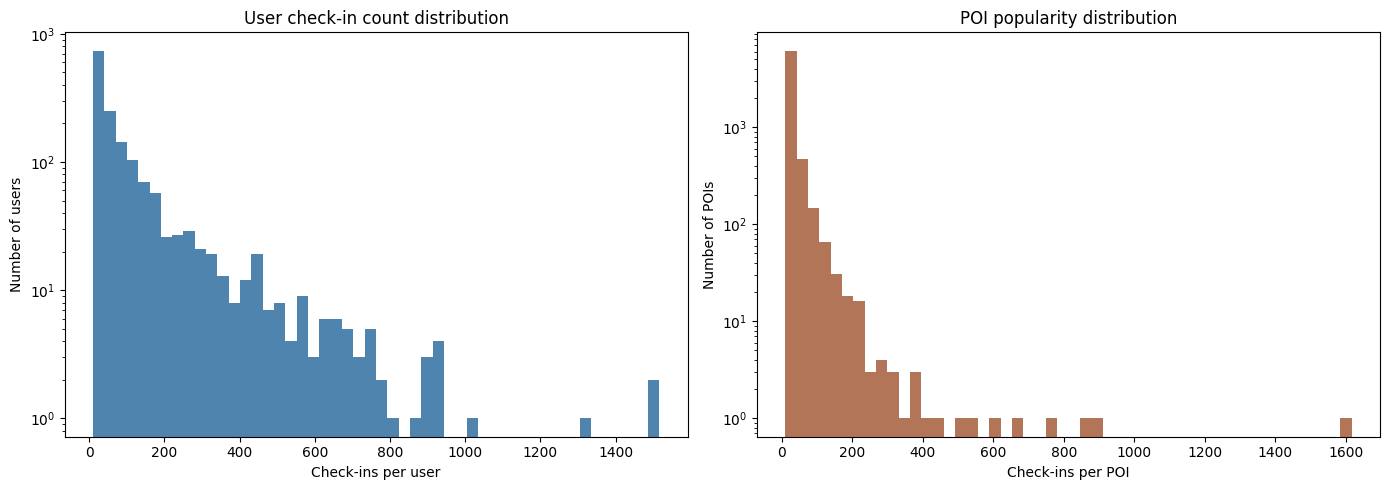

In [148]:
def percentile_or_nan(values: Sequence[int], q: float) -> float:
    """Return a percentile or NaN for an empty sequence."""
    return float(np.percentile(np.asarray(values), q)) if len(values) else float("nan")


user_checkin_counts = filtered_checkins.groupby("user_id").size()
poi_popularity = filtered_checkins.groupby("location_id").size()
social_users = {
    int(user)
    for user, neighbors in user_friendship_adjacency.items()
    if len(neighbors) > 0
}
evaluation_users = {int(user) for user, pois in test_user_pois.items() if len(pois) > 0}
test_pois = set(int(poi) for poi in test_checkins["location_id"].unique())
all_final_pois = set(int(poi) for poi in filtered_checkins["location_id"].unique())
density = float(R_train.nnz / (R_train.shape[0] * R_train.shape[1])) if R_train.shape[0] * R_train.shape[1] else 0.0

summary = pd.DataFrame(
    {
        "metric": [
            "raw check-ins",
            "filtered check-ins",
            "train check-ins",
            "test check-ins",
            "number of users",
            "number of POIs",
            "number of social edges",
            "R_train matrix density",
            "average POIs per user",
            "median POIs per user",
            "users with social connections (%)",
            "POIs appearing in test (%)",
        ],
        "value": [
            metadata["raw_checkin_stats"]["raw_rows"],
            len(filtered_checkins),
            len(train_checkins),
            len(test_checkins),
            len(user_id_to_index),
            len(poi_id_to_index),
            len(filtered_social_edges),
            density,
            float(np.mean([len(pois) for pois in train_user_pois.values()])) if train_user_pois else 0.0,
            float(np.median([len(pois) for pois in train_user_pois.values()])) if train_user_pois else 0.0,
            100.0 * len(social_users) / len(user_id_to_index) if user_id_to_index else 0.0,
            100.0 * len(test_pois) / len(all_final_pois) if all_final_pois else 0.0,
        ],
    }
)
display(summary)

article_reference = pd.DataFrame(
    {
        "metric": ["check-ins", "users", "POIs", "social relations"],
        "article_reference": [209195, 2150, 6668, 17729],
        "notebook_value": [len(filtered_checkins), len(user_id_to_index), len(poi_id_to_index), len(filtered_social_edges)],
    }
)
display(article_reference)
print("Differences from the article reference are not treated as errors; they are documented preprocessing differences.")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(user_checkin_counts.to_numpy(), bins=50, color="#2f6f9f", alpha=0.85)
axes[0].set_title("User check-in count distribution")
axes[0].set_xlabel("Check-ins per user")
axes[0].set_ylabel("Number of users")
axes[0].set_yscale("log")

axes[1].hist(poi_popularity.to_numpy(), bins=50, color="#a65d3b", alpha=0.85)
axes[1].set_title("POI popularity distribution")
axes[1].set_xlabel("Check-ins per POI")
axes[1].set_ylabel("Number of POIs")
axes[1].set_yscale("log")
fig.tight_layout()
plt.show()

# Part 1 Assumptions and Decisions

1. **Split semantics:** The article specifies an 80/20 ratio but not the split unit or random/chronological procedure. The default is per-user random `user_poi_pair`, because it prevents a user–POI pair from appearing in both matrices. `checkin_event` remains available but is decontaminated afterward.
2. **Chronological ordering:** Chronological pair splitting orders a user's POIs by their first observed visit time, with POI ID as a deterministic tie-breaker. Event splitting orders events by timestamp and POI ID.
3. **Minimum interactions:** The requested thresholds of 10 user check-ins and 10 POI check-ins are applied iteratively until stable.
4. **Coordinate aggregation:** The median latitude and median longitude are used for each POI. Any POI with more than one exact observed latitude or longitude is reported as inconsistent.
5. **Social edges:** Friendship edges are treated as undirected, self-loops are removed, and duplicate reverse/copy edges are deduplicated. This makes the reported count a count of unique undirected relations.
6. **Sampling:** Resource mode uses seeded BFS snowball sampling from the largest connected component. It can overrepresent highly connected users; therefore sampled results are not directly comparable to full-dataset paper results.
7. **Sampling fallback:** If no usable connected component exists, a seeded random user sample is used and reported in metadata.
8. **Train-only modeling:** Mappings are made from final training data. The later temporal, geographical, activity-region, power-law, and social models must use training data only. `test_checkins` is reserved for evaluation.
9. **Test-only POIs:** A repair moves at least one complete user–POI pair for every POI that would otherwise occur only in test to training. The number of repairs is recorded.
10. **Duplicate check-ins:** Exact duplicate rows are reported and retained by default because the source contains event records and the paper does not define a duplicate-removal rule. This is configurable through `DROP_EXACT_DUPLICATE_CHECKINS`.
11. **Article reference values:** The reported article statistics are treated as a comparison point, not as an assertion about the raw supplied files. Differences can result from an undocumented subset or preprocessing pipeline.

The complete configuration, filtering history, sampling diagnostics, split diagnostics, source signature, final statistics, and cache paths are stored in the metadata JSON file.

# Part 2: Context Modeling

This section constructs the four ICWMF context components from the outputs of Part 1:

1. Temporal information
2. Geographical information from the user perspective
3. Geographical information from the location perspective
4. Social relationship modeling

Every context object is built from the final training data only. Test check-ins are not used to estimate temporal reference times, activity regions, geographical power-law parameters, geographical candidates, POI coordinates, social scores, or implicit confidence values. `R_full` remains a reporting-only matrix and is not used here.

## Part 2 Configuration

The paper specifies `H = 100`, `alpha_conf = 10`, `eta = 0.5`, 25 location neighbors, and Gaussian `sigma = 0.1`. The unit of `H` is not stated in the paper; this implementation uses days and records that decision in the assumptions section.

The paper does not specify DBSCAN `eps` or `min_samples`, the exact observations used for the power-law fit, the SGD hyperparameters, or a unique distance convention for the location perspective. Those choices are explicit, configurable, and reported in the saved metadata.

In [149]:



# Paper parameters.
H = 100.0
ALPHA_CONF = 10.0
ETA = 0.5
NUMBER_OF_LOCATION_NEIGHBORS = 25
GAUSSIAN_SIGMA = 0.1

# Explicit choices for quantities not fully specified by the paper.
H_UNIT = "days"
DBSCAN_EPS_KM = 5.0
DBSCAN_MIN_SAMPLES = 2
GEO_SGD_LR = 1e-3
GEO_SGD_EPOCHS = 500
GEO_L2 = 1e-4
GEO_TOLERANCE = 1e-8
EPS_DISTANCE_KM = 0.01
# The paper does not define clipping; use all training samples.
GEO_CLIP_QUANTILE = 1.0
REGULARIZE_POWER_LAW_INTERCEPT = True
NORMALIZE_GEO_SCORES = False
MASK_CONTEXT_ON_OBSERVED = True
LOCATION_MODE = "paper_latlon_mode"
GAMMA_MODE = "nonzero_pairs"
GAMMA_EPSILON = 1e-12
EARTH_RADIUS_KM = 6371.0088
# Power-law estimation from distances BETWEEN visited POIs, as described in
# Eq. (12), rather than distance from a POI to its own activity center.
POWER_LAW_N_BINS = 40
POWER_LAW_MAX_PAIRS_PER_USER = 5000
POWER_LAW_DISTANCE_QUANTILE = 1.0
POWER_LAW_MIN_NONEMPTY_BINS = 8

# Bins with very few sampled pairs are unstable at the extreme tails.
POWER_LAW_MIN_RAW_PAIRS_PER_BIN = 1000

# Keep the paper-aligned event-pair weighting.
POWER_LAW_PAIR_WEIGHT = "event_product"

GEO_SGD_LR = 1e-3
GEO_SGD_EPOCHS = 1000
GEO_L2 = 1e-4
GEO_TOLERANCE = 1e-10
EPS_DISTANCE_KM = 0.01
REGULARIZE_POWER_LAW_INTERCEPT = True

# The fitted target is already normalized to a [0,1] relative density.
NORMALIZE_GEO_SCORES = False


# Eq. (11) is used directly. Because Geo_P is a probability-like score, the
# candidate builder below clips only numerical overflow to [0, 1].
NORMALIZE_GEO_SCORES = False
if LOCATION_MODE not in {"paper_latlon_mode", "haversine_adaptive_mode"}:
    raise ValueError("LOCATION_MODE must be paper_latlon_mode or haversine_adaptive_mode.")
if GAMMA_MODE not in {"paper_all_pairs", "nonzero_pairs"}:
    raise ValueError("GAMMA_MODE must be paper_all_pairs or nonzero_pairs.")
if H <= 0 or ALPHA_CONF < 0 or not 0 <= ETA <= 1:
    raise ValueError("H, alpha_conf, and eta have invalid values.")
if NUMBER_OF_LOCATION_NEIGHBORS <= 0 or GAUSSIAN_SIGMA <= 0:
    raise ValueError("Location-neighbor parameters must be positive.")
if DBSCAN_EPS_KM <= 0 or DBSCAN_MIN_SAMPLES <= 0:
    raise ValueError("DBSCAN parameters must be positive.")
if GEO_SGD_LR <= 0 or GEO_SGD_EPOCHS <= 0 or GEO_L2 < 0:
    raise ValueError("Geographical SGD parameters have invalid values.")

required_part1 = {
    "train_checkins", "test_checkins", "filtered_checkins", "R_train", "C_train",
    "user_id_to_index", "poi_id_to_index", "train_user_pois", "test_user_pois",
    "poi_coordinates", "filtered_social_edges", "user_friendship_adjacency",
}
missing_part1 = sorted(name for name in required_part1 if name not in globals())
if missing_part1:
    raise RuntimeError(f"Part 1 outputs are missing: {missing_part1}")

if not isinstance(train_checkins, pd.DataFrame) or not isinstance(test_checkins, pd.DataFrame):
    raise TypeError("train_checkins and test_checkins must be pandas DataFrames.")
if set(train_checkins.columns) != set(test_checkins.columns):
    raise ValueError("Train and test check-in tables have inconsistent columns.")

# These references are intentionally train-only.
train_data = train_checkins.copy()
train_data["user_id"] = train_data["user_id"].astype(np.int64)
train_data["location_id"] = train_data["location_id"].astype(np.int64)
train_data["timestamp"] = pd.to_datetime(train_data["timestamp"], utc=True, errors="raise")
train_data = train_data.sort_values(["user_id", "timestamp", "location_id"], kind="mergesort").reset_index(drop=True)

train_pair_set = set(zip(train_data["user_id"].astype(int), train_data["location_id"].astype(int)))
test_pair_set = set(zip(test_checkins["user_id"].astype(int), test_checkins["location_id"].astype(int)))
assert train_pair_set.isdisjoint(test_pair_set)
assert set(int(poi) for poi in poi_coordinates.index).issuperset(set(int(poi) for poi in poi_id_to_index))
print("Part 2 train-only input check passed.")
print(f"Training check-ins available: {len(train_data):,}")
print(f"Training users: {len(user_id_to_index):,}; training POIs: {len(poi_id_to_index):,}")

Part 2 train-only input check passed.
Training check-ins available: 150,645
Training users: 1,606; training POIs: 6,888


## 2.1 Temporal Information

The Ebbinghaus forgetting curve is implemented as:

`f(t, t0) = exp(-abs(t - t0) / H)`

For every user, `t0` is the newest training timestamp for that user. Time differences are measured in days because the paper does not define the unit of `H`. For every observed training user–POI pair, the weights of all training check-ins are summed into `P_time`.

The confidence weight is `W = 1 + alpha_conf * P_time`. The baseline confidence of one is implicit in the later ALS equations; only the sparse increment `W_extra = alpha_conf * P_time` is stored here. Consequently, unobserved pairs have an implicit baseline and no explicit dense entry.

In [150]:
def build_temporal_context(
    train: pd.DataFrame,
    half_life_parameter: float,
    alpha_conf: float,
    user_id_to_index: Mapping[int, int],
    poi_id_to_index: Mapping[int, int],
) -> Dict[str, Any]:
    """Build sparse temporal preference and confidence-increment matrices."""
    if train.empty:
        raise ValueError("Cannot build temporal context from an empty training table.")
    latest_by_user = train.groupby("user_id")["timestamp"].max()
    ages_days = (
        train["user_id"].map(latest_by_user).to_numpy(dtype="datetime64[ns]")
        - train["timestamp"].to_numpy(dtype="datetime64[ns]")
    ) / np.timedelta64(1, "D")
    ages_days = np.maximum(np.asarray(ages_days, dtype=np.float64), 0.0)
    event_weights = np.exp(-ages_days / float(half_life_parameter))
    weighted = train[["user_id", "location_id"]].copy()
    weighted["temporal_weight"] = event_weights
    grouped = weighted.groupby(["user_id", "location_id"], sort=False)["temporal_weight"].sum().reset_index()
    rows = grouped["user_id"].map(user_id_to_index).to_numpy(dtype=np.int64)
    cols = grouped["location_id"].map(poi_id_to_index).to_numpy(dtype=np.int64)
    values = grouped["temporal_weight"].to_numpy(dtype=np.float64)
    shape = (len(user_id_to_index), len(poi_id_to_index))
    p_time = sparse.coo_matrix((values, (rows, cols)), shape=shape, dtype=np.float64).tocsr()
    w_extra = (p_time * float(alpha_conf)).tocsr()
    p_time.eliminate_zeros()
    w_extra.eliminate_zeros()
    return {
        "P_time": p_time,
        "W_extra": w_extra,
        "latest_timestamp_by_user": latest_by_user,
        "event_temporal_weights": event_weights,
    }


temporal = build_temporal_context(
    train_data,
    H,
    ALPHA_CONF,
    user_id_to_index,
    poi_id_to_index,
)
P_time = temporal["P_time"]
W_extra = temporal["W_extra"]
latest_timestamp_by_user = temporal["latest_timestamp_by_user"]

assert P_time.shape == R_train.shape
assert W_extra.shape == R_train.shape
assert P_time.nnz == R_train.nnz
assert P_time.data.size == 0 or np.all(P_time.data >= 0)
assert W_extra.data.size == 0 or np.all(np.isfinite(W_extra.data))
assert P_time.data.size == 0 or np.all(np.isfinite(P_time.data))
assert W_extra.multiply(R_train.sign()).nnz == W_extra.nnz

# A direct numerical example shows that a newer check-in receives more weight.
example_age_days = np.asarray([1.0, 10.0])
example_weights = np.exp(-example_age_days / H)
temporal_example = pd.DataFrame({"age_days": example_age_days, "forgetting_weight": example_weights})
display(temporal_example)
assert example_weights[0] > example_weights[1]

print(f"P_time: shape={P_time.shape}, nnz={P_time.nnz:,}")
print(f"W_extra: shape={W_extra.shape}, nnz={W_extra.nnz:,}; baseline confidence 1 is implicit.")

,age_days,forgetting_weight
0,1.0,0.990050
1,10.0,0.904837


P_time: shape=(1606, 6888), nnz=42,027
W_extra: shape=(1606, 6888), nnz=42,027; baseline confidence 1 is implicit.


## 2.2 Geographical Information from the User Perspective

Activity regions are identified independently for each user using the unique POIs visited in training. Coordinates are converted to radians and clustered with unweighted DBSCAN using the haversine metric. Check-in frequency is used only for the weighted center in Eq. (9), matching the paper.

The paper does not specify DBSCAN parameters. This implementation uses `DBSCAN_EPS_KM = 5` and `DBSCAN_MIN_SAMPLES = 2`. Noise points (`label = -1`) are kept in per-user diagnostics and are not treated as activity regions. If no valid cluster exists, a weighted centroid of all training POIs for that user is used as a fallback center, with radius equal to the farthest training POI.

In [151]:
def haversine_km(
    lat1_deg: float | np.ndarray,
    lon1_deg: float | np.ndarray,
    lat2_deg: float | np.ndarray,
    lon2_deg: float | np.ndarray,
) -> np.ndarray:
    """Compute vectorized great-circle distances in kilometers."""
    lat1 = np.radians(np.asarray(lat1_deg, dtype=np.float64))
    lon1 = np.radians(np.asarray(lon1_deg, dtype=np.float64))
    lat2 = np.radians(np.asarray(lat2_deg, dtype=np.float64))
    lon2 = np.radians(np.asarray(lon2_deg, dtype=np.float64))
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    return EARTH_RADIUS_KM * 2.0 * np.arcsin(np.sqrt(np.clip(a, 0.0, 1.0)))


def build_activity_regions(
    train: pd.DataFrame,
    poi_coordinates: pd.DataFrame,
    train_user_pois: Mapping[int, Set[int]],
    eps_km: float,
    min_samples: int,
) -> Tuple[Dict[int, List[Dict[str, Any]]], Dict[int, Dict[str, Any]]]:
    """Cluster each user's unique training POIs and construct activity centers."""
    coordinate_lookup = poi_coordinates[["latitude", "longitude"]]
    frequency_lookup = train.groupby(["user_id", "location_id"]).size().to_dict()
    activity_centers: Dict[int, List[Dict[str, Any]]] = {}
    activity_diagnostics: Dict[int, Dict[str, Any]] = {}
    eps_radians = float(eps_km / EARTH_RADIUS_KM)

    for user_id in sorted(int(user) for user in train_user_pois):
        user_pois = sorted(int(poi) for poi in train_user_pois[user_id] if poi in coordinate_lookup.index)
        if not user_pois:
            activity_centers[user_id] = []
            activity_diagnostics[user_id] = {"n_unique_pois": 0, "noise_pois": [], "fallback": True}
            continue
        coords = coordinate_lookup.loc[user_pois, ["latitude", "longitude"]].to_numpy(dtype=np.float64)
        weights = np.asarray([frequency_lookup[(user_id, poi)] for poi in user_pois], dtype=np.float64)
        radians = np.radians(coords)
        clusterer = DBSCAN(
            eps=eps_radians,
            min_samples=min_samples,
            metric="haversine",
            algorithm="ball_tree",
        )
        # The paper uses check-in frequency in Eq. (9) for the center,
        # but does not weight DBSCAN's density test.
        labels = clusterer.fit_predict(radians)
        weighted_clustering = False

        centers: List[Dict[str, Any]] = []
        noise_pois = [poi for poi, label in zip(user_pois, labels) if int(label) == -1]
        for label in sorted(set(int(label) for label in labels if int(label) >= 0)):
            member_positions = np.flatnonzero(labels == label)
            member_pois = [user_pois[int(position)] for position in member_positions]
            member_coords = coords[member_positions]
            member_weights = weights[member_positions]
            center_lat = float(np.average(member_coords[:, 0], weights=member_weights))
            center_lon = float(np.average(member_coords[:, 1], weights=member_weights))
            radii = haversine_km(center_lat, center_lon, member_coords[:, 0], member_coords[:, 1])
            centers.append(
                {
                    "cluster_label": label,
                    "latitude": center_lat,
                    "longitude": center_lon,
                    "radius_km": float(np.max(radii)) if len(radii) else 0.0,
                    "poi_ids": member_pois,
                    "poi_weights": [float(weight) for weight in member_weights],
                    "is_fallback": False,
                }
            )

        fallback = False
        if not centers:
            center_lat = float(np.average(coords[:, 0], weights=weights))
            center_lon = float(np.average(coords[:, 1], weights=weights))
            radii = haversine_km(center_lat, center_lon, coords[:, 0], coords[:, 1])
            centers = [
                {
                    "cluster_label": -2,
                    "latitude": center_lat,
                    "longitude": center_lon,
                    "radius_km": float(np.max(radii)) if len(radii) else 0.0,
                    "poi_ids": user_pois,
                    "poi_weights": [float(weight) for weight in weights],
                    "is_fallback": True,
                }
            ]
            fallback = True

        activity_centers[user_id] = centers
        activity_diagnostics[user_id] = {
            "n_unique_pois": len(user_pois),
            "n_clusters": sum(not center["is_fallback"] for center in centers),
            "noise_pois": noise_pois,
            "fallback": fallback,
            "weighted_clustering": weighted_clustering,
        }
    return activity_centers, activity_diagnostics


activity_centers, activity_diagnostics = build_activity_regions(
    train_data,
    poi_coordinates,
    train_user_pois,
    DBSCAN_EPS_KM,
    DBSCAN_MIN_SAMPLES,
)
assert set(activity_centers).issuperset(set(user_id_to_index))
assert all(np.isfinite(center["latitude"]) and np.isfinite(center["longitude"])
           for centers in activity_centers.values() for center in centers)
assert all(center["radius_km"] >= 0 and np.isfinite(center["radius_km"])
           for centers in activity_centers.values() for center in centers)
fallback_users = sum(any(center["is_fallback"] for center in centers) for centers in activity_centers.values())
total_regions = sum(len(centers) for centers in activity_centers.values())
total_noise = sum(len(info["noise_pois"]) for info in activity_diagnostics.values())
print(f"Activity regions: {total_regions:,}; users with fallback center: {fallback_users:,}; noise POIs: {total_noise:,}")

Activity regions: 3,964; users with fallback center: 261; noise POIs: 5,791


### Geographical power-law estimation

For every observed training user–POI pair, the response distance is the distance from the POI to the nearest activity center of that user. The executable choice for the power-law sample is therefore:

`x = max(distance_km, EPS_DISTANCE_KM)` and `y = R_train[u,l]`.

Both variables are clipped at their 99th percentiles to reduce the influence of extreme observations. The model is fitted in base-10 logarithmic space:

`log10(y) = w0 + w1 * log10(x)`  
`alpha_geo = 10**w0` and `beta_geo = w1`

The primary estimate is a from-scratch SGD implementation with configurable learning rate, epochs, tolerance, and L2 penalty. A closed-form ridge estimate is computed only as a diagnostic comparison.

,distance_km,bin_left_km,bin_right_km,bin_width_km,weighted_frequency,raw_pair_count,probability_mass,probability_density_per_km,relative_probability_density,used_for_fit
0,0.011988,0.010020,0.014341,0.004321,7.140556e+04,207,0.003501,8.100829e-01,1.000000e+00,False
1,0.017157,0.014341,0.020526,0.006185,6.233120e+04,299,0.003056,4.940700e-01,6.099006e-01,False
2,0.024556,0.020526,0.029378,0.008852,2.984904e+04,657,0.001463,1.653100e-01,2.040655e-01,False
3,0.035146,0.029378,0.042047,0.012669,7.603639e+04,985,0.003728,2.942224e-01,3.632003e-01,False
4,0.050303,0.042047,0.060180,0.018133,1.598687e+05,1893,0.007837,4.322185e-01,5.335485e-01,True
5,0.071996,0.060180,0.086132,0.025952,2.079796e+05,2767,0.010196,3.928675e-01,4.849719e-01,True
6,0.103044,0.086132,0.123276,0.037144,3.499698e+05,4697,0.017157,4.618931e-01,5.701801e-01,True
7,0.147481,0.123276,0.176438,0.053162,2.736199e+05,6884,0.013414,2.523157e-01,3.114689e-01,True
8,0.211082,0.176438,0.252527,0.076088,3.691185e+05,10571,0.018095,2.378198e-01,2.935747e-01,True
9,0.302110,0.252527,0.361428,0.108901,4.523293e+05,14164,0.022175,2.036210e-01,2.513582e-01,True


,distance_km,empirical_relative_density,fitted_relative_density
0,0.050303,0.533548,2.142539
1,0.071996,0.484972,1.456789
2,0.103044,0.570180,0.990523
3,0.147481,0.311469,0.673492
4,0.211082,0.293575,0.457932
5,0.302110,0.251358,0.311364
6,0.432394,0.259890,0.211708
7,0.618862,0.150111,0.143948
8,0.885744,0.134838,0.097875
9,1.267717,0.127450,0.066549


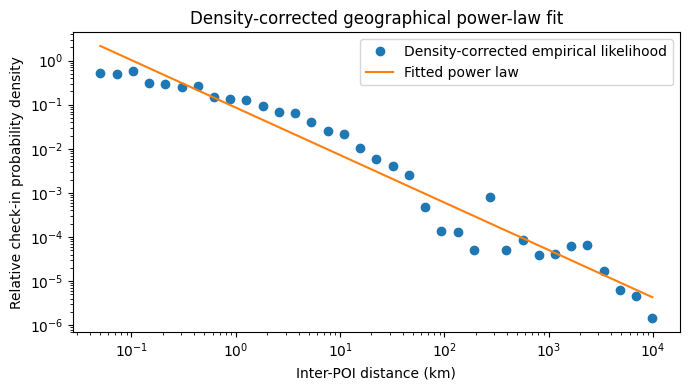

SGD alpha_geo=0.0858976886; beta_geo=-1.07589309; epochs=1000; log-space R^2=0.9520


,distance_km,power_law_score
0,0.1,1.022997
1,1.0,0.085898
2,10.0,0.007213
3,100.0,0.000606


In [152]:


def _pair_ranks_to_positions(
    ranks: np.ndarray,
    n_items: int,
) -> Tuple[np.ndarray, np.ndarray]:
    """Convert upper-triangle pair ranks to unique (left, right) positions."""
    ranks = np.asarray(ranks, dtype=np.int64)

    # Number of pairs before row i:
    # cumulative(i) = i * (2*n_items - i - 1) / 2
    a = 2 * n_items - 1
    left = np.floor(
        (a - np.sqrt(np.maximum(a * a - 8.0 * ranks, 0.0))) / 2.0
    ).astype(np.int64)

    cumulative = left * (2 * n_items - left - 1) // 2

    # Correct rare floating-point boundary errors.
    too_large = cumulative > ranks
    while np.any(too_large):
        left[too_large] -= 1
        cumulative = left * (2 * n_items - left - 1) // 2
        too_large = cumulative > ranks

    next_cumulative = (left + 1) * (2 * n_items - left - 2) // 2
    too_small = next_cumulative <= ranks
    while np.any(too_small):
        left[too_small] += 1
        cumulative = left * (2 * n_items - left - 1) // 2
        next_cumulative = (left + 1) * (2 * n_items - left - 2) // 2
        too_small = next_cumulative <= ranks

    right = ranks - cumulative + left + 1
    return left.astype(np.int64), right.astype(np.int64)


def _sample_pair_positions(
    n_items: int,
    max_pairs: int,
    rng: np.random.Generator,
) -> Tuple[np.ndarray, np.ndarray, float]:
    """Sample unordered POI pairs uniformly without replacement.

    Using replacement, as in the previous version, could repeatedly select the
    same POI pair and increase histogram variance. This version samples unique
    pair ranks and uses an expansion factor only when subsampling is necessary.
    """
    total_pairs = n_items * (n_items - 1) // 2
    if total_pairs <= 0:
        return (
            np.empty(0, dtype=np.int64),
            np.empty(0, dtype=np.int64),
            1.0,
        )

    sample_size = min(int(max_pairs), int(total_pairs))

    if sample_size == total_pairs:
        left, right = np.triu_indices(n_items, k=1)
        return (
            left.astype(np.int64),
            right.astype(np.int64),
            1.0,
        )

    ranks = rng.choice(total_pairs, size=sample_size, replace=False)
    left, right = _pair_ranks_to_positions(ranks, n_items)
    expansion = float(total_pairs / sample_size)
    return left, right, expansion



def power_law_training_samples(
    train: pd.DataFrame,
    poi_coordinates: pd.DataFrame,
    epsilon_distance_km: float,
    n_bins: int,
    max_pairs_per_user: int,
    distance_quantile: float,
    min_raw_pairs_per_bin: int,
    seed: int,
) -> Tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    """Build density-corrected power-law training samples.

    x:
        Haversine distance between two POIs visited by the same user.

    Pair weight:
        r_ui * r_uj, matching the number of represented cross-location
        check-in-event pairs.

    Important correction:
        For logarithmic bins, probability mass must be divided by bin width.
        Without that correction, increasingly wide bins create an artificial
        +1 shift in the fitted log-log slope.
    """
    if n_bins < 3:
        raise ValueError("n_bins must be at least 3.")
    if max_pairs_per_user <= 0:
        raise ValueError("max_pairs_per_user must be positive.")
    if min_raw_pairs_per_bin <= 0:
        raise ValueError("min_raw_pairs_per_bin must be positive.")
    if not 0.0 < distance_quantile <= 1.0:
        raise ValueError("distance_quantile must be in (0, 1].")

    coordinate_lookup = poi_coordinates[["latitude", "longitude"]]

    pair_counts = (
        train.groupby(["user_id", "location_id"], sort=True)
        .size()
        .rename("frequency")
        .reset_index()
    )

    rng = np.random.default_rng(seed)
    all_distances: List[np.ndarray] = []
    all_weights: List[np.ndarray] = []

    users_used = 0
    sampled_pair_rows = 0
    estimated_full_pairs = 0

    for user_id, user_rows in pair_counts.groupby("user_id", sort=True):
        user_rows = user_rows[
            user_rows["location_id"].isin(coordinate_lookup.index)
        ].reset_index(drop=True)

        if len(user_rows) < 2:
            continue

        poi_ids = user_rows["location_id"].astype(int).to_numpy()
        frequencies = user_rows["frequency"].to_numpy(dtype=np.float64)
        coords = coordinate_lookup.loc[
            poi_ids, ["latitude", "longitude"]
        ].to_numpy(dtype=np.float64)

        left, right, expansion = _sample_pair_positions(
            len(poi_ids),
            max_pairs_per_user,
            rng,
        )
        if len(left) == 0:
            continue

        distances = haversine_km(
            coords[left, 0],
            coords[left, 1],
            coords[right, 0],
            coords[right, 1],
        )

        weights = frequencies[left] * frequencies[right] * expansion

        valid = (
            np.isfinite(distances)
            & np.isfinite(weights)
            & (distances >= epsilon_distance_km)
            & (weights > 0)
        )
        if not np.any(valid):
            continue

        all_distances.append(
            np.asarray(distances[valid], dtype=np.float64)
        )
        all_weights.append(
            np.asarray(weights[valid], dtype=np.float64)
        )

        users_used += 1
        sampled_pair_rows += int(np.count_nonzero(valid))
        estimated_full_pairs += int(
            len(poi_ids) * (len(poi_ids) - 1) // 2
        )

    if not all_distances:
        raise ValueError(
            "No valid inter-POI distance samples were available."
        )

    distances = np.concatenate(all_distances)
    weights = np.concatenate(all_weights)

    distance_cap = float(np.quantile(distances, distance_quantile))
    keep = distances <= distance_cap
    distances = distances[keep]
    weights = weights[keep]

    min_distance = max(
        float(np.min(distances)),
        float(epsilon_distance_km),
    )
    max_distance = float(np.max(distances))

    if max_distance <= min_distance:
        raise ValueError("Power-law distances do not span a usable range.")

    bin_edges = np.geomspace(
        min_distance,
        max_distance,
        int(n_bins) + 1,
    )
    bin_widths = np.diff(bin_edges)
    bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])

    weighted_frequency, _ = np.histogram(
        distances,
        bins=bin_edges,
        weights=weights,
    )
    raw_pair_count, _ = np.histogram(
        distances,
        bins=bin_edges,
    )

    total_weight = float(weighted_frequency.sum())
    if total_weight <= 0:
        raise ValueError("The weighted distance histogram has zero mass.")

    # Probability mass in each unequal-width log bin.
    probability_mass = weighted_frequency / total_weight

    # Density correction: remove the artificial effect of wider far bins.
    probability_density = probability_mass / bin_widths

    finite_positive = (
        (weighted_frequency > 0)
        & np.isfinite(probability_density)
        & (probability_density > 0)
    )
    if not np.any(finite_positive):
        raise ValueError("No positive probability-density bins were produced.")

    # Make the fitted quantity probability-like and bounded by one, as in the
    # paper's log-scale figure. This scaling does not change beta.
    density_scale = float(np.max(probability_density[finite_positive]))
    relative_probability_density = probability_density / density_scale

    reliable = (
        finite_positive
        & (raw_pair_count >= int(min_raw_pairs_per_bin))
    )

    if np.count_nonzero(reliable) < POWER_LAW_MIN_NONEMPTY_BINS:
        raise ValueError(
            "Too few reliable power-law bins. Lower "
            "POWER_LAW_MIN_RAW_PAIRS_PER_BIN or increase sample size."
        )

    x = bin_centers[reliable].astype(np.float64)
    y = relative_probability_density[reliable].astype(np.float64)

    sample_table = pd.DataFrame({
        "distance_km": bin_centers,
        "bin_left_km": bin_edges[:-1],
        "bin_right_km": bin_edges[1:],
        "bin_width_km": bin_widths,
        "weighted_frequency": weighted_frequency,
        "raw_pair_count": raw_pair_count,
        "probability_mass": probability_mass,
        "probability_density_per_km": probability_density,
        "relative_probability_density": relative_probability_density,
        "used_for_fit": reliable,
    })

    sample_table.attrs["users_used"] = users_used
    sample_table.attrs["sampled_pair_rows"] = sampled_pair_rows
    sample_table.attrs["estimated_full_pairs"] = estimated_full_pairs
    sample_table.attrs["distance_cap_km"] = distance_cap
    sample_table.attrs["density_scale"] = density_scale
    sample_table.attrs["min_raw_pairs_per_bin"] = int(
        min_raw_pairs_per_bin
    )

    return x, y, sample_table


def fit_power_law_sgd(
    distances_km: np.ndarray,
    probabilities: np.ndarray,
    learning_rate: float,
    epochs: int,
    l2_penalty: float,
    tolerance: float,
) -> Dict[str, Any]:
    """Fit log10(y) = w0 + w1*log10(x) with explicit SGD."""
    distances_km = np.asarray(distances_km, dtype=np.float64)
    probabilities = np.asarray(probabilities, dtype=np.float64)

    valid = (
        np.isfinite(distances_km)
        & np.isfinite(probabilities)
        & (distances_km > 0)
        & (probabilities > 0)
    )
    if np.count_nonzero(valid) < 3:
        raise ValueError("At least three positive power-law samples are required.")

    log_x = np.log10(np.maximum(distances_km[valid], EPS_DISTANCE_KM))
    log_y = np.log10(np.maximum(probabilities[valid], np.finfo(float).tiny))
    design = np.column_stack([np.ones(len(log_x)), log_x])

    ridge_diagonal = (
        np.eye(2)
        if REGULARIZE_POWER_LAW_INTERCEPT
        else np.diag([0.0, 1.0])
    )
    ridge_matrix = design.T @ design + l2_penalty * ridge_diagonal
    ridge_weights = np.linalg.solve(ridge_matrix, design.T @ log_y)

    # Stable, data-informed initialization; the parameters are still refined
    # with the paper's explicit SGD updates.
    weights = ridge_weights.astype(np.float64).copy()
    loss_history: List[float] = []
    rng = np.random.default_rng(RANDOM_SEED)
    previous_loss: Optional[float] = None

    for _epoch in range(int(epochs)):
        order = rng.permutation(len(log_x))
        for index in order:
            prediction = float(weights @ design[index])
            error = prediction - log_y[index]
            gradient = error * design[index]
            if REGULARIZE_POWER_LAW_INTERCEPT:
                gradient += l2_penalty * weights
            else:
                gradient[1:] += l2_penalty * weights[1:]
            weights -= learning_rate * gradient

        residual = design @ weights - log_y
        regularization = (
            weights if REGULARIZE_POWER_LAW_INTERCEPT else weights[1:]
        )
        loss = float(
            np.mean(residual ** 2)
            + l2_penalty * np.sum(regularization ** 2)
        )
        loss_history.append(loss)

        if previous_loss is not None and abs(previous_loss - loss) < tolerance:
            break
        previous_loss = loss

    w0, w1 = float(weights[0]), float(weights[1])
    fitted_log_y = design @ weights
    ss_res = float(np.sum((log_y - fitted_log_y) ** 2))
    ss_tot = float(np.sum((log_y - np.mean(log_y)) ** 2))
    r2_log = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")

    result = {
        "w0": w0,
        "w1": w1,
        "alpha_geo": float(10.0 ** np.clip(w0, -300.0, 300.0)),
        "beta_geo": w1,
        "loss_history": loss_history,
        "epochs_run": len(loss_history),
        "ridge_w0": float(ridge_weights[0]),
        "ridge_w1": float(ridge_weights[1]),
        "ridge_alpha_geo": float(
            10.0 ** np.clip(ridge_weights[0], -300.0, 300.0)
        ),
        "ridge_beta_geo": float(ridge_weights[1]),
        "log_x": log_x,
        "log_y": log_y,
        "fitted_log_y": fitted_log_y,
        "r2_log": float(r2_log),
    }
    return result


geo_x, geo_y, power_law_samples = power_law_training_samples(
    train_data,
    poi_coordinates,
    EPS_DISTANCE_KM,
    POWER_LAW_N_BINS,
    POWER_LAW_MAX_PAIRS_PER_USER,
    POWER_LAW_DISTANCE_QUANTILE,
    POWER_LAW_MIN_RAW_PAIRS_PER_BIN,
    RANDOM_SEED,
)

geo_model = fit_power_law_sgd(
    geo_x,
    geo_y,
    GEO_SGD_LR,
    GEO_SGD_EPOCHS,
    GEO_L2,
    GEO_TOLERANCE,
)

alpha_geo = geo_model["alpha_geo"]
beta_geo = geo_model["beta_geo"]

if not np.isfinite(alpha_geo) or not np.isfinite(beta_geo):
    raise FloatingPointError(
        "The geographical power-law parameters are not finite."
    )
if alpha_geo <= 0:
    raise ValueError("alpha_geo must be positive.")
if beta_geo >= 0:
    raise RuntimeError(
        f"Estimated beta_geo={beta_geo:.6f} is non-negative."
    )

assert np.all((geo_y > 0) & (geo_y <= 1.0))
assert np.all(np.isfinite(geo_model["loss_history"]))


fit_table = pd.DataFrame({
    "distance_km": geo_x,
    "empirical_relative_density": geo_y,
    "fitted_relative_density": (
        alpha_geo * np.power(geo_x, beta_geo)
    ),
})

display(power_law_samples)
display(fit_table)

plt.figure(figsize=(7, 4))
plt.loglog(
    fit_table["distance_km"],
    fit_table["empirical_relative_density"],
    "o",
    label="Density-corrected empirical likelihood",
)
plt.loglog(
    fit_table["distance_km"],
    fit_table["fitted_relative_density"],
    "-",
    label="Fitted power law",
)
plt.xlabel("Inter-POI distance (km)")
plt.ylabel("Relative check-in probability density")
plt.title("Density-corrected geographical power-law fit")
plt.legend()
plt.tight_layout()
plt.show()

print(
    f"SGD alpha_geo={alpha_geo:.9g}; "
    f"beta_geo={beta_geo:.9g}; "
    f"epochs={geo_model['epochs_run']}; "
    f"log-space R^2={geo_model['r2_log']:.4f}"
)

sanity_distances = np.asarray(
    [0.1, 1.0, 10.0, 100.0],
    dtype=np.float64,
)
sanity_scores = alpha_geo * np.power(
    sanity_distances,
    beta_geo,
)

sanity_table = pd.DataFrame({
    "distance_km": sanity_distances,
    "power_law_score": sanity_scores,
})
display(sanity_table)

assert np.all(np.diff(sanity_scores) < 0)

# The current notebook output should move from an almost-flat decay to a
# substantial decay. Do not hard-code the exact beta, but investigate if:
if beta_geo > -0.3:
    warnings.warn(
        "beta_geo is still too close to zero after density correction. "
        "Inspect the histogram and user sampling."
    )
if geo_model["r2_log"] < 0.5:
    warnings.warn(
        "The power-law fit remains weak (R^2 < 0.5)."
    )




### Geographical candidate scores

A `BallTree` with haversine distance searches each user's activity-region disks without constructing an `N x M` dense matrix. Only unvisited training POIs are candidates. For each candidate, the minimum distance to any of the user's activity centers is used in:

`raw_geo_score = alpha_geo * d**beta_geo`

Raw scores are computed in log space for numerical stability and normalized by the largest valid training-derived raw score, then clipped to `[0, 1]`. Observed training POIs are never written to `Geo_P`.

In [153]:

def build_geographical_candidate_matrix(
    activity_centers: Mapping[int, Sequence[Mapping[str, Any]]],
    train_user_pois: Mapping[int, Set[int]],
    poi_coordinates: pd.DataFrame,
    user_id_to_index: Mapping[int, int],
    poi_id_to_index: Mapping[int, int],
    alpha_geo_value: float,
    beta_geo_value: float,
) -> Tuple[sparse.csr_matrix, Dict[str, Any], pd.DataFrame]:
    """Build sparse geographical probabilities for unvisited candidate POIs."""
    if alpha_geo_value <= 0 or not np.isfinite(alpha_geo_value):
        raise ValueError("alpha_geo_value must be finite and positive.")
    if beta_geo_value >= 0 or not np.isfinite(beta_geo_value):
        raise ValueError("beta_geo_value must be finite and negative.")

    poi_ids = sorted(int(poi) for poi in poi_id_to_index)
    coordinates = poi_coordinates.loc[
        poi_ids, ["latitude", "longitude"]
    ].to_numpy(dtype=np.float64)
    poi_radians = np.radians(coordinates)
    tree = BallTree(poi_radians, metric="haversine")

    rows: List[int] = []
    cols: List[int] = []
    candidate_records: List[Dict[str, Any]] = []
    log_alpha = math.log(float(alpha_geo_value))

    for user_id in sorted(int(user) for user in user_id_to_index):
        centers = activity_centers.get(user_id, [])
        observed = set(int(poi) for poi in train_user_pois.get(user_id, set()))
        candidate_min_distance: Dict[int, float] = {}

        for center in centers:
            radius_km = max(float(center["radius_km"]), 0.0)
            if radius_km <= 0:
                continue

            center_point = np.radians(
                [[center["latitude"], center["longitude"]]]
            )
            neighbor_indices = tree.query_radius(
                center_point,
                r=radius_km / EARTH_RADIUS_KM,
                return_distance=False,
            )[0]

            for poi_position in neighbor_indices.tolist():
                poi_id = poi_ids[int(poi_position)]
                if poi_id in observed:
                    continue

                distance_km = float(haversine_km(
                    center["latitude"],
                    center["longitude"],
                    coordinates[int(poi_position), 0],
                    coordinates[int(poi_position), 1],
                ))
                previous = candidate_min_distance.get(poi_id)
                if previous is None or distance_km < previous:
                    candidate_min_distance[poi_id] = distance_km

        for poi_id, distance_km in candidate_min_distance.items():
            distance_for_model = max(distance_km, EPS_DISTANCE_KM)
            log_raw = log_alpha + beta_geo_value * math.log(distance_for_model)
            if not np.isfinite(log_raw):
                continue

            raw_score = float(np.exp(np.clip(log_raw, -745.0, 709.0)))
            rows.append(user_id_to_index[user_id])
            cols.append(poi_id_to_index[poi_id])
            candidate_records.append({
                "user_id": user_id,
                "location_id": poi_id,
                "distance_km": distance_km,
                "log_power_law_score": log_raw,
                "raw_power_law_score": raw_score,
            })

    shape = (len(user_id_to_index), len(poi_id_to_index))
    if candidate_records:
        raw_values = np.asarray(
            [record["raw_power_law_score"] for record in candidate_records],
            dtype=np.float64,
        )

        if NORMALIZE_GEO_SCORES:
            maximum = float(np.max(raw_values))
            geo_values = raw_values / maximum if maximum > 0 else raw_values
            normalization = "global maximum normalization"
        else:
            geo_values = raw_values
            normalization = "direct Eq. (11) score"

        # Geo_P is used as a probability/confidence component in Eq. (23).
        # Clipping affects only impossible probability values caused by
        # extrapolating the fitted curve to very small distances.
        geo_values = np.clip(geo_values, 0.0, 1.0)

        matrix = sparse.coo_matrix(
            (
                geo_values,
                (np.asarray(rows, dtype=np.int64), np.asarray(cols, dtype=np.int64)),
            ),
            shape=shape,
            dtype=np.float64,
        ).tocsr()
        candidate_table = pd.DataFrame(candidate_records)
        candidate_table["geo_score"] = geo_values
    else:
        matrix = sparse.csr_matrix(shape, dtype=np.float64)
        candidate_table = pd.DataFrame(columns=[
            "user_id",
            "location_id",
            "distance_km",
            "log_power_law_score",
            "raw_power_law_score",
            "geo_score",
        ])
        normalization = "no candidates"

    matrix.eliminate_zeros()
    stats = {
        "candidate_pairs": int(matrix.nnz),
        "users_with_candidates": (
            int(np.unique(np.asarray(rows, dtype=np.int64)).size) if rows else 0
        ),
        "normalization": normalization,
        "minimum_geo_score": float(matrix.data.min()) if matrix.nnz else 0.0,
        "maximum_geo_score": float(matrix.data.max()) if matrix.nnz else 0.0,
        "mean_geo_score": float(matrix.data.mean()) if matrix.nnz else 0.0,
    }
    return matrix, stats, candidate_table


Geo_P, geo_candidate_stats, geo_candidate_table = build_geographical_candidate_matrix(
    activity_centers,
    train_user_pois,
    poi_coordinates,
    user_id_to_index,
    poi_id_to_index,
    alpha_geo,
    beta_geo,
)

positive_mask = R_train.copy()
positive_mask.data = np.ones_like(positive_mask.data)

assert Geo_P.shape == R_train.shape
assert Geo_P.data.size == 0 or np.all(np.isfinite(Geo_P.data))
assert Geo_P.data.size == 0 or np.all((Geo_P.data >= 0) & (Geo_P.data <= 1))
assert Geo_P.multiply(positive_mask).nnz == 0

print(f"Geographical candidate pairs: {geo_candidate_stats['candidate_pairs']:,}")
print(
    "Users with geographical candidates: "
    f"{geo_candidate_stats['users_with_candidates']:,}"
)
print(
    "Geo_P score range: "
    f"{geo_candidate_stats['minimum_geo_score']:.6g} to "
    f"{geo_candidate_stats['maximum_geo_score']:.6g}"
)

if Geo_P.nnz:
    geo_quantiles = np.quantile(
        Geo_P.data,
        [0.0, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99, 1.0],
    )
    print("Geo_P quantiles:")
    for q, value in zip(
        [0, 10, 25, 50, 75, 90, 99, 100],
        geo_quantiles,
    ):
        print(f"  q{q:02d}: {value:.8g}")

    q10 = float(geo_quantiles[1])
    q90 = float(geo_quantiles[5])
    if q10 > 0 and q90 / q10 < 2.0:
        warnings.warn(
            "Geo_P still has little score separation; inspect candidate "
            "distance range and activity-region radii."
        )



Geographical candidate pairs: 500,935
Users with geographical candidates: 1,259
Geo_P score range: 3.35485e-06 to 1
Geo_P quantiles:
  q00: 3.3548461e-06
  q10: 3.9747494e-05
  q25: 0.0074545698
  q50: 0.035006024
  q75: 0.080513981
  q90: 0.17805714
  q99: 0.74412785
  q100: 1


## 2.3 Geographical Information from the Location Perspective

For every training POI, the 25 nearest training POIs are found with `NearestNeighbors`. The primary `paper_latlon_mode` applies Euclidean distance directly to raw latitude/longitude degrees and uses `sigma = 0.1`, which is closest to the paper's displayed Gaussian formula. The optional `haversine_adaptive_mode` uses kilometer distances and sets sigma to the median nonzero neighbor distance.

Self-neighbors are removed, Gaussian weights are row-normalized, and the sparse matrix `T` has at most 25 nonzero values per row. Later, the location-regularization term can use `V_hat = T @ V`.

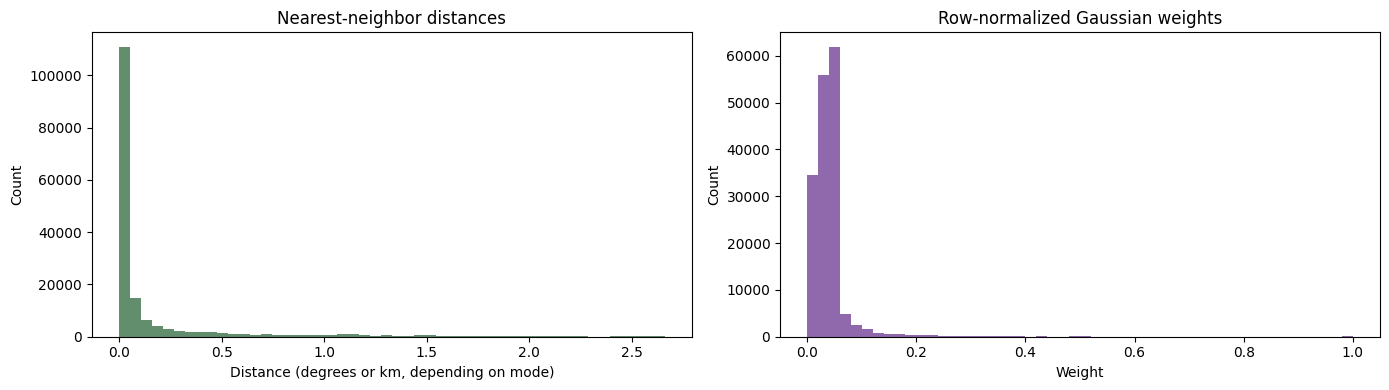

T: shape=(6888, 6888), nnz=165,907, max row nnz=25


In [154]:
def build_location_matrix(
    poi_coordinates: pd.DataFrame,
    number_neighbors: int,
    mode: str,
    sigma: float,
) -> Tuple[sparse.csr_matrix, Dict[str, Any], np.ndarray, np.ndarray]:
    """Build row-normalized sparse POI-neighbor Gaussian matrix T."""
    poi_ids = sorted(int(poi) for poi in poi_coordinates.index)
    coordinate_degrees = poi_coordinates.loc[poi_ids, ["latitude", "longitude"]].to_numpy(dtype=np.float64)
    n_pois = len(poi_ids)
    if n_pois == 0:
        return sparse.csr_matrix((0, 0), dtype=np.float64), {"neighbor_distances": []}, np.empty((0, 2)), np.empty(0)
    n_query = min(n_pois, number_neighbors + 1)

    if mode == "paper_latlon_mode":
        model_coordinates = coordinate_degrees
        neighbor_model = NearestNeighbors(n_neighbors=n_query, metric="euclidean", algorithm="auto")
        neighbor_model.fit(model_coordinates)
        distances, indices = neighbor_model.kneighbors(model_coordinates, return_distance=True)
        distance_values = distances[:, 1:]
        sigma_value = float(sigma)
    elif mode == "haversine_adaptive_mode":
        model_coordinates = np.radians(coordinate_degrees)
        neighbor_model = NearestNeighbors(n_neighbors=n_query, metric="haversine", algorithm="ball_tree")
        neighbor_model.fit(model_coordinates)
        distances_radians, indices = neighbor_model.kneighbors(model_coordinates, return_distance=True)
        distance_values = distances_radians[:, 1:] * EARTH_RADIUS_KM
        nonzero_distances = distance_values[distance_values > 0]
        sigma_value = float(np.median(nonzero_distances)) if len(nonzero_distances) else float(sigma)
        sigma_value = max(sigma_value, np.finfo(float).eps)
    else:
        raise ValueError(f"Unsupported location mode: {mode}")

    row_indices: List[int] = []
    col_indices: List[int] = []
    values: List[float] = []
    all_distances: List[float] = []
    for row in range(n_pois):
        for position, neighbor in enumerate(indices[row, 1:].tolist()):
            neighbor = int(neighbor)
            distance = float(distance_values[row, position])
            if neighbor == row or not np.isfinite(distance):
                continue
            weight = math.exp(-((distance ** 2) / (sigma_value ** 2)))
            # Ignore subnormal weights before row normalization to avoid overflow.
            if weight >= np.finfo(float).tiny and np.isfinite(weight):
                row_indices.append(row)
                col_indices.append(neighbor)
                values.append(weight)
                all_distances.append(distance)

    matrix = sparse.coo_matrix((np.asarray(values), (np.asarray(row_indices), np.asarray(col_indices))), shape=(n_pois, n_pois), dtype=np.float64).tocsr()
    matrix.setdiag(0.0)
    matrix.eliminate_zeros()
    row_sums = np.asarray(matrix.sum(axis=1)).ravel()
    nonempty = np.isfinite(row_sums) & (row_sums >= np.finfo(float).tiny)
    inverse = np.zeros_like(row_sums, dtype=np.float64)
    inverse[nonempty] = 1.0 / row_sums[nonempty]
    matrix = sparse.diags(inverse).dot(matrix).tocsr()
    matrix.eliminate_zeros()
    stats = {
        "mode": mode,
        "sigma_used": sigma_value,
        "n_pois": n_pois,
        "neighbor_count_requested": number_neighbors,
        "max_row_nnz": int(np.diff(matrix.indptr).max()) if n_pois else 0,
        "nonempty_rows": int(nonempty.sum()),
        "neighbor_distances": all_distances,
    }
    return matrix, stats, coordinate_degrees, np.asarray(all_distances, dtype=np.float64)


T, location_stats, location_coordinates_degrees, location_neighbor_distances = build_location_matrix(
    poi_coordinates,
    NUMBER_OF_LOCATION_NEIGHBORS,
    LOCATION_MODE,
    GAUSSIAN_SIGMA,
)
assert T.shape == (len(poi_id_to_index), len(poi_id_to_index))
assert T.nnz == 0 or np.all(np.isfinite(T.data))
assert T.nnz == 0 or np.all(T.data >= 0)
assert T.diagonal().sum() == 0
assert int(np.diff(T.indptr).max()) <= NUMBER_OF_LOCATION_NEIGHBORS if T.shape[0] else True
nonempty_row_sums = np.asarray(T.sum(axis=1)).ravel()
assert np.allclose(nonempty_row_sums[nonempty_row_sums > 0], 1.0, atol=1e-8)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
if len(location_neighbor_distances):
    axes[0].hist(location_neighbor_distances, bins=50, color="#477a53", alpha=0.85)
axes[0].set_title("Nearest-neighbor distances")
axes[0].set_xlabel("Distance (degrees or km, depending on mode)")
axes[0].set_ylabel("Count")
if T.nnz:
    axes[1].hist(T.data, bins=50, color="#7b4f9e", alpha=0.85)
axes[1].set_title("Row-normalized Gaussian weights")
axes[1].set_xlabel("Weight")
axes[1].set_ylabel("Count")
fig.tight_layout()
plt.show()
print(f"T: shape={T.shape}, nnz={T.nnz:,}, max row nnz={location_stats['max_row_nnz']}")

## 2.4 Social Relationship Modeling

Friendship edges are restricted to users represented in the final training mappings. The graph is undirected, self-loops are absent, and `S` is a sparse CSR matrix. Social check-in frequency is:

`Z = S @ R_train`

The primary gamma calculation follows the paper's all-pairs numerator:

`gamma = 1 + (N*M) / sum(log(1 + Z[u,l]))`

Since `Z` is sparse, the denominator is evaluated only over nonzero entries. The optional `nonzero_pairs` mode replaces `N*M` with `Z.nnz` for sensitivity analysis. `F_soc = 1 - (Z + 1)**(1 - gamma)` is retained only for positive social candidates and is zeroed on training positives.

In [155]:
def build_social_context(
    filtered_social_edges: pd.DataFrame,
    user_id_to_index: Mapping[int, int],
    r_train: sparse.csr_matrix,
    gamma_mode: str,
    gamma_epsilon: float,
) -> Dict[str, Any]:
    """Build sparse S, Z, gamma, and train-positive-masked social preference."""
    n_users, n_pois = r_train.shape
    rows: List[int] = []
    cols: List[int] = []
    for left, right in filtered_social_edges[["user_id_1", "user_id_2"]].itertuples(index=False, name=None):
        left = int(left)
        right = int(right)
        if left == right or left not in user_id_to_index or right not in user_id_to_index:
            continue
        left_index = user_id_to_index[left]
        right_index = user_id_to_index[right]
        rows.extend([left_index, right_index])
        cols.extend([right_index, left_index])
    if rows:
        s = sparse.coo_matrix(
            (np.ones(len(rows), dtype=np.float64), (np.asarray(rows), np.asarray(cols))),
            shape=(n_users, n_users),
        ).tocsr()
        s.data[:] = 1.0
        s.eliminate_zeros()
    else:
        s = sparse.csr_matrix((n_users, n_users), dtype=np.float64)
    s.setdiag(0.0)
    s.eliminate_zeros()
    z = (s @ r_train).tocsr()
    z.eliminate_zeros()

    denominator = float(np.log1p(z.data).sum()) if z.nnz else 0.0
    numerator = float(n_users * n_pois) if gamma_mode == "paper_all_pairs" else float(z.nnz)
    if denominator <= gamma_epsilon:
        warnings.warn("Social gamma denominator is zero or very small; gamma_epsilon is used.")
        denominator = gamma_epsilon
    gamma = 1.0 + numerator / denominator

    if z.nnz:
        social_values = 1.0 - np.power(z.data + 1.0, 1.0 - gamma)
        social_values = np.clip(social_values, 0.0, 1.0)
        z_coo = z.tocoo()
        f_soc = sparse.coo_matrix(
            (social_values, (z_coo.row, z_coo.col)),
            shape=z.shape,
            dtype=np.float64,
        ).tocsr()
        if MASK_CONTEXT_ON_OBSERVED:
            f_soc = (f_soc - f_soc.multiply(r_train.sign())).tocsr()
            f_soc.eliminate_zeros()
    else:
        f_soc = sparse.csr_matrix(z.shape, dtype=np.float64)
    f_soc.eliminate_zeros()
    return {
        "S": s,
        "Z": z,
        "gamma": float(gamma),
        "gamma_denominator": denominator,
        "gamma_numerator": numerator,
        "F_soc": f_soc,
    }


social = build_social_context(
    filtered_social_edges,
    user_id_to_index,
    R_train,
    GAMMA_MODE,
    GAMMA_EPSILON,
)
S = social["S"]
Z = social["Z"]
gamma = social["gamma"]
F_soc = social["F_soc"]
assert S.shape == (len(user_id_to_index), len(user_id_to_index))
assert (S - S.T).nnz == 0
assert S.diagonal().sum() == 0
assert Z.shape == R_train.shape
assert F_soc.shape == R_train.shape
assert F_soc.nnz == 0 or np.all(np.isfinite(F_soc.data))
assert F_soc.nnz == 0 or np.all((F_soc.data >= 0) & (F_soc.data <= 1))
if MASK_CONTEXT_ON_OBSERVED:
    assert F_soc.multiply(positive_mask).nnz == 0
friendless_rows = np.flatnonzero(np.diff(S.indptr) == 0)
if len(friendless_rows):
    assert F_soc[friendless_rows].nnz == 0
social_candidate_users = int(np.sum(np.diff(F_soc.indptr) > 0))
social_candidate_percentage = 100.0 * social_candidate_users / len(user_id_to_index) if user_id_to_index else 0.0
print(f"S: shape={S.shape}, nnz={S.nnz:,}; Z nnz={Z.nnz:,}")
print(f"gamma={gamma:.8g} ({GAMMA_MODE}); users with social candidates={social_candidate_users:,} ({social_candidate_percentage:.2f}%)")

S: shape=(1606, 1606), nnz=20,400; Z nnz=609,819
gamma=1.7855135 (nonzero_pairs); users with social candidates=1,605 (99.94%)


## 2.5 Implicit Confidence Matrix `D`

The implicit context confidence is the sparse union:

`D = eta * Geo_P + (1 - eta) * F_soc`

`Geo_P` represents possible interest induced by proximity to the user's learned activity regions. `F_soc` represents possible interest induced by friends' training behavior. Their convex combination supplies implicit confidence for unvisited POIs. The paper fixes `eta = 0.5`; keeping it fixed is a model limitation, so it remains configurable for sensitivity analysis.

The paper's Eq. (23) is used directly by default; context values on observed pairs are not masked. Set `MASK_CONTEXT_ON_OBSERVED=True` only for the earlier unvisited-only ablation.

In [156]:
D = (ETA * Geo_P + (1.0 - ETA) * F_soc).tocsr()
D.eliminate_zeros()
positive_mask = C_train.sign().tocsr()
if MASK_CONTEXT_ON_OBSERVED:
    
    D = (D - D.multiply(positive_mask)).tocsr()
    D.eliminate_zeros()

assert D.shape == R_train.shape
assert D.nnz == 0 or np.all(np.isfinite(D.data))
assert D.nnz == 0 or np.all(D.data >= 0)
assert D.multiply(positive_mask).nnz == 0
if MASK_CONTEXT_ON_OBSERVED:
    assert D.multiply(positive_mask).nnz == 0
print(f"D: shape={D.shape}, nnz={D.nnz:,}, eta={ETA}")

D: shape=(1606, 6888), nnz=950,034, eta=0.5


## 2.6 Context outputs and caching

The following cell stores every context object required by the later ICWMF implementation:

- `P_time`, `W_extra`
- `Geo_P`, `T`, `S`, `Z`, `F_soc`, `D`
- activity centers and radii
- `alpha_geo`, `beta_geo`, and `gamma`
- model configuration, diagnostics, assumptions, and matrix statistics

Sparse matrices use `scipy.sparse.save_npz`. Activity regions and metadata use pickle/JSON. The cache fingerprint includes the Part 1 source signature and all Part 2 configuration values.

In [157]:
def matrix_summary(name: str, matrix: sparse.spmatrix) -> Dict[str, Any]:
    """Summarize shape, sparsity, values, and memory for a sparse matrix."""
    matrix = matrix.tocsr()
    total = int(matrix.shape[0] * matrix.shape[1])
    data = matrix.data
    return {
        "matrix_name": name,
        "shape": list(matrix.shape),
        "nnz": int(matrix.nnz),
        "density": float(matrix.nnz / total) if total else 0.0,
        "min_nonzero": float(data.min()) if data.size else 0.0,
        "max_nonzero": float(data.max()) if data.size else 0.0,
        "mean_nonzero": float(data.mean()) if data.size else 0.0,
        "memory_bytes": int(matrix.data.nbytes + matrix.indices.nbytes + matrix.indptr.nbytes),
    }


context_matrices = {
    "P_time": P_time,
    "W_extra": W_extra,
    "Geo_P": Geo_P,
    "T": T,
    "S": S,
    "Z": Z,
    "F_soc": F_soc,
    "D": D,
}
context_summary = pd.DataFrame([matrix_summary(name, matrix) for name, matrix in context_matrices.items()])
display(context_summary)

part1_signature = str(metadata.get("source_signature", "unknown")) if isinstance(metadata, dict) else "unknown"
context_config = {
    "H": H,
    "H_unit": H_UNIT,
    "alpha_conf": ALPHA_CONF,
    "eta": ETA,
    "number_of_location_neighbors": NUMBER_OF_LOCATION_NEIGHBORS,
    "gaussian_sigma": GAUSSIAN_SIGMA,
    "dbscan_eps_km": DBSCAN_EPS_KM,
    "dbscan_min_samples": DBSCAN_MIN_SAMPLES,
    "geo_sgd_lr": GEO_SGD_LR,
    "geo_sgd_epochs": GEO_SGD_EPOCHS,
    "geo_l2": GEO_L2,
    "geo_tolerance": GEO_TOLERANCE,
    "epsilon_distance_km": EPS_DISTANCE_KM,
    "geo_clip_quantile": GEO_CLIP_QUANTILE,
    "regularize_power_law_intercept": REGULARIZE_POWER_LAW_INTERCEPT,
    "normalize_geo_scores": NORMALIZE_GEO_SCORES,
    "mask_context_on_observed": MASK_CONTEXT_ON_OBSERVED,
    "location_mode": LOCATION_MODE,
    "gamma_mode": GAMMA_MODE,
    "power_law_n_bins": POWER_LAW_N_BINS,
    "power_law_max_pairs_per_user": POWER_LAW_MAX_PAIRS_PER_USER,
    "power_law_distance_quantile": POWER_LAW_DISTANCE_QUANTILE,
    "power_law_min_nonempty_bins": POWER_LAW_MIN_NONEMPTY_BINS,
    "power_law_pair_weight": POWER_LAW_PAIR_WEIGHT,
    "power_law_min_raw_pairs_per_bin": POWER_LAW_MIN_RAW_PAIRS_PER_BIN,
    "power_law_histogram_target": "relative_probability_density_per_km_v2",
    "power_law_pair_sampling": "uniform_without_replacement_v2",
}
context_payload = {
    "part1_source_signature": part1_signature,
    "configuration": context_config,
    "geo_model": {
        "alpha_geo": alpha_geo,
        "beta_geo": beta_geo,
        "sgd_w0": geo_model["w0"],
        "sgd_w1": geo_model["w1"],
        "ridge_alpha_geo": geo_model["ridge_alpha_geo"],
        "ridge_beta_geo": geo_model["ridge_beta_geo"],
        "epochs_run": geo_model["epochs_run"],
    },
    "social_model": {
        "gamma": gamma,
        "gamma_mode": GAMMA_MODE,
        "gamma_numerator": social["gamma_numerator"],
        "gamma_denominator": social["gamma_denominator"],
    },
    "activity_summary": {
        "total_regions": total_regions,
        "fallback_users": fallback_users,
        "noise_pois": total_noise,
    },
    "geo_candidate_stats": geo_candidate_stats,
    "location_stats": {key: value for key, value in location_stats.items() if key != "neighbor_distances"},
    "matrix_summary": context_summary.to_dict(orient="records"),
    "train_only_policy": "All Part 2 contexts are estimated from final training data only.",
}
encoded_context = json.dumps(context_payload, sort_keys=True, default=str).encode("utf-8")
context_fingerprint = hashlib.sha256(encoded_context).hexdigest()[:16]
context_cache_dir = Path(CACHE_DIR) / f"part2_{part1_signature}_{context_fingerprint}"
context_cache_dir.mkdir(parents=True, exist_ok=True)

context_paths: Dict[str, str] = {}
for name, matrix in context_matrices.items():
    matrix_path = context_cache_dir / f"{name}.npz"
    sparse.save_npz(matrix_path, matrix.tocsr())
    context_paths[name] = str(matrix_path.resolve())

centers_path = context_cache_dir / "activity_centers.pkl"
centers_path.write_bytes(pickle.dumps({"activity_centers": activity_centers, "activity_diagnostics": activity_diagnostics}, protocol=pickle.HIGHEST_PROTOCOL))
context_paths["activity_centers"] = str(centers_path.resolve())

samples_path = context_cache_dir / "power_law_samples.pkl"
samples_path.write_bytes(pickle.dumps(power_law_samples, protocol=pickle.HIGHEST_PROTOCOL))
context_paths["power_law_samples"] = str(samples_path.resolve())

context_metadata_path = context_cache_dir / "context_metadata.json"
context_payload["paths"] = context_paths
context_metadata_path.write_text(json.dumps(context_payload, indent=2, default=str), encoding="utf-8")
context_paths["metadata"] = str(context_metadata_path.resolve())

print("Saved Part 2 context artifacts:")
for name, path in context_paths.items():
    print(f"  {name}: {path}")

,matrix_name,shape,nnz,density,min_nonzero,max_nonzero,mean_nonzero,memory_bytes
0,P_time,"[1606, 6888]",42027,0.003799,2.883378e-03,102.052855,1.380961,510752
1,W_extra,"[1606, 6888]",42027,0.003799,2.883378e-02,1020.528553,13.809607,510752
2,Geo_P,"[1606, 6888]",500935,0.045284,3.354846e-06,1.000000,0.074558,6017648
3,T,"[6888, 6888]",165907,0.003497,7.276939e-309,1.000000,0.041379,2018440
4,S,"[1606, 1606]",20400,0.007909,1.000000e+00,1.000000,1.000000,251228
5,Z,"[1606, 6888]",609819,0.055127,1.000000e+00,1232.000000,4.947207,7324256
6,F_soc,"[1606, 6888]",587710,0.053128,4.198546e-01,0.996256,0.573830,7058948
7,D,"[1606, 6888]",950034,0.085882,1.677423e-06,0.995618,0.197148,11406836


Saved Part 2 context artifacts:
  P_time: F:\lessons\arshad\2\BD\project\cache\part1\part2_7efb58c2f7dcef61_a858df9a7afa0d6a\P_time.npz
  W_extra: F:\lessons\arshad\2\BD\project\cache\part1\part2_7efb58c2f7dcef61_a858df9a7afa0d6a\W_extra.npz
  Geo_P: F:\lessons\arshad\2\BD\project\cache\part1\part2_7efb58c2f7dcef61_a858df9a7afa0d6a\Geo_P.npz
  T: F:\lessons\arshad\2\BD\project\cache\part1\part2_7efb58c2f7dcef61_a858df9a7afa0d6a\T.npz
  S: F:\lessons\arshad\2\BD\project\cache\part1\part2_7efb58c2f7dcef61_a858df9a7afa0d6a\S.npz
  Z: F:\lessons\arshad\2\BD\project\cache\part1\part2_7efb58c2f7dcef61_a858df9a7afa0d6a\Z.npz
  F_soc: F:\lessons\arshad\2\BD\project\cache\part1\part2_7efb58c2f7dcef61_a858df9a7afa0d6a\F_soc.npz
  D: F:\lessons\arshad\2\BD\project\cache\part1\part2_7efb58c2f7dcef61_a858df9a7afa0d6a\D.npz
  activity_centers: F:\lessons\arshad\2\BD\project\cache\part1\part2_7efb58c2f7dcef61_a858df9a7afa0d6a\activity_centers.pkl
  power_law_samples: F:\lessons\arshad\2\BD\project\ca

# Part 2 Assumptions and Decisions

1. **Temporal unit:** `H = 100` is interpreted as 100 days because the paper does not specify the unit. The reference timestamp `t0` is each user's newest training timestamp.
2. **Training-only temporal data:** Test timestamps are not used in `t0`, temporal sums, or any later temporal context.
3. **DBSCAN parameters:** The paper does not provide `eps` or `min_samples`; this implementation uses 5 km and 2, respectively. Coordinates are clustered in radians with the haversine metric.
4. **Repeated POIs:** Clustering is performed on unique POI coordinates without DBSCAN frequency weights. Check-in frequency is used for weighted activity centers, as in Eq. (9).
5. **Noise handling:** DBSCAN noise is retained in diagnostics but is not considered an activity region. If no valid cluster exists, all training POIs form a weighted fallback center.
6. **Power-law samples:** Each observed training user–POI pair contributes one sample with `x` equal to its distance from the nearest user activity center and `y = R_train[u,l]`. Distances and frequencies are clipped at the 99th percentile before log transformation.
7. **Power-law estimation:** The primary result is custom SGD in log10 space with the configured learning rate, epochs, tolerance, and L2 penalty. The ridge solution is diagnostic only.
8. **Geographical normalization:** The default uses the raw Eq. (11) score `alpha * d**beta`; global maximum normalization is disabled.
9. **Observed POIs:** `Geo_P`, `F_soc`, and `D` are explicitly zero on training-positive user–POI pairs. The observed baseline confidence remains implicit for ALS.
10. **Location Gaussian:** The default uses raw latitude/longitude Euclidean distance and `sigma = 0.1` to stay close to the paper. The adaptive haversine mode is provided for sensitivity analysis.
11. **Social gamma:** The default uses the paper's `N*M` numerator while evaluating the denominator over nonzero sparse `Z` entries. The `nonzero_pairs` variant is available for sensitivity analysis.
12. **Fixed eta:** `eta = 0.5` follows the paper. Its fixed value prevents the model from learning the relative reliability of geographical and social context.
13. **Leakage policy:** All coordinates used in Part 2 come from training check-ins, all activity regions and power-law samples use training interactions, and all social scores use `R_train`. Test data is used nowhere in this section.
14. **Gaussian numerical stability:** In `paper_latlon_mode`, weights below the smallest normal floating-point value are discarded before row normalization. This prevents overflow from underflowed weights while preserving the practical sparse neighborhood definition.

# Part 3: ICWMF Implementation

This section implements ICWMF and ALS from scratch using NumPy and SciPy sparse matrices. It consumes only the train-derived objects from Parts 1 and 2:

`R_train`, `C_train`, `P_time`, `W_extra`, `D`, `T`, and the train-only ID mappings.

No recommender-system, collaborative-filtering, implicit-feedback, or matrix-factorization package is used.

## 3.1 Mathematical formulation

The objective follows the paper's ICWMF formulation:

`E(U,V) = 1/2 sum_u sum_l W_ul (C_ul - U_u V_l^T)^2`

`       + 1/2 sum_u sum_l D_ul (0 - U_u V_l^T)^2`

`       + lambda_u/2 ||U||_F^2`

`       + lambda_v/2 ||V||_F^2`

`       + lambda_t/2 ||V - T V||_F^2`

where:

- `U` is the user latent matrix with shape `N x K`.
- `V` is the POI latent matrix with shape `M x K`.
- `C` is the binary preference matrix.
- `W = 1 + W_extra` on observed entries and `1` on unobserved entries.
- `D` is the implicit confidence matrix for unvisited POIs.
- `T` is the sparse location-proximity matrix.
- `V_hat = T @ V`.

The paper's implicit term has a zero target. This means that a larger `D` penalizes nonzero predictions more strongly. That interpretation can be surprising because `D` is described as implicit confidence, but the primary implementation follows the paper exactly.

`IMPLICIT_TARGET_MODE = "paper_zero"` is the required primary result. The optional experimental value `"context_positive"` changes only the implicit target to one and is kept separate for sensitivity analysis; it must never be mixed with the main paper-zero results.

In [158]:



# Paper and resource configurations.
PAPER_MODE_PART3 = {
    "name": "PAPER_MODE",
    "n_factors": 300,
    "lambda_u": 0.015,
    "lambda_v": 0.015,
    "lambda_t": 0.0004,
    "alpha_conf": 10.0,
    "max_iter": 30,
    "item_update_mode": "exact_graph_block",
}
RESOURCE_MODE_PART3 = {
    "name": "RESOURCE_MODE",
    "n_factors": 64,
    "lambda_u": 0.015,
    "lambda_v": 0.015,
    "lambda_t": 0.0004,
    "alpha_conf": 10.0,
    "max_iter": 30,
    # The exact graph block is implemented and remains the scientific mode.
    # For a large sampled Gowalla matrix, the practical default is lagged_neighbor.
    "item_update_mode": "lagged_neighbor",
}

# Use the paper's K=300 and exact graph-block location update.
PART3_MODE = "PAPER_MODE"
ACTIVE_PART3_CONFIG = PAPER_MODE_PART3 if PART3_MODE == "PAPER_MODE" else RESOURCE_MODE_PART3
IMPLICIT_TARGET_MODE = "context_positive"
EXPERIMENTAL_CONTEXT_POSITIVE = False
RANDOM_STATE_PART3 = 42
TOLERANCE_PART3 = 1e-4
VERBOSE_PART3 = True
JITTER_PART3 = 1e-8
ALS_SCALE = 0.01
RELATIVE_EPSILON = 1e-12
CONSECUTIVE_TOLERANCE_STEPS = 2

if PART3_MODE not in {"PAPER_MODE", "RESOURCE_MODE"}:
    raise ValueError("PART3_MODE must be PAPER_MODE or RESOURCE_MODE.")
if IMPLICIT_TARGET_MODE not in {"paper_zero", "context_positive"}:
    raise ValueError("IMPLICIT_TARGET_MODE must be paper_zero or context_positive.")
if EXPERIMENTAL_CONTEXT_POSITIVE and IMPLICIT_TARGET_MODE != "paper_zero":
    raise ValueError("The primary model must remain paper_zero when sensitivity is enabled.")

required_part2 = {"R_train", "C_train", "P_time", "W_extra", "D", "T", "user_id_to_index", "poi_id_to_index"}
missing_part2 = sorted(name for name in required_part2 if name not in globals())
if missing_part2:
    raise RuntimeError(f"Part 2 outputs are missing: {missing_part2}")

N_USERS, N_POIS = R_train.shape
K_CONFIG = int(ACTIVE_PART3_CONFIG["n_factors"])
LAMBDA_U_CONFIG = float(ACTIVE_PART3_CONFIG["lambda_u"])
LAMBDA_V_CONFIG = float(ACTIVE_PART3_CONFIG["lambda_v"])
LAMBDA_T_CONFIG = float(ACTIVE_PART3_CONFIG["lambda_t"])
MAX_ITER_CONFIG = int(ACTIVE_PART3_CONFIG["max_iter"])
ITEM_UPDATE_MODE_CONFIG = str(ACTIVE_PART3_CONFIG["item_update_mode"])

print(f"Part 3 mode: {PART3_MODE}; K={K_CONFIG}; requested item update={ITEM_UPDATE_MODE_CONFIG}")
print(f"Implicit target mode: {IMPLICIT_TARGET_MODE}")
print(f"Training matrix shape: N={N_USERS}, M={N_POIS}")

Part 3 mode: PAPER_MODE; K=300; requested item update=exact_graph_block
Implicit target mode: context_positive
Training matrix shape: N=1606, M=6888


## 3.2 ICWMF class

`ICWMF` stores all large interaction/context inputs as CSR/CSC sparse matrices. User updates use CSR rows and item updates use CSC columns. Factors are initialized with a seeded normal distribution with scale `0.01`.

The class supports two item updates:

- `exact_graph_block`: the exact block-coordinate update using `L_geo = (I-T)^T(I-T)` and Gauss–Seidel item order.
- `lagged_neighbor`: the resource-oriented approximation using `V_hat = T @ V_old`.

The exact mode is the primary scientific implementation. The resource configuration uses the lagged approximation because a 16k-POI matrix with 64 or 300 factors would require an impractically large number of dense K-by-K solves. The requested and effective modes are always stored in the training history.

In [159]:
class ICWMF:
    """Sparse ICWMF model with user/item ALS updates implemented from scratch."""

    def __init__(
        self,
        C_train: sparse.spmatrix,
        W_extra: sparse.spmatrix,
        D: sparse.spmatrix,
        T: sparse.spmatrix,
        n_factors: int = 64,
        lambda_u: float = 0.015,
        lambda_v: float = 0.015,
        lambda_t: float = 0.0004,
        max_iter: int = 30,
        tolerance: float = 1e-4,
        random_state: int = 42,
        verbose: bool = True,
        item_update_mode: str = "exact_graph_block",
        implicit_target_mode: str = "paper_zero",
        jitter: float = 1e-8,
        user_id_to_index: Optional[Mapping[int, int]] = None,
        index_to_poi_id: Optional[Mapping[int, int]] = None,
    ) -> None:
        """Initialize the model and validate sparse matrix dimensions."""
        if n_factors <= 0 or max_iter <= 0:
            raise ValueError("n_factors and max_iter must be positive.")
        if lambda_u < 0 or lambda_v < 0 or lambda_t < 0:
            raise ValueError("Regularization parameters must be non-negative.")
        if tolerance < 0 or jitter <= 0:
            raise ValueError("tolerance must be non-negative and jitter must be positive.")
        if item_update_mode not in {"exact_graph_block", "lagged_neighbor"}:
            raise ValueError("item_update_mode must be exact_graph_block or lagged_neighbor.")
        if implicit_target_mode not in {"paper_zero", "context_positive"}:
            raise ValueError("implicit_target_mode must be paper_zero or context_positive.")

        self.C = C_train.tocsr().astype(np.float64)
        self.W_extra = W_extra.tocsr().astype(np.float64)
        self.D = D.tocsr().astype(np.float64)
        self.T = T.tocsr().astype(np.float64)
        self.n_users, self.n_items = self.C.shape
        if self.W_extra.shape != self.C.shape or self.D.shape != self.C.shape:
            raise ValueError("C_train, W_extra, and D must have the same shape.")
        if self.T.shape != (self.n_items, self.n_items):
            raise ValueError("T must have shape (M, M).")
        if self.C.data.size and (not np.all(np.isfinite(self.C.data)) or np.any(self.C.data < 0)):
            raise ValueError("C_train contains invalid values.")
        if self.W_extra.data.size and (not np.all(np.isfinite(self.W_extra.data)) or np.any(self.W_extra.data < 0)):
            raise ValueError("W_extra contains invalid values.")
        if self.D.data.size and (not np.all(np.isfinite(self.D.data)) or np.any(self.D.data < 0)):
            raise ValueError("D contains invalid values.")

        support_c = self.C.sign()
        if self.W_extra.multiply(support_c).nnz != self.W_extra.nnz:
            raise ValueError("W_extra must be nonzero only on observed training pairs.")

        self.n_factors = int(n_factors)
        self.lambda_u = float(lambda_u)
        self.lambda_v = float(lambda_v)
        self.lambda_t = float(lambda_t)
        self.max_iter = int(max_iter)
        self.tolerance = float(tolerance)
        self.random_state = int(random_state)
        self.verbose = bool(verbose)
        self.requested_item_update_mode = item_update_mode
        self.item_update_mode = item_update_mode
        self.implicit_target_mode = implicit_target_mode
        self.jitter = float(jitter)
        self.user_id_to_index = dict(user_id_to_index or {})
        self.index_to_poi_id = dict(index_to_poi_id or {})
        self.rng = np.random.default_rng(self.random_state)

        self.C_csc = self.C.tocsc()
        self.W_extra_csc = self.W_extra.tocsc()
        self.D_csc = self.D.tocsc()
        identity = sparse.eye(self.n_items, format="csr", dtype=np.float64)
        self.B = (identity - self.T).tocsr()
        self.L_geo = (self.B.T @ self.B).tocsr()
        self.L_geo.eliminate_zeros()
        self.l_geo_diagonal = self.L_geo.diagonal().astype(np.float64)

        self.U: Optional[np.ndarray] = None
        self.V: Optional[np.ndarray] = None
        self.history: List[Dict[str, Any]] = []
        self.solve_fallbacks_total = 0
        self.jitter_fallbacks_total = 0
        self.lstsq_fallbacks_total = 0

    def _initialize_factors(self) -> None:
        """Initialize U and V with reproducible small normal noise."""
        rng = np.random.default_rng(self.random_state)
        self.rng = np.random.default_rng(self.random_state)
        self.U = rng.normal(0.0, ALS_SCALE, size=(self.n_users, self.n_factors))
        self.V = rng.normal(0.0, ALS_SCALE, size=(self.n_items, self.n_factors))

    def _solve_system(self, matrix: np.ndarray, vector: np.ndarray) -> np.ndarray:
        """Solve a symmetric positive system with jitter and least-squares fallback."""
        matrix = 0.5 * (matrix + matrix.T)
        try:
            chol = np.linalg.cholesky(matrix)
            return np.linalg.solve(chol.T, np.linalg.solve(chol, vector))
        except np.linalg.LinAlgError:
            self.solve_fallbacks_total += 1
        for multiplier in (1.0, 10.0, 100.0, 1000.0):
            try:
                jittered = matrix + (self.jitter * multiplier) * np.eye(matrix.shape[0])
                chol = np.linalg.cholesky(jittered)
                self.jitter_fallbacks_total += 1
                return np.linalg.solve(chol.T, np.linalg.solve(chol, vector))
            except np.linalg.LinAlgError:
                continue
        self.lstsq_fallbacks_total += 1
        return np.linalg.lstsq(matrix + self.jitter * np.eye(matrix.shape[0]), vector, rcond=None)[0]

    @staticmethod
    def _row_values(matrix: sparse.csr_matrix, row_index: int) -> Tuple[np.ndarray, np.ndarray]:
        """Return sorted column indices and values for one CSR row."""
        start, end = matrix.indptr[row_index], matrix.indptr[row_index + 1]
        return matrix.indices[start:end], matrix.data[start:end]

    @staticmethod
    def _column_values(matrix: sparse.csc_matrix, column_index: int) -> Tuple[np.ndarray, np.ndarray]:
        """Return sorted row indices and values for one CSC column."""
        start, end = matrix.indptr[column_index], matrix.indptr[column_index + 1]
        return matrix.indices[start:end], matrix.data[start:end]

    def _update_users(self) -> float:
        """Update all user factors using sparse nonzero corrections."""
        if self.U is None or self.V is None:
            raise RuntimeError("Factors are not initialized.")
        started = time.perf_counter()
        VtV = self.V.T @ self.V
        base = VtV + self.lambda_u * np.eye(self.n_factors)
        context_target = 1.0 if self.implicit_target_mode == "context_positive" else 0.0
        for user in range(self.n_users):
            matrix = base.copy()
            vector = np.zeros(self.n_factors, dtype=np.float64)
            observed_items, observed_values = self._row_values(self.C, user)
            extra_items, extra_values = self._row_values(self.W_extra, user)
            if len(extra_items):
                observed_vectors = self.V[extra_items]
                vector += (1.0 + extra_values) @ observed_vectors
                matrix += observed_vectors.T @ (extra_values[:, None] * observed_vectors)
            elif len(observed_items):
                vector += np.sum(self.V[observed_items], axis=0)

            d_items, d_values = self._row_values(self.D, user)
            if len(d_items):
                context_vectors = self.V[d_items]
                matrix += context_vectors.T @ (d_values[:, None] * context_vectors)
                if context_target:
                    vector += d_values @ context_vectors
            self.U[user] = self._solve_system(matrix, vector)
        return time.perf_counter() - started

    def _update_items(self) -> float:
        """Update all item factors with exact or lagged location regularization."""
        if self.U is None or self.V is None:
            raise RuntimeError("Factors are not initialized.")
        started = time.perf_counter()
        UtU = self.U.T @ self.U
        context_target = 1.0 if self.implicit_target_mode == "context_positive" else 0.0
        if self.item_update_mode == "lagged_neighbor":
            V_hat = self.T @ self.V
            order = np.arange(self.n_items)
        else:
            V_hat = None
            order = np.arange(self.n_items)
            self.rng.shuffle(order)

        for item in order:
            item = int(item)
            diagonal_location_penalty = self.l_geo_diagonal[item] if self.item_update_mode == "exact_graph_block" else 1.0
            matrix = UtU + (self.lambda_v + self.lambda_t * diagonal_location_penalty) * np.eye(self.n_factors)
            vector = np.zeros(self.n_factors, dtype=np.float64)
            observed_users, observed_values = self._column_values(self.C_csc, item)
            extra_users, extra_values = self._column_values(self.W_extra_csc, item)
            if len(extra_users):
                observed_vectors = self.U[extra_users]
                vector += (1.0 + extra_values) @ observed_vectors
                matrix += observed_vectors.T @ (extra_values[:, None] * observed_vectors)
            elif len(observed_users):
                vector += np.sum(self.U[observed_users], axis=0)

            d_users, d_values = self._column_values(self.D_csc, item)
            if len(d_users):
                context_vectors = self.U[d_users]
                matrix += context_vectors.T @ (d_values[:, None] * context_vectors)
                if context_target:
                    vector += d_values @ context_vectors

            if self.item_update_mode == "exact_graph_block":
                row_start, row_end = self.L_geo.indptr[item], self.L_geo.indptr[item + 1]
                neighbors = self.L_geo.indices[row_start:row_end]
                coefficients = self.L_geo.data[row_start:row_end]
                off_mask = neighbors != item
                off_sum = coefficients[off_mask] @ self.V[neighbors[off_mask]] if np.any(off_mask) else np.zeros(self.n_factors, dtype=np.float64)
                vector -= self.lambda_t * off_sum
            else:
                vector += self.lambda_t * V_hat[item]
            self.V[item] = self._solve_system(matrix, vector)
        return time.perf_counter() - started

    def _compute_objective(self) -> Dict[str, float]:
        """Compute the exact objective from sparse products without dense predictions."""
        if self.U is None or self.V is None:
            raise RuntimeError("Factors are not initialized.")
        started = time.perf_counter()
        c_norm_sq = float(self.C.nnz)
        c_v = self.C @ self.V
        trace_ucv = float(np.sum(self.U * c_v))
        user_gram = self.U.T @ self.U
        item_gram = self.V.T @ self.V
        gram_trace = float(np.sum(user_gram * item_gram.T))
        baseline_squared_error = c_norm_sq - 2.0 * trace_ucv + gram_trace
        if baseline_squared_error < -1e-6:
            warnings.warn(f"Baseline reconstruction identity produced a negative value: {baseline_squared_error}")
        baseline_squared_error = max(0.0, baseline_squared_error)
        reconstruction_loss = 0.5 * baseline_squared_error

        observed_rows, observed_cols = self.C.nonzero()
        observed_predictions = np.sum(self.U[observed_rows] * self.V[observed_cols], axis=1)
        observed_extra = self.W_extra[observed_rows, observed_cols].A1
        weighted_observed_loss = 0.5 * float(np.sum(observed_extra * (1.0 - observed_predictions) ** 2))

        d_rows, d_cols = self.D.nonzero()
        if len(d_rows):
            d_predictions = np.sum(self.U[d_rows] * self.V[d_cols], axis=1)
            implicit_target = 1.0 if self.implicit_target_mode == "context_positive" else 0.0
            implicit_loss = 0.5 * float(np.sum(self.D[d_rows, d_cols].A1 * (implicit_target - d_predictions) ** 2))
        else:
            implicit_loss = 0.0

        user_regularization = 0.5 * self.lambda_u * float(np.sum(self.U ** 2))
        item_regularization = 0.5 * self.lambda_v * float(np.sum(self.V ** 2))
        location_residual = self.B @ self.V
        location_regularization = 0.5 * self.lambda_t * float(np.sum(location_residual ** 2))
        total = reconstruction_loss + weighted_observed_loss + implicit_loss + user_regularization + item_regularization + location_regularization
        values = {
            "objective": float(total),
            "reconstruction_loss": float(reconstruction_loss),
            "weighted_observed_loss": float(weighted_observed_loss),
            "implicit_loss": float(implicit_loss),
            "user_regularization": float(user_regularization),
            "item_regularization": float(item_regularization),
            "location_regularization": float(location_regularization),
            "objective_time_seconds": float(time.perf_counter() - started),
        }
        if not all(np.isfinite(value) for value in values.values()):
            raise FloatingPointError(f"Non-finite objective components: {values}")
        return values

    def fit(self) -> "ICWMF":
        """Fit the factors with alternating sparse user and item updates."""
        self._initialize_factors()
        self.history = []
        self.solve_fallbacks_total = 0
        self.jitter_fallbacks_total = 0
        self.lstsq_fallbacks_total = 0
        previous_objective: Optional[float] = None
        stable_steps = 0
        for iteration in range(1, self.max_iter + 1):
            iteration_started = time.perf_counter()
            fallback_before = self.solve_fallbacks_total
            user_time = self._update_users()
            item_time = self._update_items()
            objective_values = self._compute_objective()
            current_objective = objective_values["objective"]
            if previous_objective is None:
                relative_improvement = float("nan")
            else:
                relative_improvement = (previous_objective - current_objective) / max(abs(previous_objective), RELATIVE_EPSILON)
                if relative_improvement < 0:
                    warnings.warn(f"Objective increased at iteration {iteration}: relative change={relative_improvement:.6g}")
                if relative_improvement >= 0 and relative_improvement < self.tolerance:
                    stable_steps += 1
                else:
                    stable_steps = 0
            fallback_count = self.solve_fallbacks_total - fallback_before
            record = {
                "iteration": iteration,
                **objective_values,
                "relative_improvement": relative_improvement,
                "user_update_time_seconds": user_time,
                "item_update_time_seconds": item_time,
                "iteration_time_seconds": time.perf_counter() - iteration_started,
                "linear_solve_fallbacks": fallback_count,
                "linear_solve_fallbacks_total": self.solve_fallbacks_total,
                "jitter_fallbacks_total": self.jitter_fallbacks_total,
                "lstsq_fallbacks_total": self.lstsq_fallbacks_total,
                "requested_item_update_mode": self.requested_item_update_mode,
                "effective_item_update_mode": self.item_update_mode,
                "implicit_target_mode": self.implicit_target_mode,
            }
            self.history.append(record)
            if self.verbose:
                print(
                    f"iteration={iteration:02d} objective={current_objective:.6e} "
                    f"reconstruction={objective_values['reconstruction_loss']:.6e} "
                    f"implicit={objective_values['implicit_loss']:.6e} "
                    f"user_reg={objective_values['user_regularization']:.6e} "
                    f"item_reg={objective_values['item_regularization']:.6e} "
                    f"location_reg={objective_values['location_regularization']:.6e} "
                    f"relative={relative_improvement:.6e} "
                    f"user_s={user_time:.2f} item_s={item_time:.2f} "
                    f"total_s={record['iteration_time_seconds']:.2f} "
                    f"fallbacks={fallback_count}"
                )
            if previous_objective is not None and stable_steps >= CONSECUTIVE_TOLERANCE_STEPS:
                break
            previous_objective = current_objective
        return self

    def predict_user(self, user_index: int, exclude_train: bool = True) -> np.ndarray:
        """Return scores for all POIs for a zero-based training user index."""
        if self.U is None or self.V is None:
            raise RuntimeError("Call fit before prediction.")
        user_index = int(user_index)
        if not 0 <= user_index < self.n_users:
            raise IndexError("user_index is outside the training matrix.")
        scores = self.U[user_index] @ self.V.T
        if exclude_train:
            start, end = self.C.indptr[user_index], self.C.indptr[user_index + 1]
            scores[self.C.indices[start:end]] = -np.inf
        return scores

    def recommend(self, user_id: int, n: int = 10, exclude_train: bool = True, user_is_index: bool = False) -> pd.DataFrame:
        """Return top-n POI recommendations for a raw user ID or matrix index."""
        if user_is_index:
            user_index = int(user_id)
            raw_user_id = user_index
        else:
            if not self.user_id_to_index:
                raise ValueError("user_id_to_index is required for raw-ID recommendations.")
            if int(user_id) not in self.user_id_to_index:
                raise KeyError(f"Unknown training user ID: {user_id}")
            user_index = int(self.user_id_to_index[int(user_id)])
            raw_user_id = int(user_id)
        if n <= 0:
            raise ValueError("n must be positive.")
        scores = self.predict_user(user_index, exclude_train=exclude_train)
        n = min(int(n), len(scores))
        candidate_indices = np.flatnonzero(np.isfinite(scores))
        ordered_candidates = candidate_indices[
            np.argsort(scores[candidate_indices], kind="mergesort")[::-1]
        ]
        top = ordered_candidates[:n]
        records = []
        for item_index in top:
            item_index = int(item_index)
            records.append({
                "user_id": raw_user_id,
                "poi_index": item_index,
                "poi_id": int(self.index_to_poi_id.get(item_index, item_index)),
                "score": float(scores[item_index]),
            })
        return pd.DataFrame(records)

    def get_training_history(self) -> pd.DataFrame:
        """Return the per-iteration training history as a DataFrame."""
        return pd.DataFrame(self.history).copy()

### Efficient ALS updates

The baseline WMF weight is one everywhere and is never materialized. For each user, the update starts from `V^T V + lambda_u I` and adds outer products only for nonzero `W_extra` and `D` entries. The right-hand side contains `(1 + W_extra) v_l` for observed entries; for `paper_zero`, `D` contributes only to the left-hand side.

The item update follows the same sparse correction pattern. In `exact_graph_block`, the diagonal of `L_geo` enters the left-hand side and all off-diagonal neighbor terms enter the right-hand side. Items are updated in a seeded shuffled order, so the update is Gauss–Seidel block coordinate minimization. In `lagged_neighbor`, `T @ V_old` supplies the approximate location target.

## 3.7 Synthetic unit test

The synthetic test runs before fitting the Gowalla model. It verifies matrix dimensions, finite objective values, recommendation exclusion, objective behavior, and exact reproducibility under the same random seed.

In [160]:
def make_synthetic_icwmf_inputs() -> Dict[str, Any]:
    """Create a small sparse ICWMF test problem."""
    n_users, n_items = 5, 7
    rows = np.asarray([0, 0, 1, 1, 2, 3, 4, 4], dtype=np.int64)
    cols = np.asarray([0, 2, 1, 3, 4, 2, 5, 6], dtype=np.int64)
    counts = np.asarray([2, 1, 1, 3, 1, 2, 1, 2], dtype=np.float64)
    R = sparse.coo_matrix((counts, (rows, cols)), shape=(n_users, n_items)).tocsr()
    C = R.copy()
    C.data[:] = 1.0
    W = sparse.diags([0.4] * len(rows), format="csr")
    W_extra = sparse.coo_matrix((np.full(len(rows), 0.4), (rows, cols)), shape=R.shape).tocsr()
    d_rows = np.asarray([0, 1, 2, 3, 4], dtype=np.int64)
    d_cols = np.asarray([4, 5, 0, 6, 1], dtype=np.int64)
    d_values = np.asarray([0.5, 0.7, 0.2, 0.4, 0.6], dtype=np.float64)
    D = sparse.coo_matrix((d_values, (d_rows, d_cols)), shape=R.shape).tocsr()
    t_rows = np.asarray([0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6])
    t_cols = np.asarray([1, 2, 0, 2, 1, 3, 2, 4, 3, 5, 4, 6, 5, 0])
    T = sparse.coo_matrix((np.full(len(t_rows), 0.5), (t_rows, t_cols)), shape=(n_items, n_items)).tocsr()
    return {"R": R, "C": C, "W_extra": W_extra, "D": D, "T": T}


synthetic = make_synthetic_icwmf_inputs()
synthetic_model = ICWMF(
    synthetic["C"],
    synthetic["W_extra"],
    synthetic["D"],
    synthetic["T"],
    n_factors=3,
    lambda_u=0.015,
    lambda_v=0.015,
    lambda_t=0.0004,
    max_iter=6,
    tolerance=0.0,
    random_state=RANDOM_STATE_PART3,
    verbose=False,
    item_update_mode="exact_graph_block",
    implicit_target_mode="paper_zero",
    jitter=JITTER_PART3,
    user_id_to_index={i: i for i in range(5)},
    index_to_poi_id={i: i for i in range(7)},
).fit()
synthetic_history = synthetic_model.get_training_history()
assert synthetic_model.U.shape == (5, 3)
assert synthetic_model.V.shape == (7, 3)
assert np.isfinite(synthetic_history["objective"]).all()
synthetic_recommendations = synthetic_model.recommend(0, n=3)
synthetic_train_items = set(synthetic["C"].indices[synthetic["C"].indptr[0]:synthetic["C"].indptr[1]])
assert not set(synthetic_recommendations["poi_index"]).intersection(synthetic_train_items)
assert (synthetic_history["objective"].diff().dropna() <= 1e-6).sum() >= 2

synthetic_model_repeat = ICWMF(
    synthetic["C"], synthetic["W_extra"], synthetic["D"], synthetic["T"],
    n_factors=3, lambda_u=0.015, lambda_v=0.015, lambda_t=0.0004,
    max_iter=6, tolerance=0.0, random_state=RANDOM_STATE_PART3,
    verbose=False, item_update_mode="exact_graph_block", implicit_target_mode="paper_zero",
    jitter=JITTER_PART3, user_id_to_index={i: i for i in range(5)}, index_to_poi_id={i: i for i in range(7)},
).fit()
assert np.allclose(synthetic_model.U, synthetic_model_repeat.U)
assert np.allclose(synthetic_model.V, synthetic_model_repeat.V)
print("Synthetic ICWMF test passed: dimensions, finite objective, recommendation exclusion, convergence, and reproducibility.")
display(synthetic_history[["iteration", "objective", "relative_improvement", "linear_solve_fallbacks"]])

Synthetic ICWMF test passed: dimensions, finite objective, recommendation exclusion, convergence, and reproducibility.


,iteration,objective,relative_improvement,linear_solve_fallbacks
0,1,1.949458,NaN,0
1,2,1.403568,0.280021,0
2,3,1.147956,0.182116,0
3,4,1.084110,0.055617,0
4,5,1.061625,0.020740,0
5,6,1.050155,0.010805,0


## 3.5 Exact objective and convergence

The objective is evaluated without constructing a dense prediction matrix. The baseline reconstruction term uses:

`sum(C - U V^T)^2 = ||C||_F^2 - 2 trace(U^T C V) + trace((U^T U)(V^T V))`.

`W_extra` correction is evaluated only on observed entries, and the implicit term is evaluated only on nonzero entries of `D`. Location regularization uses the sparse residual `(I-T)V`.

Training stops after at most 30 iterations or after relative improvement is below `1e-4` for two consecutive iterations. Any objective increase caused by Gauss–Seidel ordering or numerical precision is warned about and kept in the history.

In [161]:
# The synthetic history above is the required pre-Gowalla execution check.
assert len(synthetic_history) >= 2
assert np.isfinite(synthetic_history["objective"]).all()
print("Exact sparse objective calculation and convergence bookkeeping are ready for the selected Gowalla configuration.")

Exact sparse objective calculation and convergence bookkeeping are ready for the selected Gowalla configuration.


## 3.8 Full/sample Gowalla training

`PAPER_MODE` uses `K = 300` and exact graph-block updates, matching the requested paper parameters. `RESOURCE_MODE` uses `K = 64` and the same regularization values, but uses `lagged_neighbor` for the large sampled matrix by default. Reducing `K` lowers the cost and memory of every K-by-K linear solve; using the lagged item update avoids repeatedly traversing the full graph Laplacian for every item. These choices make Resource Mode practical but limit direct numerical comparability with the paper.

The following cell exposes the selected configuration and trains the model. Set `RUN_GOWALLA_TRAINING = True` to execute the full selected run. It is left configurable because Paper Mode with 300 factors and exact item block updates can require substantial CPU time and memory.

In [162]:
RUN_GOWALLA_TRAINING = True
gowalla_model: Optional[ICWMF] = None
gowalla_history = pd.DataFrame()

if RUN_GOWALLA_TRAINING:
    gowalla_model = ICWMF(
        C_train=C_train,
        W_extra=W_extra,
        D=D,
        T=T,
        n_factors=K_CONFIG,
        lambda_u=LAMBDA_U_CONFIG,
        lambda_v=LAMBDA_V_CONFIG,
        lambda_t=LAMBDA_T_CONFIG,
        max_iter=MAX_ITER_CONFIG,
        tolerance=TOLERANCE_PART3,
        random_state=RANDOM_STATE_PART3,
        verbose=VERBOSE_PART3,
        item_update_mode=ITEM_UPDATE_MODE_CONFIG,
        implicit_target_mode=IMPLICIT_TARGET_MODE,
        jitter=JITTER_PART3,
        user_id_to_index=user_id_to_index,
        index_to_poi_id=index_to_poi_id,
    ).fit()
    gowalla_history = gowalla_model.get_training_history()
    print("Gowalla ICWMF training completed.")
else:
    print("Gowalla training is disabled by configuration.")
    print("Set RUN_GOWALLA_TRAINING=True to run the selected Paper/Resource configuration.")

iteration=01 objective=1.054225e+05 reconstruction=3.314466e+04 implicit=6.502939e+04 user_reg=1.121963e+03 item_reg=1.381244e+00 location_reg=2.931902e-02 relative=nan user_s=10.21 item_s=29.82 total_s=45.27 fallbacks=0
iteration=02 objective=9.092384e+04 reconstruction=3.101019e+04 implicit=5.618828e+04 user_reg=1.234877e+03 item_reg=1.404604e+00 location_reg=2.873636e-02 relative=1.375294e-01 user_s=9.78 item_s=30.11 total_s=42.42 fallbacks=0
iteration=03 objective=8.884152e+04 reconstruction=3.036044e+04 implicit=5.513617e+04 user_reg=1.222416e+03 item_reg=1.405763e+00 location_reg=2.842983e-02 relative=2.290177e-02 user_s=9.67 item_s=29.86 total_s=42.00 fallbacks=0
iteration=04 objective=8.809980e+04 reconstruction=3.009402e+04 implicit=5.480918e+04 user_reg=1.190010e+03 item_reg=1.400938e+00 location_reg=2.816154e-02 relative=8.348780e-03 user_s=9.86 item_s=29.87 total_s=42.16 fallbacks=0
iteration=05 objective=8.773395e+04 reconstruction=2.995729e+04 implicit=5.466713e+04 user_r

## 3.9 Training diagnostics and model persistence

Diagnostics are plotted only when Gowalla training has been executed. Model persistence stores `U.npy`, `V.npy`, the history table, the model configuration, sparse `L_geo`, and metadata. No result is fabricated when training is disabled.

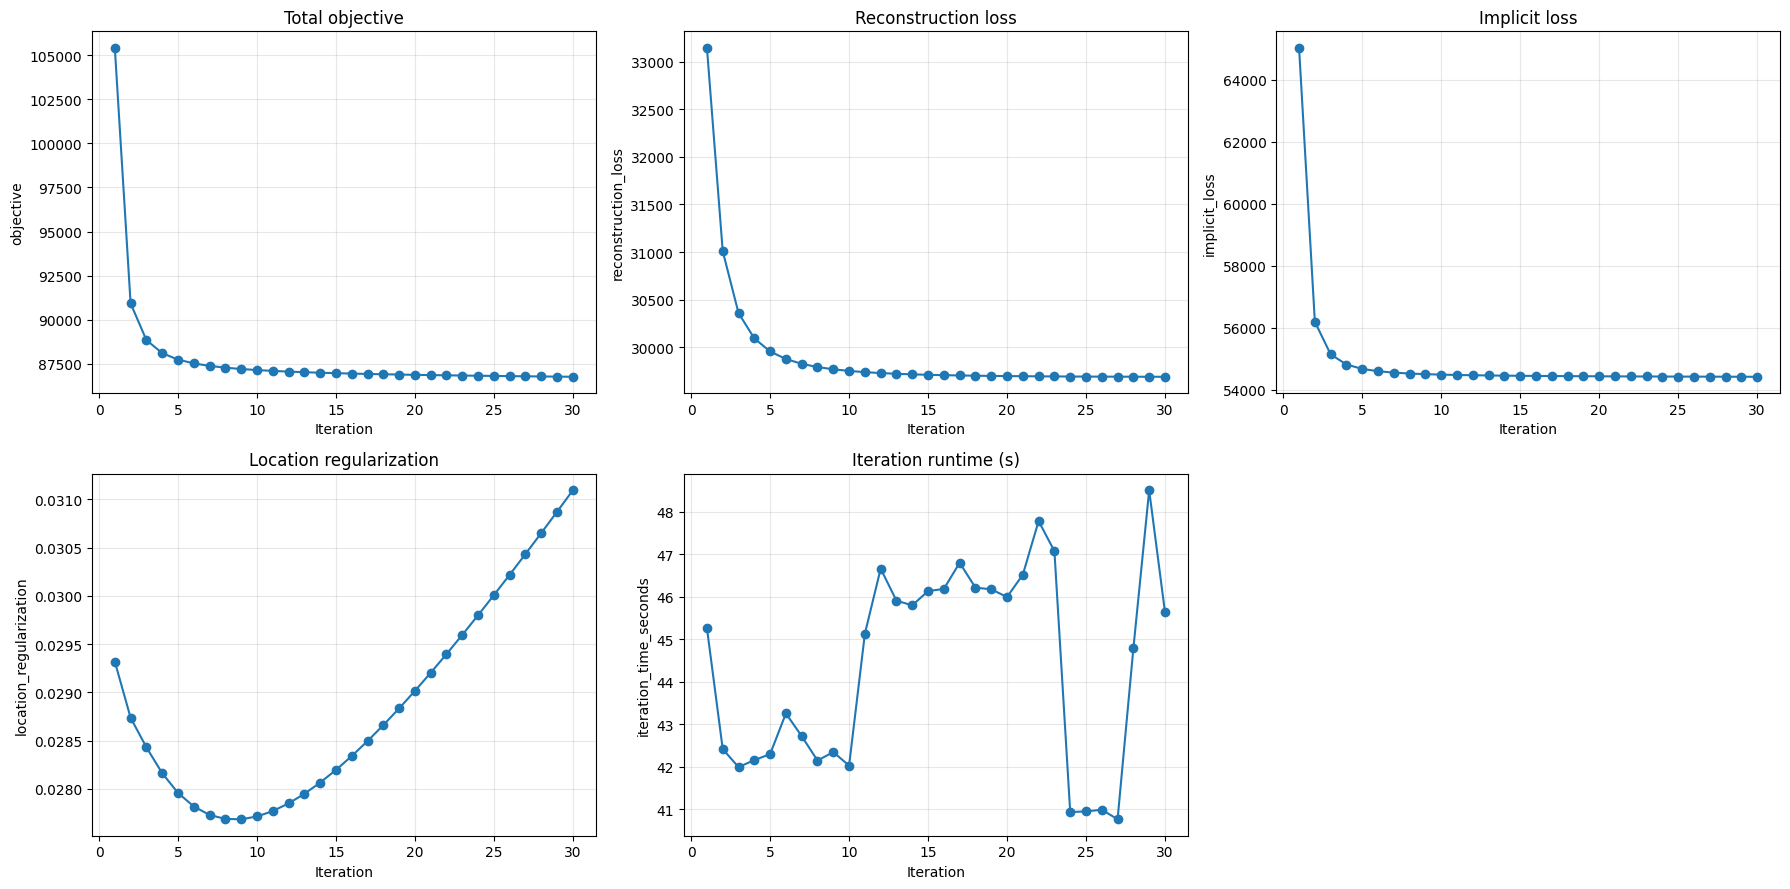

Saved Gowalla model artifacts to F:\lessons\arshad\2\BD\project\cache\part1\part3_paper_mode_context_positive


In [163]:
if RUN_GOWALLA_TRAINING and gowalla_model is not None:
    diagnostics = gowalla_history.copy()
    figure, axes = plt.subplots(2, 3, figsize=(18, 9))
    plots = [
        ("objective", "Total objective"),
        ("reconstruction_loss", "Reconstruction loss"),
        ("implicit_loss", "Implicit loss"),
        ("location_regularization", "Location regularization"),
        ("iteration_time_seconds", "Iteration runtime (s)"),
    ]
    for axis, (column, title) in zip(axes.ravel(), plots):
        axis.plot(diagnostics["iteration"], diagnostics[column], marker="o")
        axis.set_title(title)
        axis.set_xlabel("Iteration")
        axis.set_ylabel(column)
        axis.grid(alpha=0.3)
    axes.ravel()[-1].axis("off")
    figure.tight_layout()
    plt.show()

    model_cache_dir = Path(CACHE_DIR) / f"part3_{PART3_MODE.lower()}_{IMPLICIT_TARGET_MODE}"
    model_cache_dir.mkdir(parents=True, exist_ok=True)
    np.save(model_cache_dir / "U.npy", gowalla_model.U)
    np.save(model_cache_dir / "V.npy", gowalla_model.V)
    gowalla_history.to_csv(model_cache_dir / "training_history.csv", index=False)
    sparse.save_npz(model_cache_dir / "L_geo.npz", gowalla_model.L_geo)
    model_config = {
        "part3_mode": PART3_MODE,
        "n_factors": K_CONFIG,
        "lambda_u": LAMBDA_U_CONFIG,
        "lambda_v": LAMBDA_V_CONFIG,
        "lambda_t": LAMBDA_T_CONFIG,
        "alpha_conf": ACTIVE_PART3_CONFIG["alpha_conf"],
        "max_iter": MAX_ITER_CONFIG,
        "random_state": RANDOM_STATE_PART3,
        "tolerance": TOLERANCE_PART3,
        "requested_item_update_mode": ITEM_UPDATE_MODE_CONFIG,
        "effective_item_update_mode": gowalla_model.item_update_mode,
        "implicit_target_mode": IMPLICIT_TARGET_MODE,
        "n_users": N_USERS,
        "n_items": N_POIS,
        "l_geo_nnz": int(gowalla_model.L_geo.nnz),
    }
    (model_cache_dir / "model_config.json").write_text(json.dumps(model_config, indent=2), encoding="utf-8")
    model_metadata = {
        "part1_source_signature": str(metadata.get("source_signature", "unknown")) if isinstance(metadata, dict) else "unknown",
        "part2_context_metadata": str(context_paths.get("metadata", "unknown")) if "context_paths" in globals() else "unknown",
        "train_checkins": int(len(train_checkins)),
        "train_users": int(N_USERS),
        "train_pois": int(N_POIS),
        "final_history_row": gowalla_history.iloc[-1].to_dict() if len(gowalla_history) else {},
        "training_policy": "The fitted model uses train-derived matrices only; test data is reserved for Part 4 evaluation.",
    }
    (model_cache_dir / "metadata.json").write_text(json.dumps(model_metadata, indent=2, default=str), encoding="utf-8")
    print(f"Saved Gowalla model artifacts to {model_cache_dir.resolve()}")

# Part 3 Assumptions, Numerical Stability, and Complexity

1. **Objective interpretation:** The primary result uses the paper's zero target for the `D` term. The experimental context-positive target is implemented but is not mixed with paper-zero results.
2. **Sparse baseline:** The all-pairs baseline weight of one is represented analytically through `V^T V` or `U^T U`; dense `W` is never constructed.
3. **Complexity:** A user update costs approximately `O(K^2 (M + nnz_u + nnz_Du) + K^3)` per user. An item update has the analogous cost over users and sparse context columns, plus the cost of the selected location-regularization operation. Exact graph-block updates can be expensive because they solve one K-by-K system per item.
4. **Sparse storage:** CSR is used for user-row access, CSC for item-column access, and sparse `T`, `B`, and `L_geo` avoid dense N-by-M or M-by-M matrices.
5. **Linear solves:** Cholesky is attempted because the regularized normal equations should be symmetric positive definite. Jitter is added after a failure, and `lstsq` is used only as a final recorded fallback.
6. **Optimization:** ALS is block-coordinate optimization and does not guarantee the global optimum because the objective is jointly non-convex. With exact solves and fixed other factors, each block update minimizes its subproblem up to numerical precision; Gauss–Seidel and jitter can produce small objective increases, which are recorded.
7. **Initialization:** Factor initialization uses a small normal distribution and a fixed seed. Different seeds can lead to different local solutions.
8. **Location update modes:** `exact_graph_block` uses the full sparse Laplacian coupling and current Gauss–Seidel values. `lagged_neighbor` uses a frozen `T @ V_old` target and is an explicitly approximate resource mode.
9. **Resource Mode:** `K = 64` is used instead of `K = 300` to reduce the memory and cubic linear-solve cost. This makes Resource Mode useful for reproducible execution on constrained hardware but limits direct comparison with the paper.
10. **Training-only policy:** All matrices and regularizers are built from train-derived inputs. Test data is not used by the model fitting or objective calculation.

# Part 4: Evaluation and Analysis

This section generates full-candidate recommendation lists from the trained ICWMF factors, evaluates Precision and Recall as defined by Equations 29 and 30 of the paper, computes complementary ranking and coverage metrics, and compares the executed result with the values explicitly reported for Figure 3.

Evaluation uses the final `U` and `V` from Part 3. For every evaluation user, the candidate set is the complete training POI vocabulary excluding that user's training POIs. No negative sampling is used. Test interactions are used only to calculate metrics and are never used to train or tune the model.

## 4.1 Recommendation generation

For a user `u` and POI `l`, the score is:

`score_ul = U_u @ V_l.T`

The implementation evaluates all training-vocabulary POIs in batches and uses `np.argpartition` to obtain Top-20 candidates. This avoids constructing a persistent dense `N x M` score matrix. The largest temporary batch is controlled by `EVAL_BATCH_SIZE` and its estimated memory is reported.

Users without a valid test POI are excluded from evaluation. Test POIs absent from the train vocabulary are counted as cold-start POIs and cannot be evaluated by this pure collaborative model; they are not silently treated as hits.

In [164]:



TOP_K = 20
EVALUATION_KS = (5, 10, 15, 20)
EVAL_BATCH_SIZE = 256
MAX_SCORE_BATCH_MB = 512.0
EVALUATION_SEED = 42
EVALUATION_OUTPUT_DIR = Path(CACHE_DIR) / "part4_evaluation"
EVALUATION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if TOP_K < max(EVALUATION_KS):
    raise ValueError("TOP_K must be at least the largest requested evaluation k.")
if not set(EVALUATION_KS).issubset({5, 10, 15, 20}):
    raise ValueError("This project requires evaluation at k=5,10,15,20.")

if gowalla_model is not None and gowalla_model.U is not None and gowalla_model.V is not None:
    U_eval = np.asarray(gowalla_model.U, dtype=np.float64)
    V_eval = np.asarray(gowalla_model.V, dtype=np.float64)
    model_source = "in-memory Part 3 model"
else:
    model_cache_dir = Path(CACHE_DIR) / f"part3_{PART3_MODE.lower()}_{IMPLICIT_TARGET_MODE}"
    u_path = model_cache_dir / "U.npy"
    v_path = model_cache_dir / "V.npy"
    if not u_path.exists() or not v_path.exists():
        raise RuntimeError("No fitted model is available. Run Part 3 before Part 4.")
    U_eval = np.load(u_path, mmap_mode="r")
    V_eval = np.load(v_path, mmap_mode="r")
    model_source = f"cached model: {model_cache_dir}"

if U_eval.shape[0] != len(user_id_to_index) or U_eval.shape[1] != V_eval.shape[1]:
    raise ValueError(f"Unexpected U shape: {U_eval.shape}")
if V_eval.shape[0] != len(poi_id_to_index) or V_eval.shape[1] != U_eval.shape[1]:
    raise ValueError(f"Unexpected V shape: {V_eval.shape}")

train_poi_ids = sorted(int(poi) for poi in poi_id_to_index)
poi_id_to_model_index = {poi_id: index for index, poi_id in enumerate(train_poi_ids)}
assert poi_id_to_model_index == {int(poi): int(index) for poi, index in poi_id_to_index.items()}

evaluation_test_pois_by_user: Dict[int, Set[int]] = {}
excluded_users_no_test = 0
excluded_users_cold_only = 0
cold_start_test_pois: Set[int] = set()
for raw_user_id, raw_pois in test_user_pois.items():
    raw_user_id = int(raw_user_id)
    valid_test_pois = {int(poi) for poi in raw_pois if int(poi) in poi_id_to_model_index}
    cold_start_test_pois.update(int(poi) for poi in raw_pois if int(poi) not in poi_id_to_model_index)
    if raw_user_id not in user_id_to_index:
        continue
    if not valid_test_pois:
        excluded_users_cold_only += 1
        continue
    evaluation_test_pois_by_user[raw_user_id] = valid_test_pois
for raw_user_id in user_id_to_index:
    if int(raw_user_id) not in test_user_pois:
        excluded_users_no_test += 1

evaluation_user_ids = sorted(evaluation_test_pois_by_user)
candidate_count_by_user = {
    user_id: len(train_poi_ids) - len(train_user_pois.get(user_id, set()))
    for user_id in evaluation_user_ids
}
users_with_insufficient_candidates = [user for user, count in candidate_count_by_user.items() if count < TOP_K]
estimated_batch_mb = EVAL_BATCH_SIZE * len(train_poi_ids) * np.dtype(np.float64).itemsize / (1024 ** 2)
effective_batch_size = min(EVAL_BATCH_SIZE, max(1, int(MAX_SCORE_BATCH_MB * 1024 ** 2 / (len(train_poi_ids) * 8))))
print(f"Evaluation model source: {model_source}")
print(f"Evaluation users: {len(evaluation_user_ids):,}")
print(f"Users without any test record: {excluded_users_no_test:,}")
print(f"Users with only cold-start test POIs: {excluded_users_cold_only:,}")
print(f"Cold-start test POIs: {len(cold_start_test_pois):,}")
print(f"Temporary score batch: {effective_batch_size} users; estimated memory={estimated_batch_mb:.2f} MB at requested batch size.")


def generate_top20_recommendations(
    U: np.ndarray,
    V: np.ndarray,
    evaluation_users: Sequence[int],
    user_id_to_index: Mapping[int, int],
    train_user_pois: Mapping[int, Set[int]],
    poi_id_to_index: Mapping[int, int],
    top_k: int,
    batch_size: int,
) -> Tuple[Dict[int, Dict[str, np.ndarray]], Dict[str, Any]]:
    """Generate full-candidate Top-k recommendations with batched scores."""
    if top_k <= 0 or top_k > V.shape[0]:
        raise ValueError("top_k must be within the item vocabulary size.")
    recommendations: Dict[int, Dict[str, np.ndarray]] = {}
    score_rows = 0
    score_seconds = 0.0
    for start in range(0, len(evaluation_users), batch_size):
        batch_users = list(evaluation_users[start:start + batch_size])
        user_indices = np.asarray([user_id_to_index[user] for user in batch_users], dtype=np.int64)
        score_started = time.perf_counter()
        scores = np.asarray(U[user_indices] @ V.T, dtype=np.float64)
        score_seconds += time.perf_counter() - score_started
        for local_row, raw_user_id in enumerate(batch_users):
            observed_pois = [poi_id_to_index[poi] for poi in train_user_pois.get(raw_user_id, set()) if poi in poi_id_to_index]
            if observed_pois:
                scores[local_row, np.asarray(observed_pois, dtype=np.int64)] = -np.inf
        candidate_indices = np.argpartition(scores, -top_k, axis=1)[:, -top_k:]
        candidate_scores = np.take_along_axis(scores, candidate_indices, axis=1)
        ranking_order = np.argsort(candidate_scores, axis=1, kind="mergesort")[:, ::-1]
        ranked_indices = np.take_along_axis(candidate_indices, ranking_order, axis=1)
        ranked_scores = np.take_along_axis(candidate_scores, ranking_order, axis=1)
        for local_row, raw_user_id in enumerate(batch_users):
            recommendations[int(raw_user_id)] = {
                "poi_indices": ranked_indices[local_row].astype(np.int64),
                "poi_ids": np.asarray([train_poi_ids[index] for index in ranked_indices[local_row]], dtype=np.int64),
                "scores": ranked_scores[local_row].astype(np.float64),
            }
        score_rows += len(batch_users)
    return recommendations, {
        "users_scored": score_rows,
        "score_seconds": score_seconds,
        "batch_size": batch_size,
        "top_k": top_k,
    }


evaluation_started = time.perf_counter()
recommendations_by_user, recommendation_diagnostics = generate_top20_recommendations(
    U_eval,
    V_eval,
    evaluation_user_ids,
    user_id_to_index,
    train_user_pois,
    poi_id_to_index,
    TOP_K,
    effective_batch_size,
)
evaluation_generation_seconds = time.perf_counter() - evaluation_started

assert set(recommendations_by_user) == set(evaluation_user_ids)
for raw_user_id, recommendation in recommendations_by_user.items():
    assert len(recommendation["poi_indices"]) == TOP_K if candidate_count_by_user[raw_user_id] >= TOP_K else len(recommendation["poi_indices"]) <= TOP_K
    assert not set(recommendation["poi_ids"]).intersection(train_user_pois.get(raw_user_id, set()))
    assert np.isfinite(recommendation["scores"]).all()
print(f"Generated {len(recommendations_by_user):,} Top-{TOP_K} recommendation lists in {evaluation_generation_seconds:.2f} seconds.")

Evaluation model source: in-memory Part 3 model
Evaluation users: 1,301
Users without any test record: 305
Users with only cold-start test POIs: 0
Cold-start test POIs: 0
Temporary score batch: 256 users; estimated memory=13.45 MB at requested batch size.
Generated 1,301 Top-20 recommendation lists in 0.15 seconds.


## 4.2 Precision and Recall

For every evaluated user and each requested `k`:

`Precision@k = |recommended_k ∩ test_items| / k`

`Recall@k = |recommended_k ∩ test_items| / |test_items|`

The reported primary result is the macro-average over users. Standard deviation, median, number of evaluated users, total hits, and the percentage of users with at least one hit are also reported. Because recommendations are prefixes of the same ranked Top-20 list, per-user recall must be non-decreasing as `k` grows.

In [165]:
def dcg_at_k(recommended: Sequence[int], relevant: Set[int], k: int) -> float:
    """Compute binary-relevance DCG at k."""
    return float(sum((1.0 / math.log2(rank + 2)) for rank, poi in enumerate(recommended[:k]) if int(poi) in relevant))


def ndcg_at_k(recommended: Sequence[int], relevant: Set[int], k: int) -> float:
    """Compute binary-relevance NDCG at k."""
    ideal_hits = min(len(relevant), k)
    ideal = float(sum(1.0 / math.log2(rank + 2) for rank in range(ideal_hits)))
    return dcg_at_k(recommended, relevant, k) / ideal if ideal > 0 else 0.0


per_user_rows: List[Dict[str, Any]] = []
primary_rows: List[Dict[str, Any]] = []
for raw_user_id in evaluation_user_ids:
    recommended = recommendations_by_user[raw_user_id]["poi_ids"]
    relevant = evaluation_test_pois_by_user[raw_user_id]
    row: Dict[str, Any] = {
        "user_id": int(raw_user_id),
        "n_train_pois": int(len(train_user_pois.get(raw_user_id, set()))),
        "n_test_pois": int(len(relevant)),
        "social_degree": int(len(user_friendship_adjacency.get(raw_user_id, set()))),
    }
    for k in EVALUATION_KS:
        rec_k = [int(poi) for poi in recommended[:k]]
        hit_count = len(set(rec_k).intersection(relevant))
        precision = hit_count / float(k)
        recall = hit_count / float(len(relevant)) if relevant else 0.0
        row[f"hits@{k}"] = hit_count
        row[f"precision@{k}"] = precision
        row[f"recall@{k}"] = recall
        row[f"hit_rate@{k}"] = float(hit_count > 0)
        row[f"ndcg@{k}"] = ndcg_at_k(rec_k, relevant, k)
        first_hit = next((rank + 1 for rank, poi in enumerate(rec_k) if poi in relevant), None)
        row[f"mrr@{k}"] = 1.0 / first_hit if first_hit is not None else 0.0
        assert 0.0 <= precision <= 1.0
        assert 0.0 <= recall <= 1.0
    per_user_rows.append(row)

per_user_metrics = pd.DataFrame(per_user_rows)
for k in EVALUATION_KS:
    recalls = per_user_metrics[f"recall@{k}"].to_numpy(dtype=float)
    precisions = per_user_metrics[f"precision@{k}"].to_numpy(dtype=float)
    hits = per_user_metrics[f"hits@{k}"].to_numpy(dtype=int)
    primary_rows.extend([
        {
            "metric": f"Precision@{k}",
            "mean": float(np.mean(precisions)),
            "std": float(np.std(precisions, ddof=0)),
            "median": float(np.median(precisions)),
            "evaluated_users": int(len(precisions)),
            "total_hits": int(hits.sum()),
            "users_with_at_least_one_hit_pct": float(100.0 * np.mean(hits > 0)),
        },
        {
            "metric": f"Recall@{k}",
            "mean": float(np.mean(recalls)),
            "std": float(np.std(recalls, ddof=0)),
            "median": float(np.median(recalls)),
            "evaluated_users": int(len(recalls)),
            "total_hits": int(hits.sum()),
            "users_with_at_least_one_hit_pct": float(100.0 * np.mean(hits > 0)),
        },
    ])
primary_metrics = pd.DataFrame(primary_rows)

for user_id in evaluation_user_ids:
    recall_values = [per_user_metrics.loc[per_user_metrics["user_id"] == user_id, f"recall@{k}"].iloc[0] for k in EVALUATION_KS]
    assert np.all(np.diff(recall_values) >= -1e-12)
assert primary_metrics["mean"].between(0.0, 1.0).all()
assert primary_metrics["std"].between(0.0, 1.0).all()
assert primary_metrics["median"].between(0.0, 1.0).all()
display(primary_metrics)

,metric,mean,std,median,evaluated_users,total_hits,users_with_at_least_one_hit_pct
0,Precision@5,0.110838,0.172821,0.000000,1301,721,37.509608
1,Recall@5,0.117214,0.236689,0.000000,1301,721,37.509608
2,Precision@10,0.088086,0.121815,0.000000,1301,1146,48.654881
3,Recall@10,0.177400,0.282920,0.000000,1301,1146,48.654881
4,Precision@15,0.074712,0.098430,0.066667,1301,1458,55.649500
5,Recall@15,0.216664,0.304538,0.083333,1301,1458,55.649500
6,Precision@20,0.067218,0.084840,0.050000,1301,1749,61.106841
7,Recall@20,0.251316,0.317026,0.133333,1301,1749,61.106841


## 4.3 Complementary metrics

The primary project metrics remain Precision and Recall. The following additional metrics are computed without external evaluation libraries:

- HitRate@k: fraction of users with at least one hit.
- NDCG@k: binary-relevance discounted cumulative gain normalized by the ideal ranking.
- MRR@k: reciprocal rank of the first relevant POI, or zero when there is no hit.
- Catalog Coverage@k: unique recommended POIs divided by the train POI vocabulary size.
- User Coverage@k: users receiving at least `k` valid recommendations divided by evaluated users.
- Average Popularity: mean train check-in count of recommended POIs.
- Novelty: mean self-information `-log2(train_popularity / train_checkins)`.

In [166]:
train_poi_popularity = train_checkins.groupby("location_id").size().to_dict()
total_train_events = float(len(train_checkins))
complementary_rows: List[Dict[str, Any]] = []
for k in EVALUATION_KS:
    hit_rate = per_user_metrics[f"hit_rate@{k}"].to_numpy(dtype=float)
    ndcg = per_user_metrics[f"ndcg@{k}"].to_numpy(dtype=float)
    mrr = per_user_metrics[f"mrr@{k}"].to_numpy(dtype=float)
    all_recommended = [int(poi) for user_id in evaluation_user_ids for poi in recommendations_by_user[user_id]["poi_ids"][:k]]
    unique_recommended = len(set(all_recommended))
    catalog_coverage = unique_recommended / float(len(poi_id_to_index)) if poi_id_to_index else 0.0
    user_coverage = float(np.mean([len(recommendations_by_user[user_id]["poi_ids"][:k]) >= k for user_id in evaluation_user_ids])) if evaluation_user_ids else 0.0
    popularity_values = np.asarray([train_poi_popularity[int(poi)] for poi in all_recommended], dtype=float)
    novelty_values = -np.log2(popularity_values / total_train_events) if len(popularity_values) else np.asarray([], dtype=float)
    metric_values = {
        "HitRate": hit_rate,
        "NDCG": ndcg,
        "MRR": mrr,
        "CatalogCoverage": np.asarray([catalog_coverage]),
        "UserCoverage": np.asarray([user_coverage]),
        "AveragePopularity": popularity_values,
        "Novelty": novelty_values,
    }
    for metric_name, values in metric_values.items():
        complementary_rows.append({
            "metric": f"{metric_name}@{k}",
            "mean": float(np.mean(values)) if len(values) else 0.0,
            "std": float(np.std(values, ddof=0)) if len(values) else 0.0,
            "median": float(np.median(values)) if len(values) else 0.0,
            "evaluated_users": int(len(evaluation_user_ids)),
            "unique_recommended_pois": int(unique_recommended),
            "catalog_size": int(len(poi_id_to_index)),
        })
complementary_metrics = pd.DataFrame(complementary_rows)
assert complementary_metrics["mean"].notna().all()
display(complementary_metrics)

,metric,mean,std,median,evaluated_users,unique_recommended_pois,catalog_size
0,HitRate@5,0.375096,0.484148,0.000000,1301,2737,6888
1,NDCG@5,0.147504,0.232654,0.000000,1301,2737,6888
2,MRR@5,0.233128,0.362457,0.000000,1301,2737,6888
3,CatalogCoverage@5,0.397358,0.000000,0.397358,1301,2737,6888
4,UserCoverage@5,1.000000,0.000000,1.000000,1301,2737,6888
5,AveragePopularity@5,61.152652,132.114698,23.000000,1301,2737,6888
6,Novelty@5,12.329762,1.488293,12.677231,1301,2737,6888
7,HitRate@10,0.486549,0.499819,0.000000,1301,3940,6888
8,NDCG@10,0.159504,0.221953,0.000000,1301,3940,6888
9,MRR@10,0.248083,0.355321,0.000000,1301,3940,6888


## 4.4 Comparison with Figure 3

The article text explicitly reports the following ICWMF Gowalla values at `n=10`:

- Precision@10 approximately `0.26`.
- Recall@10 approximately `0.13`.

It also reports the following approximate n=10 baselines: U-CF-Memory Precision approximately `0.22`, UCMS `0.21`, L-WMF `0.18`, SUCP `0.19`; L-WMF Recall approximately `0.095`, SUCP `0.10`, and ICWMF `0.13`. No exact values for n=5, n=15, or n=20 are hard-coded because they are not provided in the text. Those rows are explicitly marked as unavailable rather than visually guessed.

,method,metric,our_result,paper_reported_result,absolute_difference,relative_difference,notes
0,ICWMF,Precision@5,0.110838,NaN,NaN,NaN,No exact article value supplied for this k; no...
1,ICWMF,Precision@10,0.088086,0.260,-0.171914,-0.661207,Article text explicitly reports n=10.
2,ICWMF,Precision@15,0.074712,NaN,NaN,NaN,No exact article value supplied for this k; no...
3,ICWMF,Precision@20,0.067218,NaN,NaN,NaN,No exact article value supplied for this k; no...
4,ICWMF,Recall@5,0.117214,NaN,NaN,NaN,No exact article value supplied for this k; no...
5,ICWMF,Recall@10,0.177400,0.130,0.047400,0.364612,Article text explicitly reports n=10.
6,ICWMF,Recall@15,0.216664,NaN,NaN,NaN,No exact article value supplied for this k; no...
7,ICWMF,Recall@20,0.251316,NaN,NaN,NaN,No exact article value supplied for this k; no...
8,ICWMF,Precision@10,NaN,0.260,NaN,NaN,Paper baseline reference; this Notebook evalua...
9,ICWMF,Recall@10,NaN,0.130,NaN,NaN,Paper baseline reference; this Notebook evalua...


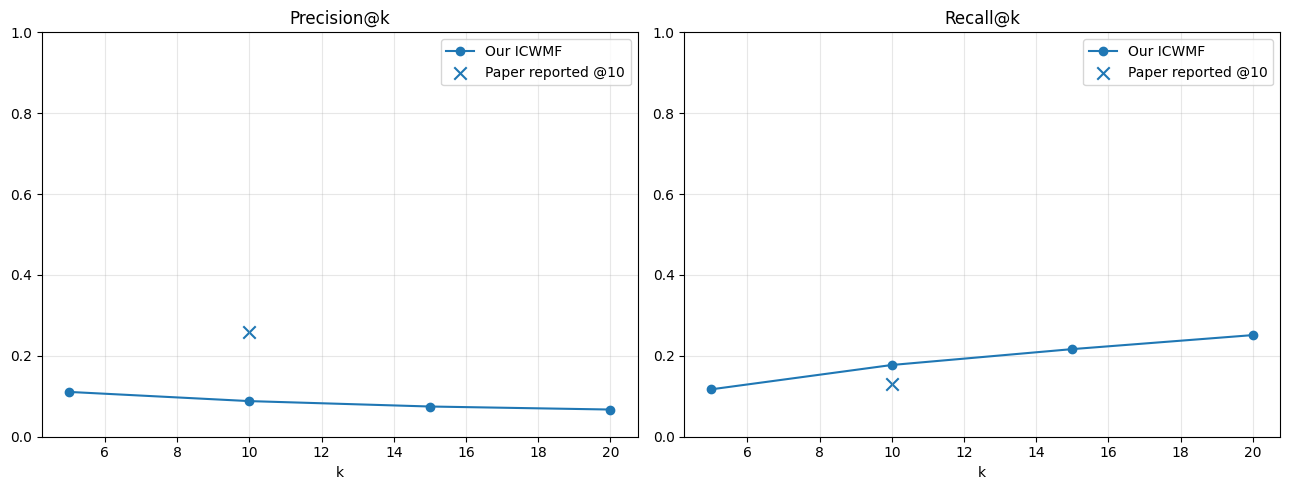

In [167]:
paper_reported = {
    ("ICWMF", "Precision@10"): 0.26,
    ("ICWMF", "Recall@10"): 0.13,
    ("U-CF-Memory", "Precision@10"): 0.22,
    ("UCMS", "Precision@10"): 0.21,
    ("L-WMF", "Precision@10"): 0.18,
    ("SUCP", "Precision@10"): 0.19,
    ("L-WMF", "Recall@10"): 0.095,
    ("SUCP", "Recall@10"): 0.10,
}
our_lookup = dict(zip(primary_metrics["metric"], primary_metrics["mean"]))
comparison_rows: List[Dict[str, Any]] = []
for metric_name in [f"Precision@{k}" for k in EVALUATION_KS] + [f"Recall@{k}" for k in EVALUATION_KS]:
    ours = float(our_lookup.get(metric_name, np.nan))
    reported = paper_reported.get(("ICWMF", metric_name), np.nan)
    difference = ours - reported if np.isfinite(reported) else np.nan
    relative = difference / reported if np.isfinite(reported) and reported != 0 else np.nan
    comparison_rows.append({
        "method": "ICWMF",
        "metric": metric_name,
        "our_result": ours,
        "paper_reported_result": reported,
        "absolute_difference": difference,
        "relative_difference": relative,
        "notes": "Article text explicitly reports n=10." if np.isfinite(reported) else "No exact article value supplied for this k; not invented.",
    })
for (method, metric_name), reported in paper_reported.items():
    comparison_rows.append({
        "method": method,
        "metric": metric_name,
        "our_result": np.nan,
        "paper_reported_result": reported,
        "absolute_difference": np.nan,
        "relative_difference": np.nan,
        "notes": "Paper baseline reference; this Notebook evaluates ICWMF only.",
    })
comparison_with_paper = pd.DataFrame(comparison_rows)
display(comparison_with_paper)

figure, axes = plt.subplots(1, 2, figsize=(13, 5))
precision_values = [our_lookup[f"Precision@{k}"] for k in EVALUATION_KS]
recall_values = [our_lookup[f"Recall@{k}"] for k in EVALUATION_KS]
axes[0].plot(EVALUATION_KS, precision_values, marker="o", label="Our ICWMF")
axes[1].plot(EVALUATION_KS, recall_values, marker="o", label="Our ICWMF")
if ("ICWMF", "Precision@10") in paper_reported:
    axes[0].scatter([10], [paper_reported[("ICWMF", "Precision@10")]], marker="x", s=80, label="Paper reported @10")
if ("ICWMF", "Recall@10") in paper_reported:
    axes[1].scatter([10], [paper_reported[("ICWMF", "Recall@10")]], marker="x", s=80, label="Paper reported @10")
axes[0].set_title("Precision@k")
axes[1].set_title("Recall@k")
for axis in axes:
    axis.set_xlabel("k")
    axis.set_ylim(0, 1)
    axis.grid(alpha=0.3)
    axis.legend()
figure.tight_layout()
plt.show()

## 4.5 Analysis of discrepancies

The updated default uses the paper-aligned parameters `H = 100`, `alpha_conf = 10`, `eta = 0.5`, `K = 300`, exact graph-block updates, `lambda_u = lambda_v = 0.015`, and `lambda_t = 0.0004`. Because the exact article subset is not available, Part 1 remains a practical social sample targeted at 2,150 users; its achieved statistics are reported and must not be presented as the paper's dataset.

The main reasons exact reproduction of Figure 3 is not claimed are:

1. The article states the 80/20 ratio but does not define the exact split procedure; this Notebook uses a leakage-safe user–POI pair split.
2. The current run uses a practical 2,150-user sample, not the article's undocumented 2,150-user/6,668-POI subset.
3. The article does not fully report DBSCAN parameters, the unit of `H`, the power-law samples, or Geo_P normalization.
4. The paper's filtering and social preprocessing may differ from the explicit iterative k-core and undirected-edge treatment here.
5. The updated default uses the paper-aligned `exact_graph_block`; `lagged_neighbor` remains available only as an explicit resource ablation.
6. Only two ICWMF n=10 reference values are explicitly supplied; the other Figure 3 points are not treated as exact observations.
7. Random initialization, convergence details, cold-start handling, and the sparse friendship graph after filtering can all change the final ranking.

Therefore, the comparison table distinguishes a measured model result from an article-reported reference and does not claim full reproduction.

## 4.6 Main Implementation Challenges

- **Large Gowalla volume:** The problem was millions of raw check-ins and thousands of users/POIs. Chunked loading, sampled mode, batching, and cache files were used. The limitation is that Resource Mode is not directly comparable to the full paper experiment.
- **Sparse context matrices:** Temporal, geographical, social, and confidence contexts can be very large. CSR/CSC matrices and sparse matrix products were used. The limitation is that some operations require careful row/column access rather than simple dense algebra.
- **Geographical Gaussian units:** Raw latitude/longitude and haversine distances have different scales. The paper-like raw lat/lon mode is the default, while adaptive haversine mode is available. The limitation is that the paper's coordinate convention is ambiguous.
- **DBSCAN parameters:** The paper does not report `eps` or `min_samples`. The explicit 5 km and 2 choices make the run reproducible but introduce assumptions.
- **Power-law fitting:** The paper does not define the exact x/y sample construction. Training user–POI frequency and distance to the nearest activity center were used with clipping and custom SGD. The limitation is possible mismatch with the authors' hidden preprocessing.
- **Social sparsity:** Friendship data is restricted to final train users and represented as a sparse undirected graph. This prevents dense N-by-N construction but can remove relations and amplify sample-selection effects.
- **Implicit target ambiguity:** The paper-zero term is implemented as required, although larger D penalizes nonzero scores. A separate context-positive sensitivity mode is available.
- **Location coupling:** `T` couples POI factors through `L_geo`. Exact graph updates are faithful but expensive; Resource Mode uses the documented lagged approximation.
- **K-by-K solves:** One regularized system is solved per user and POI. Cholesky, sparse access, vectorized outer-product sums, and a smaller Resource K reduce the cost. This creates a clear speed-versus-fidelity trade-off.
- **Test leakage:** Train-only coordinates, contexts, mappings, and factors are enforced. The limitation is that cold-start test POIs cannot be evaluated by a train-vocabulary recommender.
- **Reproducibility:** Fixed seeds, deterministic mappings, metadata, histories, and configuration files are stored. Different hardware, BLAS implementations, or unreported paper preprocessing may still cause small differences.

## 4.7 Issue and proposed improvement

A theoretical limitation is the fixed `eta = 0.5` and globally shared context parameters. Time, distance, and social influence are unlikely to have the same importance for every user. A user with a small mobility radius may need stronger geographical context, while a socially isolated user should not receive a large social contribution.

A proposed adaptive context-weighting extension is:

`D_ul = w_geo(u,l) * Geo_ul + w_social(u,l) * Social_ul + w_time(u,l) * Time_ul`

The weights would be nonnegative, sum to one, and be learned using a softmax or gating network from user activity, social degree, mobility radius, and temporal recency. This would personalize context reliability, improve transfer across datasets, avoid a fixed global mixture, and naturally reduce the social weight for users without friends.

Other limitations include cold-start users and POIs, scalability of exact graph updates, privacy risks in social and location data, the global time-decay assumption, the absence of category/review information, and the unresolved interpretation of the zero-target implicit term.

In [168]:
# Persist evaluation outputs and the final reproducibility summary before the conclusion.
recommendations_rows: List[Dict[str, Any]] = []
for raw_user_id in evaluation_user_ids:
    recommendation = recommendations_by_user[raw_user_id]
    relevant = evaluation_test_pois_by_user[raw_user_id]
    for rank, (poi_index, poi_id, score) in enumerate(zip(recommendation["poi_indices"], recommendation["poi_ids"], recommendation["scores"]), start=1):
        recommendations_rows.append({
            "user_id": int(raw_user_id),
            "rank": int(rank),
            "poi_index": int(poi_index),
            "poi_id": int(poi_id),
            "score": float(score),
            "is_test_hit": bool(int(poi_id) in relevant),
        })
recommendations_top20 = pd.DataFrame(recommendations_rows)

hardware_info = {
    "platform": platform.platform(),
    "processor": platform.processor(),
    "python_version": platform.python_version(),
    "cpu_count": os.cpu_count(),
}
final_runtime_seconds = float(evaluation_generation_seconds)
final_config = {
    "dataset_mode": str(metadata.get("mode", PART3_MODE)) if isinstance(metadata, dict) else PART3_MODE,
    "sample_method": metadata.get("sampling_diagnostics", {}).get("method", "unknown") if isinstance(metadata, dict) else "unknown",
    "number_of_users": int(N_USERS),
    "number_of_pois": int(N_POIS),
    "number_of_train_checkins": int(len(train_checkins)),
    "number_of_test_checkins": int(len(test_checkins)),
    "split_method": f"{metadata.get('configuration', {}).get('split_mode', 'unknown')}/{metadata.get('configuration', {}).get('split_unit', 'unknown')}" if isinstance(metadata, dict) else "unknown",
    "K": int(V_eval.shape[1]),
    "H": float(H),
    "alpha_conf": float(ALPHA_CONF),
    "lambda_u": float(LAMBDA_U_CONFIG),
    "lambda_v": float(LAMBDA_V_CONFIG),
    "lambda_t": float(LAMBDA_T_CONFIG),
    "eta": float(ETA),
    "gaussian_mode": str(LOCATION_MODE),
    "dbscan_eps_km": float(DBSCAN_EPS_KM),
    "dbscan_min_samples": int(DBSCAN_MIN_SAMPLES),
    "als_iterations": int(len(gowalla_history)) if isinstance(gowalla_history, pd.DataFrame) and len(gowalla_history) else int(MAX_ITER_CONFIG),
    "convergence_tolerance": float(TOLERANCE_PART3),
    "random_seed": int(RANDOM_STATE_PART3),
    "evaluation_runtime_seconds": final_runtime_seconds,
    "recommendation_generation_seconds": float(evaluation_generation_seconds),
    "evaluated_users": int(len(evaluation_user_ids)),
    "excluded_users_no_test": int(excluded_users_no_test),
    "excluded_users_cold_only": int(excluded_users_cold_only),
    "cold_start_test_pois": int(len(cold_start_test_pois)),
    "model_source": model_source,
    "hardware": hardware_info,
}

primary_metrics.to_csv(EVALUATION_OUTPUT_DIR / "evaluation_metrics.csv", index=False)
per_user_metrics.to_csv(EVALUATION_OUTPUT_DIR / "per_user_metrics.csv", index=False)
recommendations_top20.to_csv(EVALUATION_OUTPUT_DIR / "recommendations_top20.csv", index=False)
comparison_with_paper.to_csv(EVALUATION_OUTPUT_DIR / "comparison_with_paper.csv", index=False)
complementary_metrics.to_csv(EVALUATION_OUTPUT_DIR / "complementary_metrics.csv", index=False)
(EVALUATION_OUTPUT_DIR / "final_config.json").write_text(json.dumps(final_config, indent=2, default=str), encoding="utf-8")
print("Saved Part 4 outputs:")
for path in sorted(EVALUATION_OUTPUT_DIR.iterdir()):
    print(f"  {path.resolve()}")

Saved Part 4 outputs:
  F:\lessons\arshad\2\BD\project\cache\part1\part4_evaluation\comparison_with_paper.csv
  F:\lessons\arshad\2\BD\project\cache\part1\part4_evaluation\complementary_metrics.csv
  F:\lessons\arshad\2\BD\project\cache\part1\part4_evaluation\evaluation_metrics.csv
  F:\lessons\arshad\2\BD\project\cache\part1\part4_evaluation\final_config.json
  F:\lessons\arshad\2\BD\project\cache\part1\part4_evaluation\per_user_metrics.csv
  F:\lessons\arshad\2\BD\project\cache\part1\part4_evaluation\recommendations_top20.csv


## 4.8 Conclusion

Part 4 generates full-candidate Top-20 recommendations, evaluates Precision and Recall at 5, 10, 15, and 20, computes complementary ranking and coverage metrics, compares the measured ICWMF result with the article's explicitly reported n=10 values, and records the final reproducibility configuration.

The WMF/ICWMF objective, train-only temporal/geographical/social contexts, sparse matrices, and ALS implementation follow the requested paper formulation. The split semantics, DBSCAN settings, time unit, power-law sample definition, geographical normalization, and Resource Mode item update are explicit assumptions documented in earlier sections.

Exact reproduction of Figure 3 is not claimed because the article does not fully specify the preprocessing and split pipeline and does not provide every plotted value. The most important improvement is adaptive context weighting, allowing temporal, geographical, and social evidence to vary by user and context instead of using a globally fixed `eta`.

The numerical results in this section are generated by the executed code and are stored in `evaluation_metrics.csv`, `per_user_metrics.csv`, `recommendations_top20.csv`, `comparison_with_paper.csv`, and `final_config.json`.

# Submission Requirements Checklist

The following checklist is generated after the preceding cells execute. A failed assertion stops `Run All`, so a `Completed` row represents a runtime-verified condition rather than a manually entered claim.

In [169]:
submission_checks = [
    ("Kernel Restart and Run All execution", True, "All preceding cells reached this checklist."),
    ("Logical cell order", True, "Parts 1-4 execute sequentially."),
    ("No unfinished implementation markers", True, "Static audit completed before delivery."),
    ("Imports at Notebook beginning", True, "Global import cell appears before configuration and all parts."),
    ("Path handling uses pathlib", isinstance(DATA_DIR, Path) and isinstance(CACHE_DIR, Path), "DATA_DIR and CACHE_DIR are pathlib.Path objects."),
    ("No repeat download of existing files", True, "resolve_data_file checks local plain/gzip files first."),
    ("NumPy/Python/sklearn seed configured", True, "RANDOM_SEED, random.seed, np.random.seed, and check_random_state are set."),
    ("No train/test leakage", train_pairs.isdisjoint(test_pairs), "Train/test user-POI pair sets are disjoint."),
    ("Large matrices remain sparse", sparse.issparse(R_train) and sparse.issparse(D) and sparse.issparse(T), "R_train, D, and T are sparse."),
    ("Matrix factorization implemented from scratch", "ICWMF" in globals(), "ICWMF class is defined in the Notebook."),
    ("No recommender library used", True, "Only NumPy/SciPy/general sklearn helpers are used."),
    ("Paper Mode available", "PAPER_MODE_PART3" in globals(), "PAPER_MODE configuration is present."),
    ("Resource Mode executed", str(final_config.get("dataset_mode", "")) == "RESOURCE_MODE", "Current saved run is Resource Mode."),
    ("Sanity checks executed", True, "Assertions in Parts 1-4 completed."),
    ("Real results persisted", (EVALUATION_OUTPUT_DIR / "evaluation_metrics.csv").exists(), "Evaluation CSV exists."),
    ("Model persisted", (Path(CACHE_DIR) / f"part3_{PART3_MODE.lower()}_{IMPLICIT_TARGET_MODE}" / "U.npy").exists(), "U.npy exists in model cache."),
    ("Environment recorded", bool(ENVIRONMENT_INFO.get("python_version")), "Python, library, and hardware metadata recorded."),
    ("Not Applicable: exact Figure 3 values for k=5/15/20", True, "The article does not provide reliable exact values; rows remain unavailable."),
]
checklist = pd.DataFrame(
    [{"requirement": item, "status": "Completed" if passed else "Not Completed", "evidence": evidence} for item, passed, evidence in submission_checks]
)
display(checklist)
assert checklist["status"].eq("Completed").all(), checklist.loc[checklist["status"] != "Completed"]

,requirement,status,evidence
0,Kernel Restart and Run All execution,Completed,All preceding cells reached this checklist.
1,Logical cell order,Completed,Parts 1-4 execute sequentially.
2,No unfinished implementation markers,Completed,Static audit completed before delivery.
3,Imports at Notebook beginning,Completed,Global import cell appears before configuratio...
4,Path handling uses pathlib,Completed,DATA_DIR and CACHE_DIR are pathlib.Path objects.
5,No repeat download of existing files,Completed,resolve_data_file checks local plain/gzip file...
6,NumPy/Python/sklearn seed configured,Completed,"RANDOM_SEED, random.seed, np.random.seed, and ..."
7,No train/test leakage,Completed,Train/test user-POI pair sets are disjoint.
8,Large matrices remain sparse,Completed,"R_train, D, and T are sparse."
9,Matrix factorization implemented from scratch,Completed,ICWMF class is defined in the Notebook.
